# 📘 Introduction — Leaching Optimiser (Shanta)

This notebook supports the development of a leaching optimisation framework using plant data from the Shanta gold operation. It is designed to help identify operational conditions that influence gold recovery, evaluate cyanide and oxygen use efficiency, and flag situations where reagent strategies may be mismatched with recovery outcomes.

## 🎯 Objectives

- Understand how key variables (e.g. feed grade, fines fraction, cyanide dosage, dissolved oxygen) relate to daily gold recovery.
- Build a lightweight predictive model of expected recovery under given conditions.
- Highlight instances where actual recovery underperforms predicted values.
- Flag possible inefficiencies or overuse of reagents, including cyanide overdose without benefit.
- Provide visual diagnostics and simple logic to support operator decision-making.

## Intended Use

This tool is intended as a **decision support aid**, not an automated control solution. It is best used to:
- Explore trends and diagnostics during performance reviews.
- Identify potential optimisation opportunities or suspect periods.
- Support a broader leaching strategy development effort.

The tool does not attempt to prescribe specific dosing targets, but can assist in identifying patterns that warrant investigation or adjustment.

## Streamline Input Features
Based on earlier findings, prioritise the following as core inputs to the model:
| Feature                                | Role                  | Notes                                            |
| -------------------------------------- | --------------------- | ------------------------------------------------ |
| `Feed Grade (g/t)`                     | High predictor value  | Strong positive correlation                      |
| `Fines Fraction (%)`                   | Modifiable input      | Moderate influence, operationally controllable   |
| `Cyanide Dosage (kg/d)`                | Primary reagent       | Weak negative correlation — needs diagnostics    |
| `DO (ppm)`                             | Influential in theory | Trend shows long-term decline                    |
| `Milled Tonnes`                        | Throughput context    | Include if recovery is calculated volumetrically |
| `Recovery (%)`                         | Target variable       | Use both actual and predicted                    |
| Optional: `Tailings Grade`, `% Solids` | Diagnostic only       | Helps explain anomalies                          |


## 📂 1: Load Data & Initial Setup

Loads the main dataset and configures the Python environment. Ensures consistent formatting and suppresses unnecessary warnings to streamline the workflow.

**Includes:**
- Library imports
- Display options and warning filters
- Dataset loading and renaming
- Initial checks on data structure and types

In [87]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor
import shap
import joblib
import seaborn as sns
from typing import Callable, List, Tuple
from scipy.optimize import brentq, minimize_scalar, minimize
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
import plotting_functions as pf
from itertools import product
from matplotlib import cm
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import plotly.express as px
import plotly.graph_objects as go
from itertools import product
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter

import sys
from pathlib import Path

# Assuming notebook is in src/test
sys.path.append(str(Path().resolve().parent))  # Adds src/

from utils.prescription_utils import prescribe_improvements, generate_prescriptive_grid


In [88]:
df = pd.read_csv('shanta_usage_data.csv')

# Convert 'date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

## 🔍 2: Data Diagnostics

Explore and profile the dataset to understand feature distributions, identify anomalies, and highlight any missing or inconsistent values that may impact downstream modelling.

**Includes:**
- Visualise cyanide and dissolved gold tank profiles
- Check null values and outlier behaviour
- Review correlations with recovery


### 📊 2.1: CN Tank Profiles

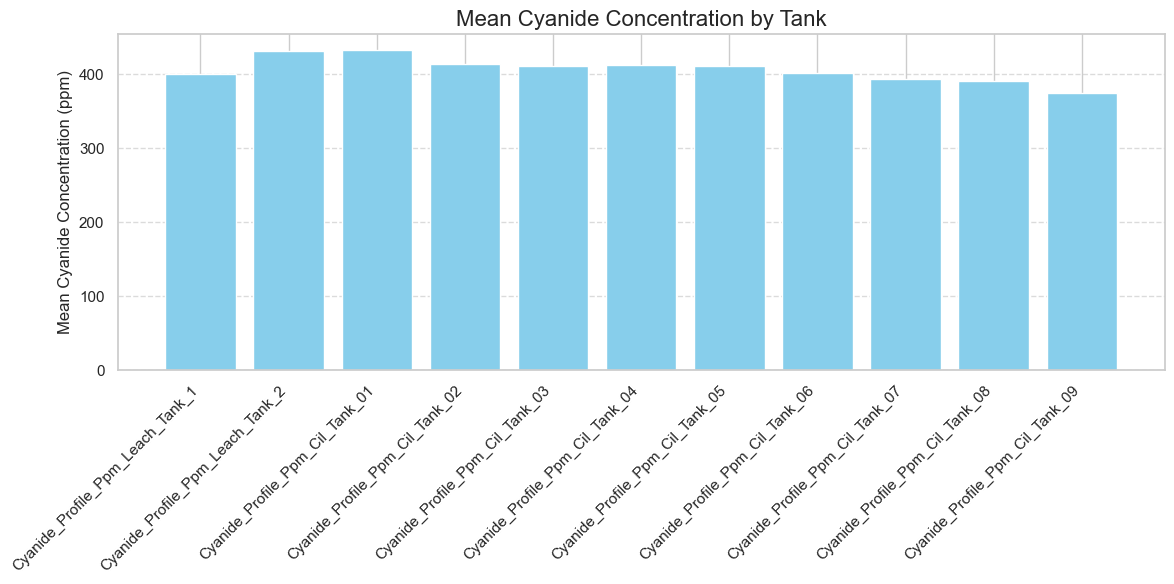

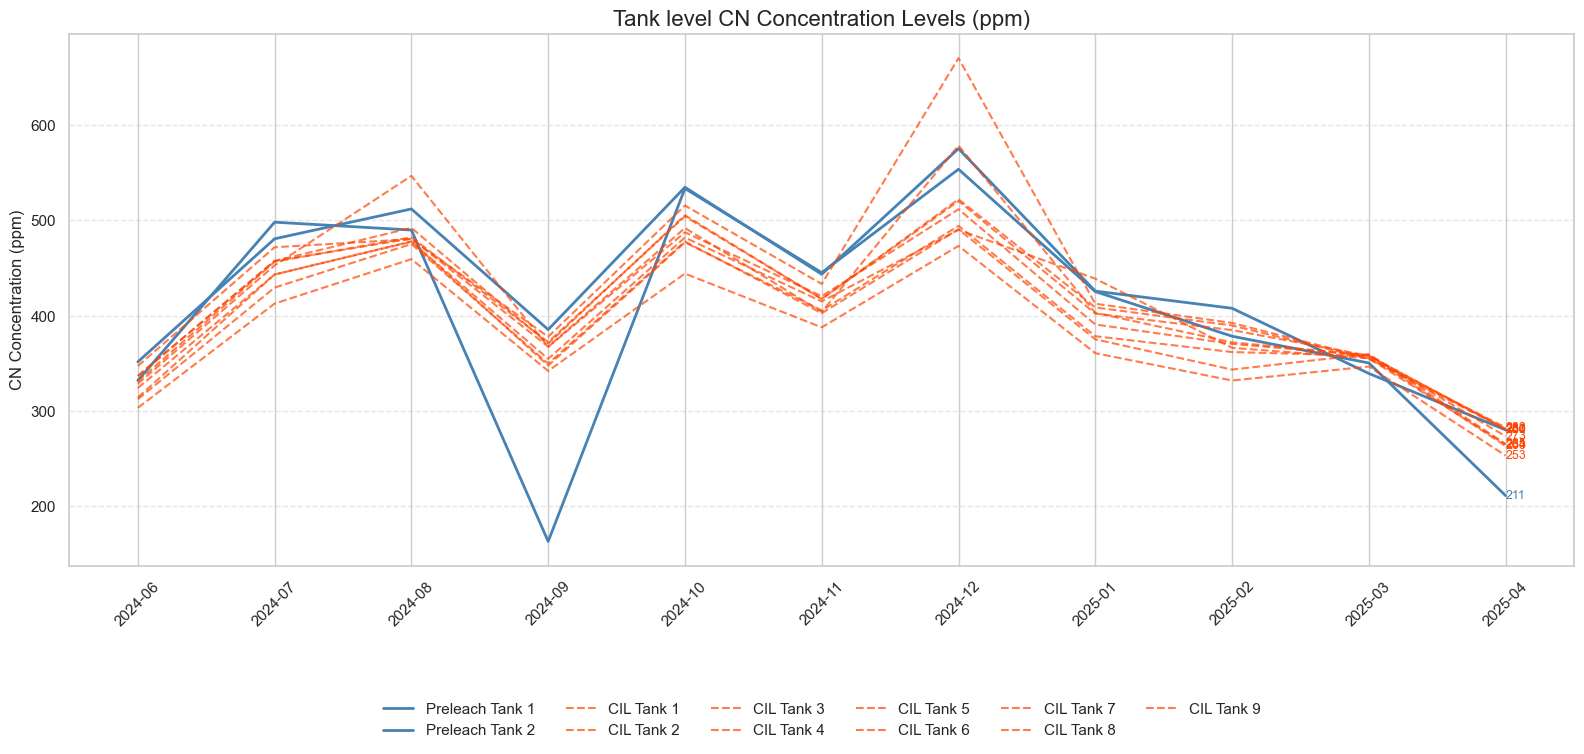

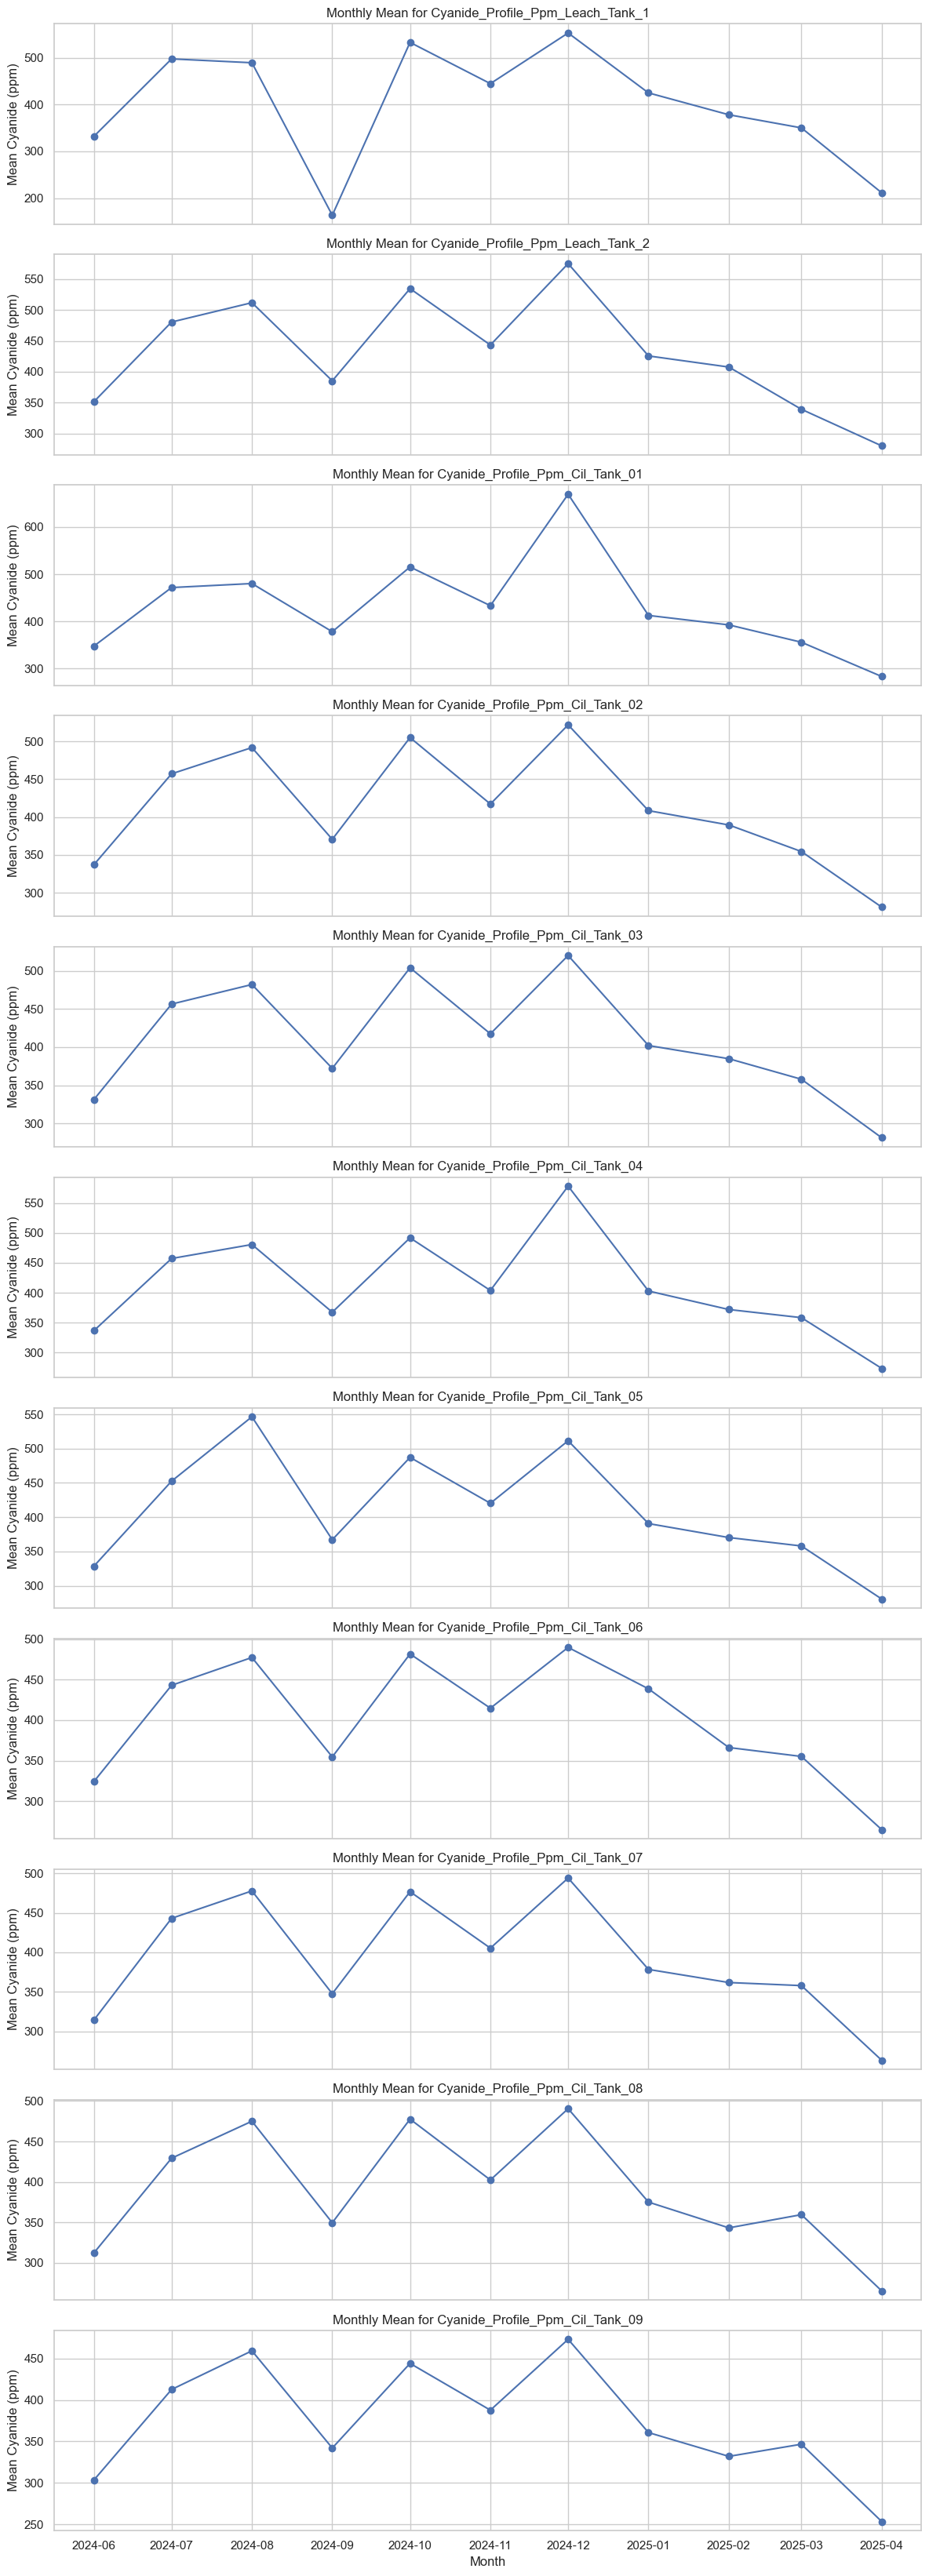

In [89]:
# Define cyanide profile columns
cyanide_profiles = [
	'Cyanide_Profile_Ppm_Leach_Tank_1',
	'Cyanide_Profile_Ppm_Leach_Tank_2',
	'Cyanide_Profile_Ppm_Cil_Tank_01',
	'Cyanide_Profile_Ppm_Cil_Tank_02',
	'Cyanide_Profile_Ppm_Cil_Tank_03',
	'Cyanide_Profile_Ppm_Cil_Tank_04',
	'Cyanide_Profile_Ppm_Cil_Tank_05',
	'Cyanide_Profile_Ppm_Cil_Tank_06',
	'Cyanide_Profile_Ppm_Cil_Tank_07',
	'Cyanide_Profile_Ppm_Cil_Tank_08',
	'Cyanide_Profile_Ppm_Cil_Tank_09',
]

# Calculate the mean for each cyanide profile column
cyanide_means = df[cyanide_profiles].mean(numeric_only=True)

# Create a bar plot for the cyanide means
plt.figure(figsize=(12, 6))
plt.bar(cyanide_means.index, cyanide_means.values, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Cyanide Concentration (ppm)')
plt.title('Mean Cyanide Concentration by Tank', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



labels = [
	"Preleach Tank 1", "Preleach Tank 2",
	"CIL Tank 1", "CIL Tank 2", "CIL Tank 3", "CIL Tank 4", "CIL Tank 5",
	"CIL Tank 6", "CIL Tank 7", "CIL Tank 8", "CIL Tank 9"
]

# Calculate monthly means
monthly_means = df.groupby("Month")[cyanide_profiles].mean().reset_index()
month_labels = monthly_means["Month"].astype(str)

# Plot multi-line CN concentration per tank
plt.figure(figsize=(16, 8))
for profile, label in zip(cyanide_profiles, labels):
	if "Leach" in profile:
		style = dict(color='steelblue', linewidth=2, linestyle='-')
	else:
		style = dict(color='orangered', linewidth=1.5, linestyle='--', alpha=0.7)

	y_values = monthly_means[profile].values
	plt.plot(month_labels, y_values, label=label, **style)

	# Annotate final value
	final_val = y_values[-1]
	plt.text(len(month_labels) - 1, final_val, f"{int(final_val)}", fontsize=9,
			 color=style["color"], ha='left', va='center')

plt.title("Tank level CN Concentration Levels (ppm)", fontsize=16)
plt.ylabel("CN Concentration (ppm)")
plt.xticks(rotation=45)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=6, frameon=False)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Ensure the DataFrame has a datetime column; attempt to find and parse it
date_column = None
for col in df.columns:
	if "date" in col.lower():
		date_column = col
		break

if date_column:
	df[date_column] = pd.to_datetime(df[date_column])
	df["Month"] = df[date_column].dt.to_period("M")
else:
	raise ValueError("No date-like column found for grouping by month.")

# Group by month and calculate means for each cyanide profile column
monthly_means = df.groupby("Month")[cyanide_profiles].mean()

# Create subplots for each cyanide profile over time
num_plots = len(cyanide_profiles)
fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(12, 3 * num_plots), sharex=True)

for i, column in enumerate(cyanide_profiles):
	axes[i].plot(monthly_means.index.to_timestamp(), monthly_means[column], marker='o')
	axes[i].set_title(f"Monthly Mean for {column}")
	axes[i].set_ylabel('Mean Cyanide (ppm)')
	axes[i].grid(True)

axes[-1].set_xlabel('Month')
plt.tight_layout()
plt.show()


### 📊 2.2: Feed & Recovery

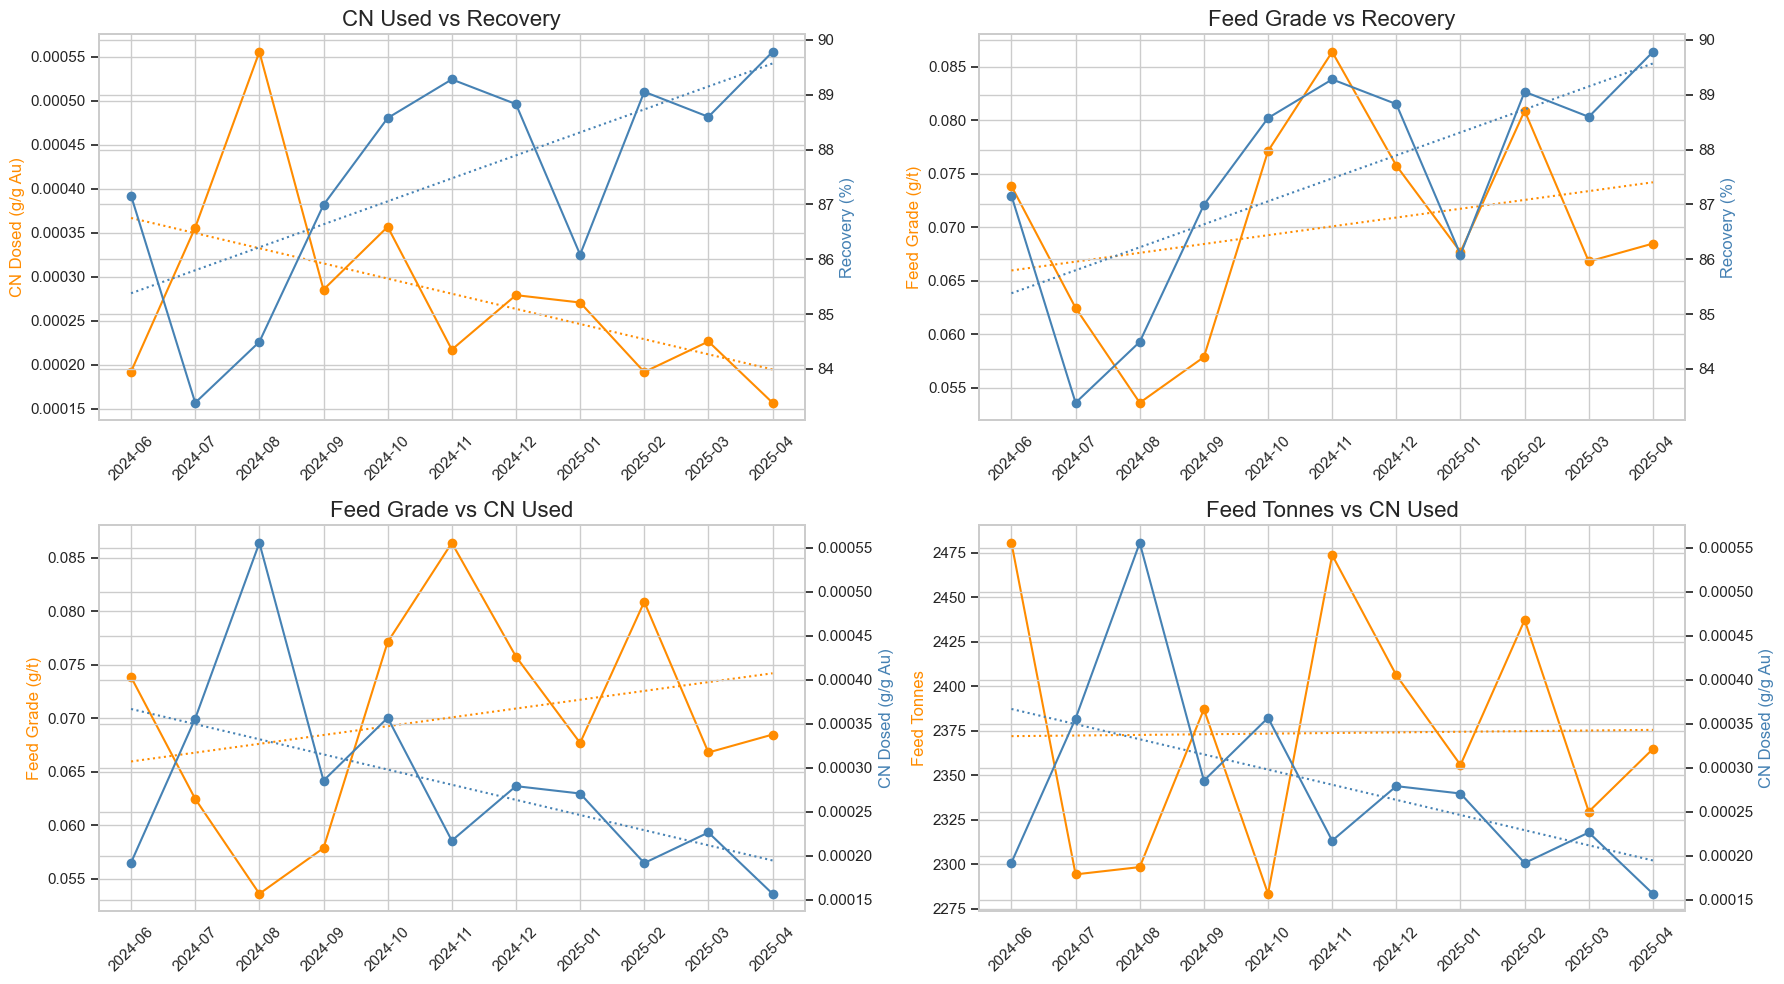

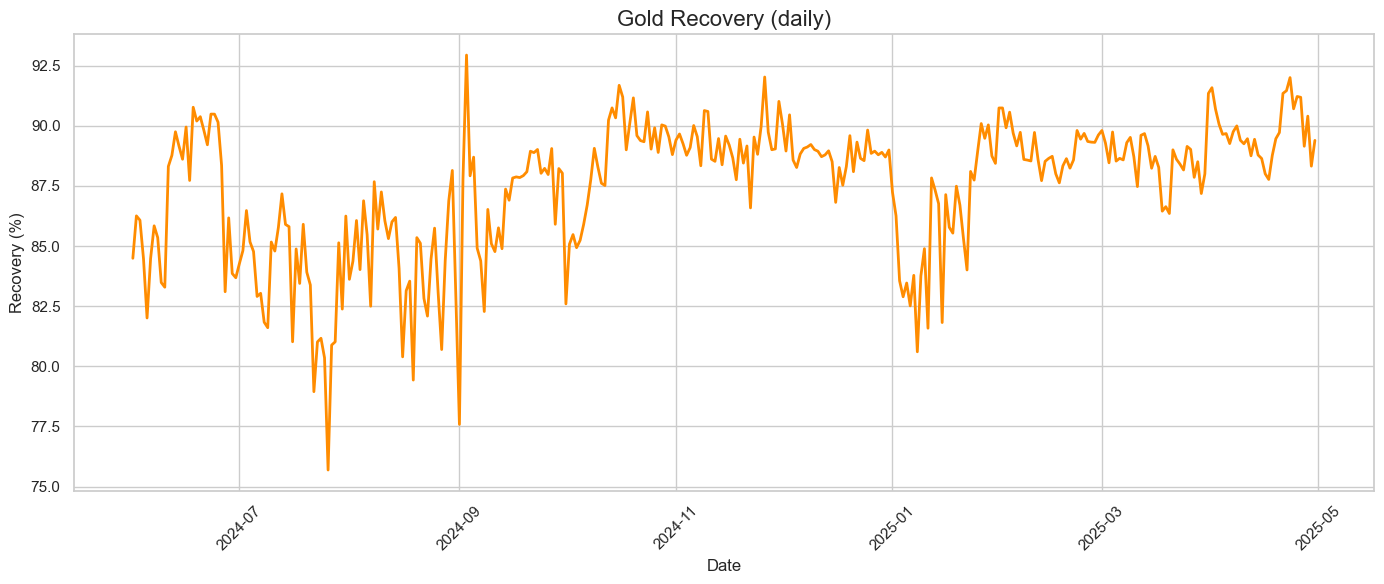

In [90]:
# Add recovery and CN dosed metrics to the dataframe
df["CN_Dosed_g_per_g_Au"] = (df["Estimated_NaCN_Used_Kg_Scaled"] / 1000) / df["Cil_Feed_Total_Au_Grams"]

df["Au_Recovery_pct"] = (
	(df["Cil_Feed_Total_Au_Grams"] - df["Total_Au_Tailing_Grams"])
	/ df["Cil_Feed_Total_Au_Grams"]
) * 100

df["Feed_Grade_gpt"] = df["Cil_Feed_Total_Au_Grams"] / 31.1035 / df["Daily_Milledtreated_Tons"]

# Group by month and calculate mean values
monthly_summary = df.groupby("Month").agg({
	"CN_Dosed_g_per_g_Au": "mean",
	"Au_Recovery_pct": "mean",
	"Feed_Grade_gpt": "mean"
}).reset_index()

# Prepare time series data
monthly_summary["Month"] = monthly_summary["Month"].astype(str)  # Convert Period to string for plotting

# Add ore feed tonnes to monthly summary
monthly_summary["Feed_Tonnes"] = df.groupby("Month")["Daily_Milledtreated_Tons"].mean().values

# Set up a 2x2 grid of dual-axis subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
month_labels = monthly_summary["Month"]

# --- Subplot 1: CN Used vs Recovery ---
ax = axes[0, 0]
ax.plot(month_labels, monthly_summary["CN_Dosed_g_per_g_Au"], color='darkorange', marker='o', label="CN g / Au g")
z1 = np.polyfit(range(len(month_labels)), monthly_summary["CN_Dosed_g_per_g_Au"], 1)
ax.plot(month_labels, np.poly1d(z1)(range(len(month_labels))), linestyle='dotted', color='darkorange')

ax2 = ax.twinx()
ax2.plot(month_labels, monthly_summary["Au_Recovery_pct"], color='steelblue', marker='o', label="Recovery")
z2 = np.polyfit(range(len(month_labels)), monthly_summary["Au_Recovery_pct"], 1)
ax2.plot(month_labels, np.poly1d(z2)(range(len(month_labels))), linestyle='dotted', color='steelblue')

ax.set_title("CN Used vs Recovery", fontsize=16)
ax.set_ylabel("CN Dosed (g/g Au)", color='darkorange')
ax2.set_ylabel("Recovery (%)", color='steelblue')
ax.tick_params(axis='x', rotation=45)

# --- Subplot 2: Feed Grade vs Recovery ---
ax = axes[0, 1]
ax.plot(month_labels, monthly_summary["Feed_Grade_gpt"], color='darkorange', marker='o', label="Feed Grade")
z3 = np.polyfit(range(len(month_labels)), monthly_summary["Feed_Grade_gpt"], 1)
ax.plot(month_labels, np.poly1d(z3)(range(len(month_labels))), linestyle='dotted', color='darkorange')

ax2 = ax.twinx()
ax2.plot(month_labels, monthly_summary["Au_Recovery_pct"], color='steelblue', marker='o', label="Recovery")
z4 = np.polyfit(range(len(month_labels)), monthly_summary["Au_Recovery_pct"], 1)
ax2.plot(month_labels, np.poly1d(z4)(range(len(month_labels))), linestyle='dotted', color='steelblue')

ax.set_title("Feed Grade vs Recovery", fontsize=16)
ax.set_ylabel("Feed Grade (g/t)", color='darkorange')
ax2.set_ylabel("Recovery (%)", color='steelblue')
ax.tick_params(axis='x', rotation=45)

# --- Subplot 3: Feed Grade vs CN Used ---
ax = axes[1, 0]
ax.plot(month_labels, monthly_summary["Feed_Grade_gpt"], color='darkorange', marker='o', label="Feed Grade")
z5 = np.polyfit(range(len(month_labels)), monthly_summary["Feed_Grade_gpt"], 1)
ax.plot(month_labels, np.poly1d(z5)(range(len(month_labels))), linestyle='dotted', color='darkorange')

ax2 = ax.twinx()
ax2.plot(month_labels, monthly_summary["CN_Dosed_g_per_g_Au"], color='steelblue', marker='o', label="CN g / Au g")
z6 = np.polyfit(range(len(month_labels)), monthly_summary["CN_Dosed_g_per_g_Au"], 1)
ax2.plot(month_labels, np.poly1d(z6)(range(len(month_labels))), linestyle='dotted', color='steelblue')

ax.set_title("Feed Grade vs CN Used", fontsize=16)
ax.set_ylabel("Feed Grade (g/t)", color='darkorange')
ax2.set_ylabel("CN Dosed (g/g Au)", color='steelblue')
ax.tick_params(axis='x', rotation=45)

# --- Subplot 4: Feed Tonnes vs CN Used ---
ax = axes[1, 1]
ax.plot(month_labels, monthly_summary["Feed_Tonnes"], color='darkorange', marker='o', label="Feed Tonnes")
z7 = np.polyfit(range(len(month_labels)), monthly_summary["Feed_Tonnes"], 1)
ax.plot(month_labels, np.poly1d(z7)(range(len(month_labels))), linestyle='dotted', color='darkorange')

ax2 = ax.twinx()
ax2.plot(month_labels, monthly_summary["CN_Dosed_g_per_g_Au"], color='steelblue', marker='o', label="CN g / Au g")
z8 = np.polyfit(range(len(month_labels)), monthly_summary["CN_Dosed_g_per_g_Au"], 1)
ax2.plot(month_labels, np.poly1d(z8)(range(len(month_labels))), linestyle='dotted', color='steelblue')

ax.set_title("Feed Tonnes vs CN Used", fontsize=16)
ax.set_ylabel("Feed Tonnes", color='darkorange')
ax2.set_ylabel("CN Dosed (g/g Au)", color='steelblue')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Create line plot of daily Au recovery
plt.figure(figsize=(14, 6))
plt.plot(df[date_column], df["Au_Recovery_pct"], color='darkorange', linewidth=2)
plt.title("Gold Recovery (daily)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Recovery (%)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### 📊 2.3: Dissolved Gold Profiles

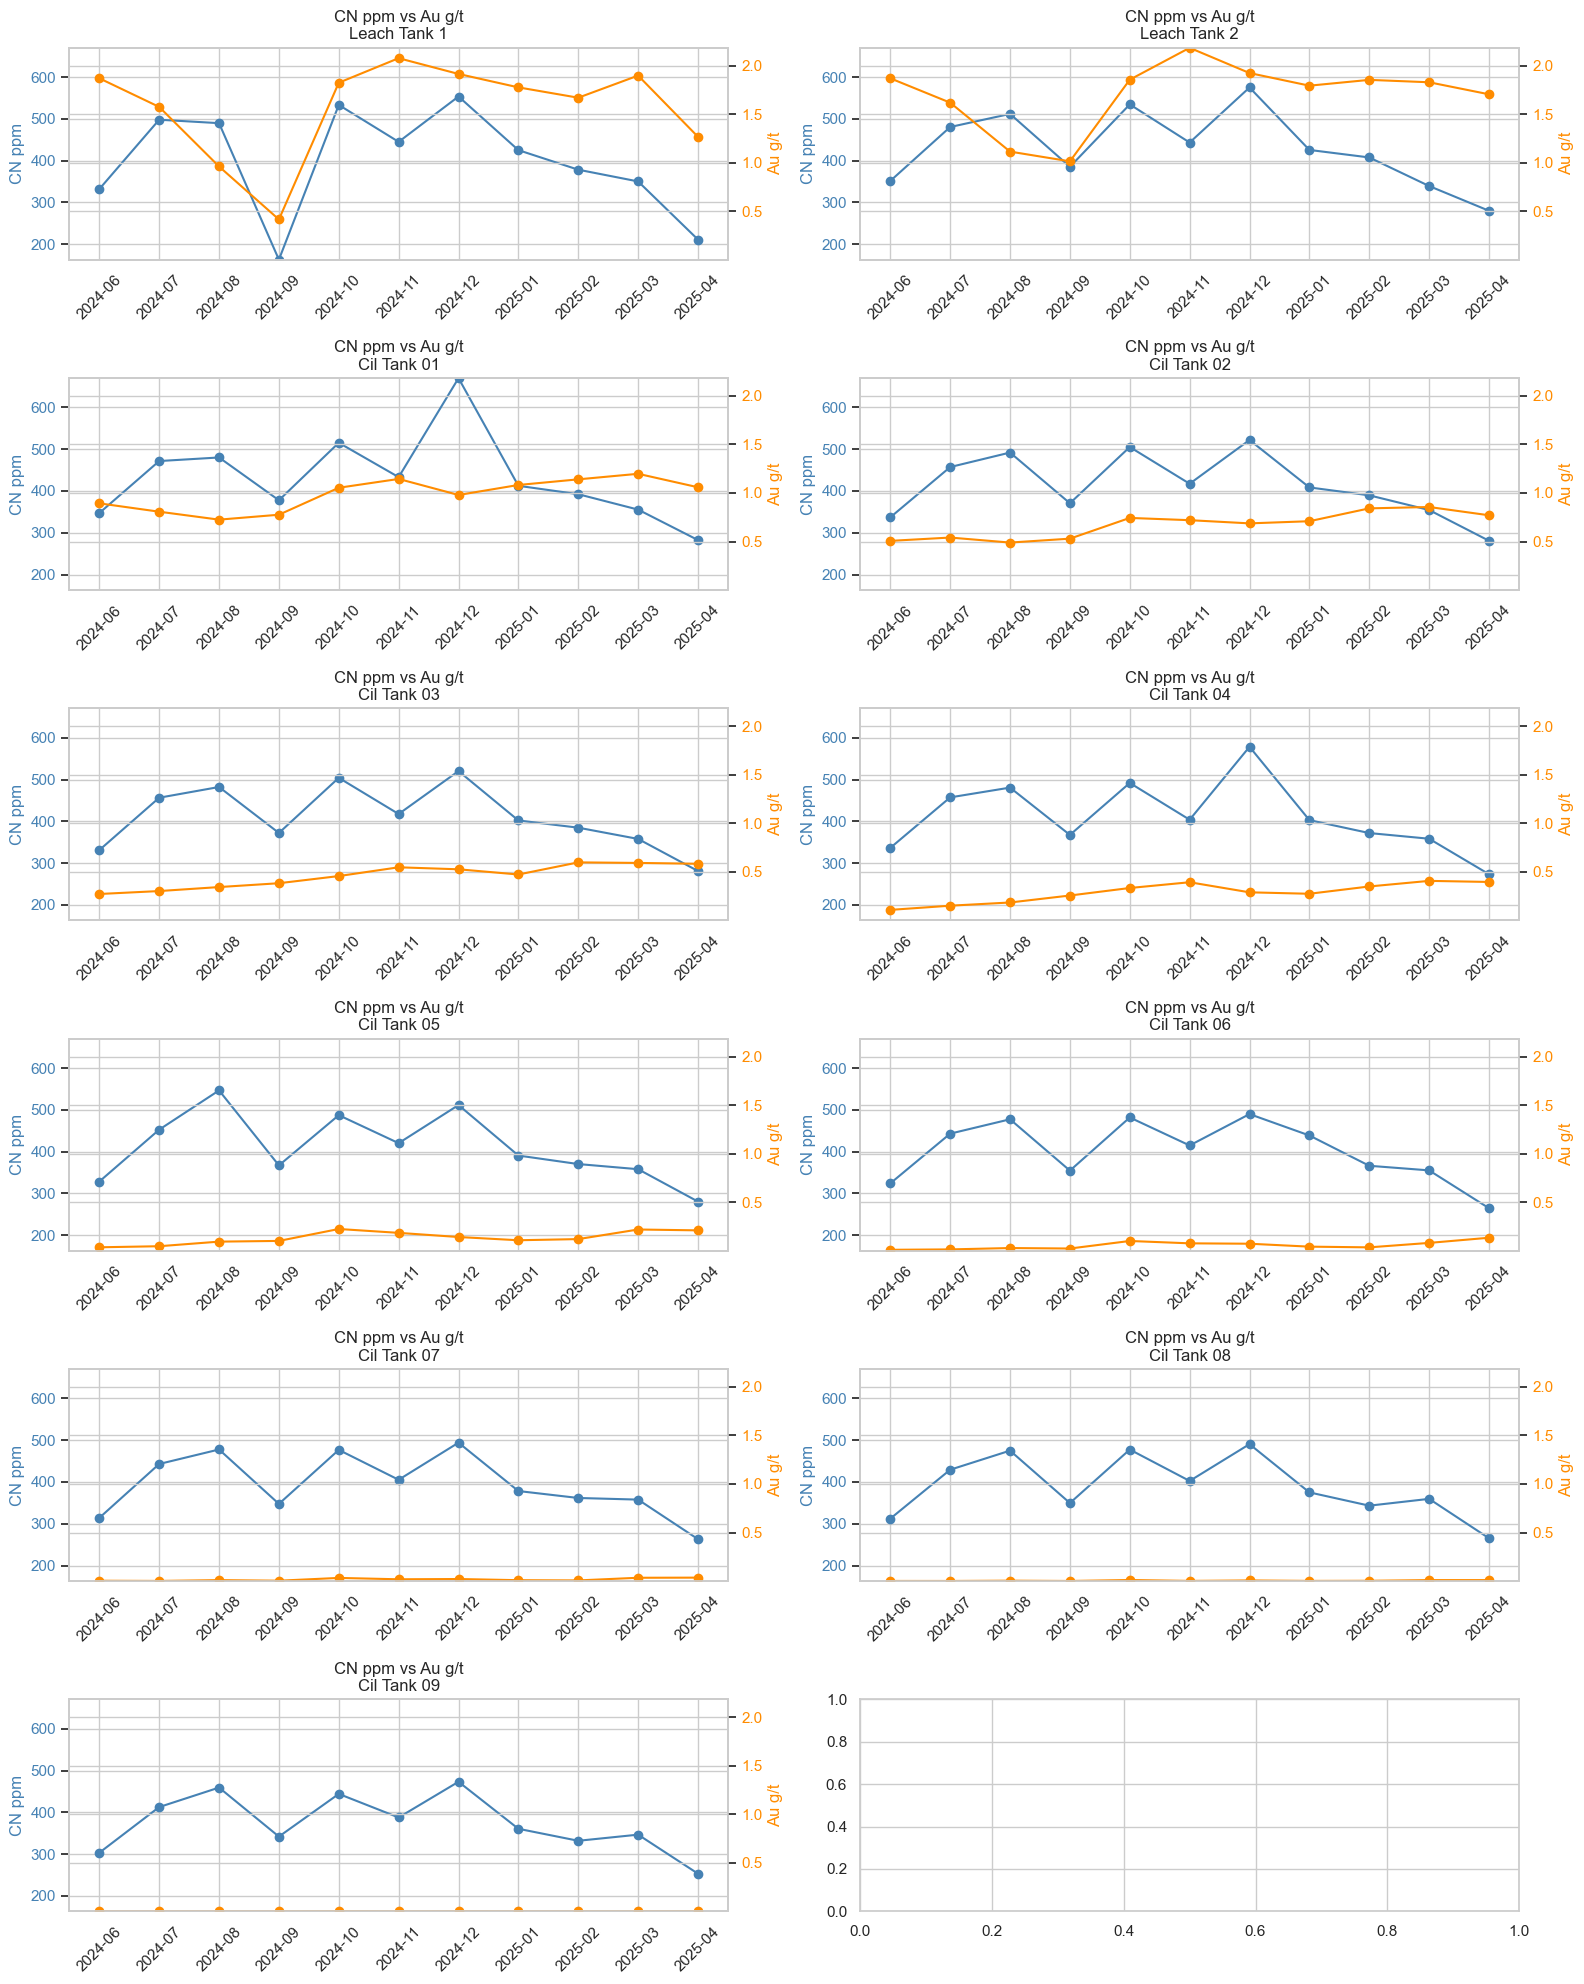

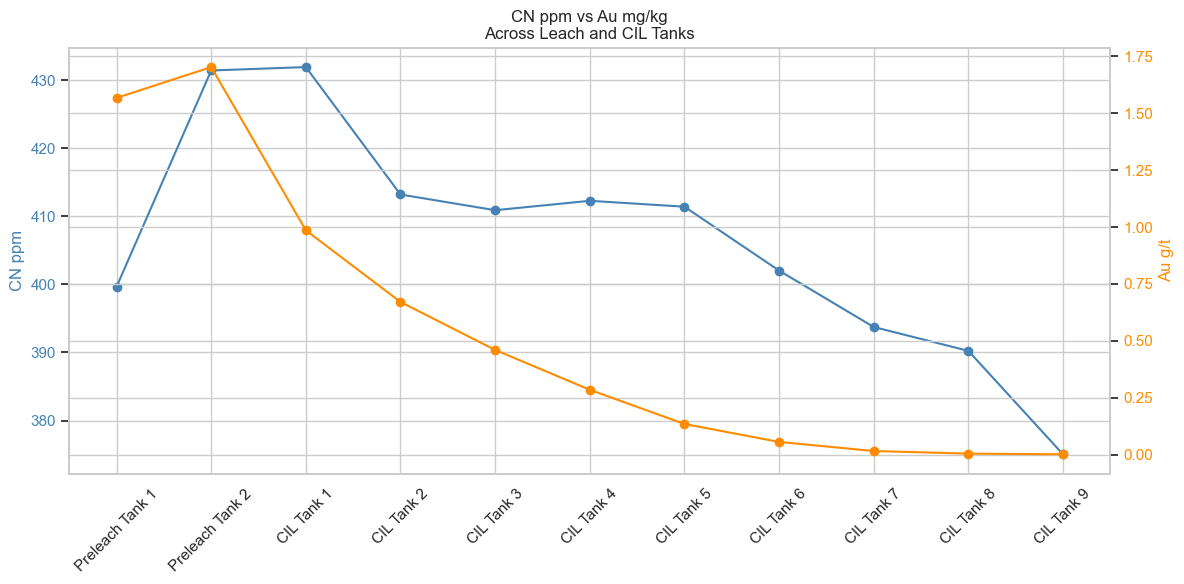

In [91]:
# Define the gold and cyanide profile fields for each tank
dissolved_gold_profiles = [
	'Dissolved_Gold_Metal_Profile_G_Milled_Tons_Leach_Tank_01',
	'Dissolved_Gold_Metal_Profile_G_Milled_Tons_Leach_Tank_02',
	'Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_01',
	'Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_02',
	'Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_03',
	'Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_04',
	'Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_05',
	'Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_06',
	'Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_07',
	'Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_08',
	'Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_09',
]

# Parse datetime and extract month
for col in df.columns:
	if "date" in col.lower():
		date_column = col
		break

df[date_column] = pd.to_datetime(df[date_column])
df["Month"] = df[date_column].dt.to_period("M")

# Compute monthly means for both dissolved gold and cyanide concentration
monthly_means = df.groupby("Month")[dissolved_gold_profiles + cyanide_profiles].mean().reset_index()
month_labels = monthly_means["Month"].astype(str)

# Create 2x6 grid of dual-axis subplots
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(16, 20))  # Previously: nrows=2, ncols=6
axes = axes.flatten()

cn_min = monthly_means[cyanide_profiles].min().min()
cn_max = monthly_means[cyanide_profiles].max().max()
au_min = monthly_means[dissolved_gold_profiles].min().min()
au_max = monthly_means[dissolved_gold_profiles].max().max()

def extract_stage(text):
	parts = text.split("_")
	for p in parts:
		if p.lower() in ["leach", "cil"]:
			return p.title()
	return None


for i, (gold_col, cn_col) in enumerate(zip(dissolved_gold_profiles, cyanide_profiles)):
	ax = axes[i]
	ax.plot(month_labels, monthly_means[cn_col], color='steelblue', marker='o', label="CN ppm")
	ax.set_ylabel("CN ppm", color='steelblue')
	ax.tick_params(axis='y', labelcolor='steelblue')

	ax2 = ax.twinx()
	ax2.plot(month_labels, monthly_means[gold_col], color='darkorange', marker='o', label="Au g/t")
	ax2.set_ylabel("Au g/t", color='darkorange')
	ax2.tick_params(axis='y', labelcolor='darkorange')

	section_label = extract_stage(cn_col)
	tank_label = cn_col.split("_Tank_")[-1]
	ax.set_title(f"CN ppm vs Au g/t\n{section_label} Tank {tank_label}")
	ax.set_xticks(range(len(month_labels)))
	ax.set_xticklabels(month_labels, rotation=45)

	ax.set_ylim(cn_min, cn_max)
	ax2.set_ylim(au_min, au_max)

plt.tight_layout()
plt.show()

# Take average over the full dataset
cn_means = df[cyanide_profiles].mean()
au_means = df[dissolved_gold_profiles].mean()

# Create a new list of tank labels (to match Excel-style labels)
labels = [
	"Preleach Tank 1", "Preleach Tank 2",
	"CIL Tank 1", "CIL Tank 2", "CIL Tank 3", "CIL Tank 4", "CIL Tank 5",
	"CIL Tank 6", "CIL Tank 7", "CIL Tank 8", "CIL Tank 9"
]

# Create dual-axis profile plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(labels, cn_means.values, label="CN ppm", color='steelblue', marker='o')
ax.set_ylabel("CN ppm", color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)


ax2 = ax.twinx()
ax2.plot(labels, au_means.values, label="Au g/t", color='darkorange', marker='o')
ax2.set_ylabel("Au g/t", color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax.set_title("CN ppm vs Au mg/kg\nAcross Leach and CIL Tanks")
plt.tight_layout()
plt.show()

## ⚙️ 3: Define Constants & User Parameters

Define model constants and user-configurable parameters to control the leaching simulation and modelling behaviour. These parameters govern core assumptions such as particle size bands, locked gold fraction, residence time, and number of tanks.

**Includes:**
- Fixed values for particle sizing and liberation model
- Gold grain size and locked fraction estimates
- Number of CIL tanks and residence time assumptions

In [92]:
# Define random seed for reproducibility
random_seed = 13

# Define static tank volumes
tank_config = {
	"Cyanide_Profile_Ppm_Leach_Tank_1": 1000,
	"Cyanide_Profile_Ppm_Leach_Tank_2": 1000,
	"Cyanide_Profile_Ppm_Cil_Tank_1": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_2": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_3": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_4": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_5": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_6": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_7": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_8": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_9": 250,
}
total_circuit_volume = sum(tank_config.values())	# total volume of the leaching circuit in m³

# Define constants for ore characteristics
d = 20 												# ore particle size µm
particle_size_threshold = 50 						# µm (particles larger than this are considered coarse)
locked_gold_threshold = 0.02 						# 2% gold remains locked in the ore after leaching
liberation_fraction = 1 - locked_gold_threshold		# fraction of gold that is liberated and available for leaching
density = 2.7  										# t/m³ (typical for gold ore)

# Define constants for leaching process
n_tanks = 11										# number of tanks in the leaching circuit	
total_residence_time = 30 							# total residence time in hours
min_cn_conc = 100 									# minimum cyanide concentration in ppm
max_cn_conc = 1000 									# maximum cyanide concentration in ppm
cn_decay_factor = 0.85  				# % CN that remains from one tank to the next in the series
max_nacn_drawdown = 12
max_dissolution_rate = 100				# maximum gold dissolution rate in mg/kg/h
outlier_thresholds = {
	'Nacn_Used_T': (0, 10),  						# t NaCN used per day
	'Daily_Nacn_Consumption_Kgt': (0, 10),			# kg NaCN consumed per tonne of ore
	'MTD_Nacn_Consumption_Kgt': (0, 10)				# kg NaCN consumed per tonne of ore
}
o2_smoothing_window = 45							# smoothing window for O2 data
pulp_density = 1.5  								# kg/L
constant_pulp_density = True 						# use constant pulp density based on ore type
solid_density = 2.7  								# t/m³
liquid_density = 1.0  								# t/m³ (mostly water, even after dilution)

# Feed charateristics
ultra_fine_sizing = 50	 							# midpoint for < 75 µm sizing
fine_sizing = 112.5									# midpoint for > 75 µm sizing
coarse_sizing = 175 								# midpoint for > 150 µm sizing

## 4:🚩 Flag Mismatched Conditions
Define and compute diagnostic flags that help identify patterns such as:
* Cyanide overdose with no recovery gain
* High-grade ore underperforming in recovery
* Fines fraction inefficiency (e.g. fine grind but poor recovery)

| Flag                         | Description                                   |
| ---------------------------- | --------------------------------------------- |
| `CN_Overdose_Flag`           | High cyanide dose but low recovery            |
| `High_Grade_Underperforming` | Strong feed grade but below-expected recovery |
| `Fines_Inefficiency`         | Fine grind but poor recovery benefit          |
| *(Optional)* `DO_Drop_Flag`  | Persistently low dissolved oxygen             |


In [93]:
# Compute Effective Particle Size
def get_effective_particle_size(row):
	total = (
		row["Leach_Feed_Lt_75um_Day"] +
		row["Leach_Feed_Gt_75um_Day"] +
		row["Leach_Feed_Gt_150um_Day"]
	)
	if total == 0:
		return np.nan
	weighted_d = (
		row["Leach_Feed_Lt_75um_Day"] * ultra_fine_sizing +
		row["Leach_Feed_Gt_75um_Day"] * fine_sizing +
		row["Leach_Feed_Gt_150um_Day"] * coarse_sizing
	) / total
	return weighted_d

df["Effective_Particle_Size_um"] = df.apply(get_effective_particle_size, axis=1)

# Define thresholds (can be tuned later)
CN_DOSE_THRESHOLD = 2000  # kg/day
RECOVERY_LOW_THRESHOLD = 85  # %
FEED_GRADE_HIGH_THRESHOLD = 2.5  # g/t
FINES_HIGH_THRESHOLD = 70  # % passing <75um

# Create diagnostic flags
df['CN_Overdose_Flag'] = (
	(df['Predicted_NaCN_Used_kg'] > CN_DOSE_THRESHOLD) &
	(df['Au_Recovery_pct'] < RECOVERY_LOW_THRESHOLD)
)

df['High_Grade_Underperforming'] = (
	(df['Feed_Grade_gpt'] > FEED_GRADE_HIGH_THRESHOLD) &
	(df['Au_Recovery_pct'] < RECOVERY_LOW_THRESHOLD)
)

# Assuming 'Fines_Fraction' column exists; if not, this line should be adapted
fines_col_candidates = [col for col in df.columns if 'Fines' in col and 'Fraction' in col]
fines_col = fines_col_candidates[0] if fines_col_candidates else None

if fines_col:
	df['Fines_Inefficiency'] = (
		(df[fines_col] > FINES_HIGH_THRESHOLD) &
		(df['Au_Recovery_pct'] < RECOVERY_LOW_THRESHOLD)
	)
else:
	df['Fines_Inefficiency'] = False  # Placeholder if fines column not found

# Count flag instances
flag_counts = df[['CN_Overdose_Flag', 'High_Grade_Underperforming', 'Fines_Inefficiency']].sum()
flag_counts


CN_Overdose_Flag              22
High_Grade_Underperforming     0
Fines_Inefficiency             0
dtype: int64

#### 🧠 Interpretation:
Here's how the diagnostic flags performed on your cleaned dataset:
| Flag                           | Count | Interpretation                                                                                                                 |
| ------------------------------ | ----- | ------------------------------------------------------------------------------------------------------------------------------ |
| **CN Overdose**                | 22    | Days where cyanide dosage exceeded 2000 kg but recovery was below 85% — suggesting potential overuse without benefit.          |
| **High-Grade Underperforming** | 0     | No days found where feed grade was high (>2.5 g/t) and recovery low. This may indicate good performance on high-grade ore.     |
| **Fines Inefficiency**         | 0     | No days where fines were high (>70%) and recovery still underperformed. Suggests fines are generally having a positive effect. |


## Visual Diagnostics

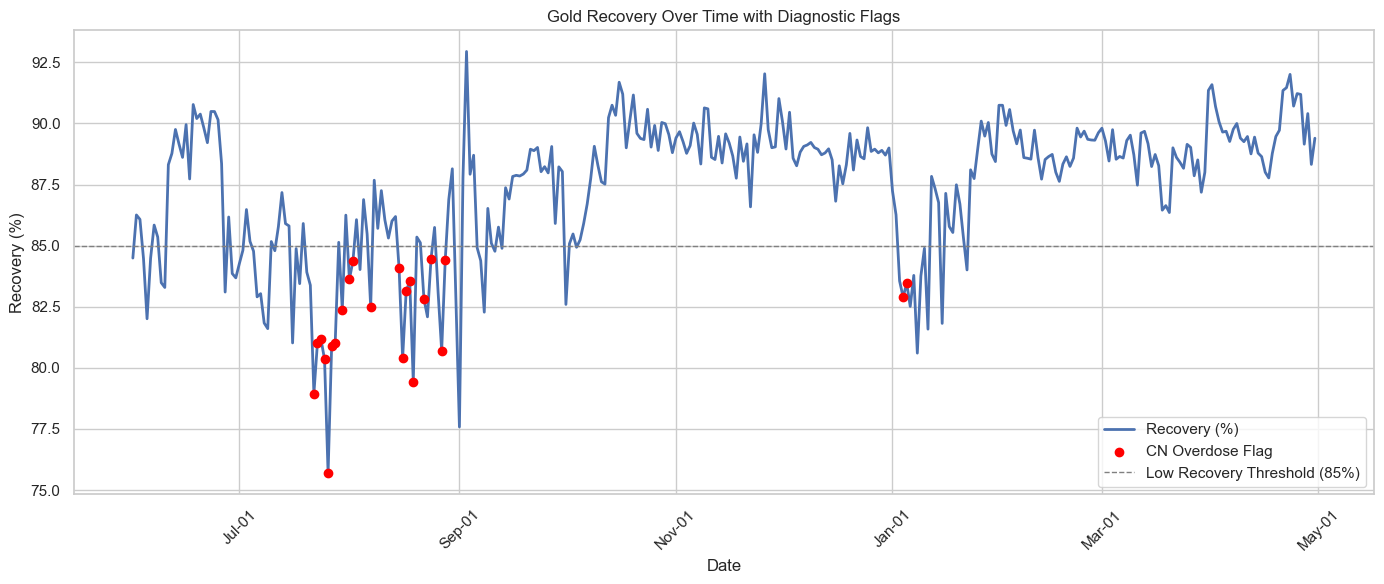

In [94]:
# Prepare date column
df['Date'] = pd.to_datetime(df['Date'])

# Set figure style
sns.set_theme(style="whitegrid")

# Plot flagged periods over Recovery % time series
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='Date', y='Au_Recovery_pct', label='Recovery (%)', linewidth=2)

# Highlight CN Overdose
cn_overdose_dates = df[df['CN_Overdose_Flag']]['Date']
plt.scatter(cn_overdose_dates, df.loc[df['CN_Overdose_Flag'], 'Au_Recovery_pct'],
			color='red', label='CN Overdose Flag', zorder=5)

# Formatting
plt.title('Gold Recovery Over Time with Diagnostic Flags')
plt.xlabel('Date')
plt.ylabel('Recovery (%)')
plt.axhline(85, color='grey', linestyle='--', linewidth=1, label='Low Recovery Threshold (85%)')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


These are days where:
* Cyanide dosage exceeded 2000 kg, and
* Recovery was below 85%

### Fines Fraction vs Recovery

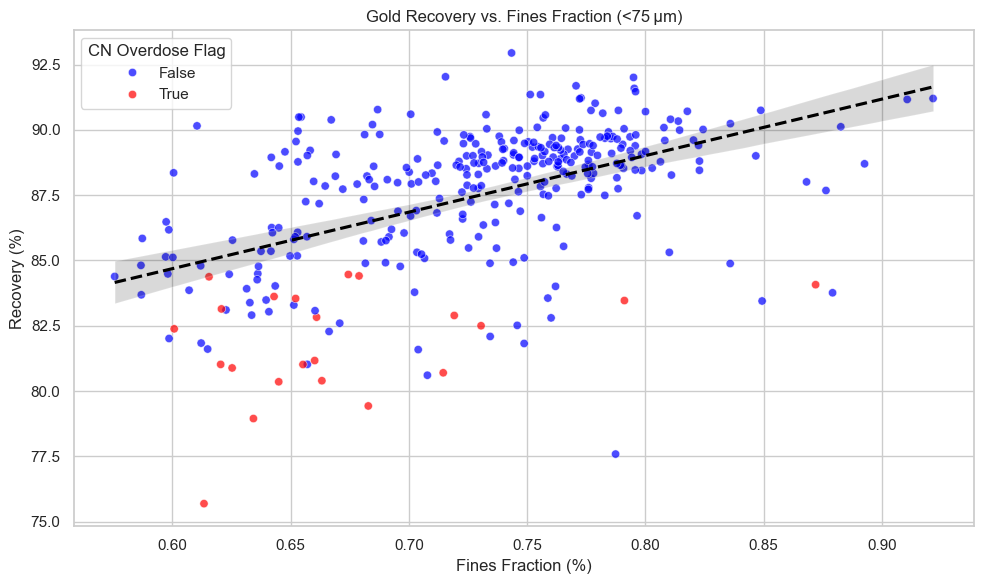

In [95]:
# 1. Fines Fraction vs Recovery
if fines_col:
	plt.figure(figsize=(10, 6))
	sns.scatterplot(data=df, x=fines_col, y='Au_Recovery_pct', hue='CN_Overdose_Flag', palette={False: 'blue', True: 'red'}, alpha=0.7)
	sns.regplot(data=df, x=fines_col, y='Au_Recovery_pct', scatter=False, color='black', line_kws={'linestyle': '--'})
	plt.title('Gold Recovery vs. Fines Fraction (<75 µm)')
	plt.xlabel('Fines Fraction (%)')
	plt.ylabel('Recovery (%)')
	plt.legend(title='CN Overdose Flag')
	plt.grid(True)
	plt.tight_layout()
	plt.show()
else:
	print("No fines fraction column found to plot against recovery.")


#### 🔍 What the plot shows:
This scatter plot shows Gold Recovery vs Fines Fraction (<75 µm):
* A **positive trend** is visible: higher fines fractions generally correspond to higher recovery.
* **Red points** mark instances where cyanide dosage was flagged as excessive—most of these occur at mid-to-high fines levels, but with lower-than-expected recovery.
* The **dashed trend line** reinforces the overall upward slope, consistent with earlier correlation findings (~0.53).

### Feed Grade vs Recovery

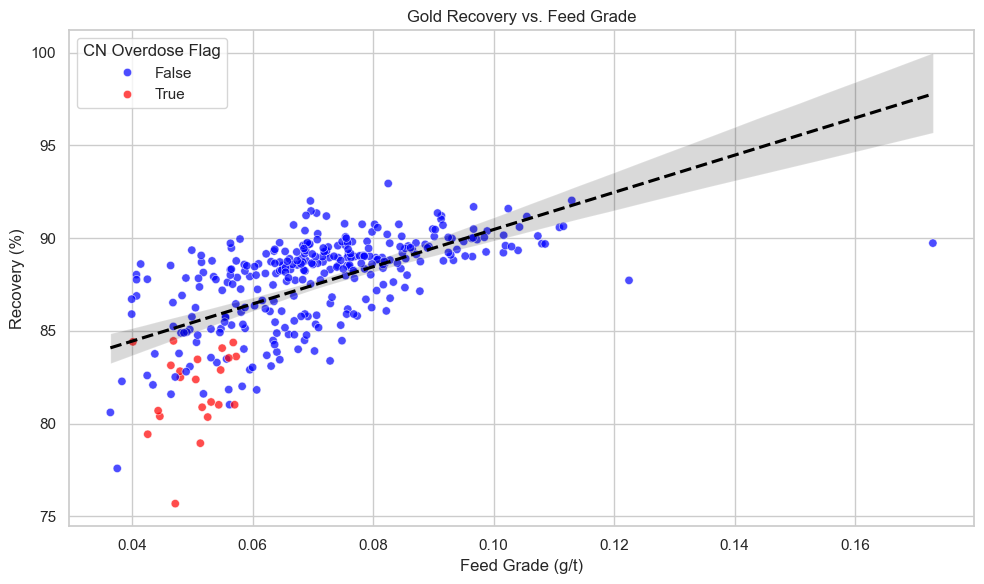

In [96]:
# 2. Feed Grade vs Recovery
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Feed_Grade_gpt', y='Au_Recovery_pct', hue='CN_Overdose_Flag', palette={False: 'blue', True: 'red'}, alpha=0.7)
sns.regplot(data=df, x='Feed_Grade_gpt', y='Au_Recovery_pct', scatter=False, color='black', line_kws={'linestyle': '--'})
plt.title('Gold Recovery vs. Feed Grade')
plt.xlabel('Feed Grade (g/t)')
plt.ylabel('Recovery (%)')
plt.legend(title='CN Overdose Flag')
plt.grid(True)
plt.tight_layout()
plt.show()


#### 🔍 What the plot shows:
* A **strong positive trend** is evident — as feed grade increases, recovery improves.
* There are **no flagged overdose cases** at the high end of feed grade, aligning with earlier findings that high-grade ore was not underperforming.
* The **dashed trend line** confirms the upward relationship, reinforcing that feed grade is a reliable predictor of recovery.

### Cyanide Dosage vs Recovery

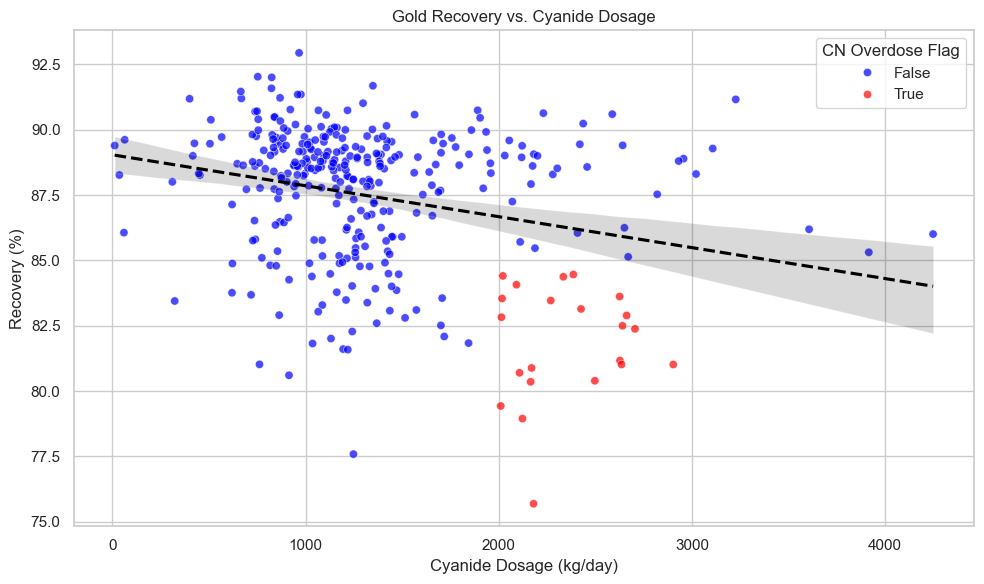

In [97]:
# 3. CN Dosage vs Recovery
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Predicted_NaCN_Used_kg', y='Au_Recovery_pct', hue='CN_Overdose_Flag', palette={False: 'blue', True: 'red'}, alpha=0.7)
sns.regplot(data=df, x='Predicted_NaCN_Used_kg', y='Au_Recovery_pct', scatter=False, color='black', line_kws={'linestyle': '--'})
plt.title('Gold Recovery vs. Cyanide Dosage')
plt.xlabel('Cyanide Dosage (kg/day)')
plt.ylabel('Recovery (%)')
plt.legend(title='CN Overdose Flag')
plt.grid(True)
plt.tight_layout()
plt.show()


#### 🔍 What the plot shows:
* The overall trend is **flat to slightly negative**, consistent with the weak negative correlation observed earlier.
* **Red points** (overdose flags) cluster at high CN dosages but span a wide range of recovery — reinforcing the idea that higher doses don't necessarily yield better outcomes.
* The **dashed trend line** gently slopes downward, indicating diminishing or even adverse returns at higher dosing levels.

### Overlay plot of all flags across time

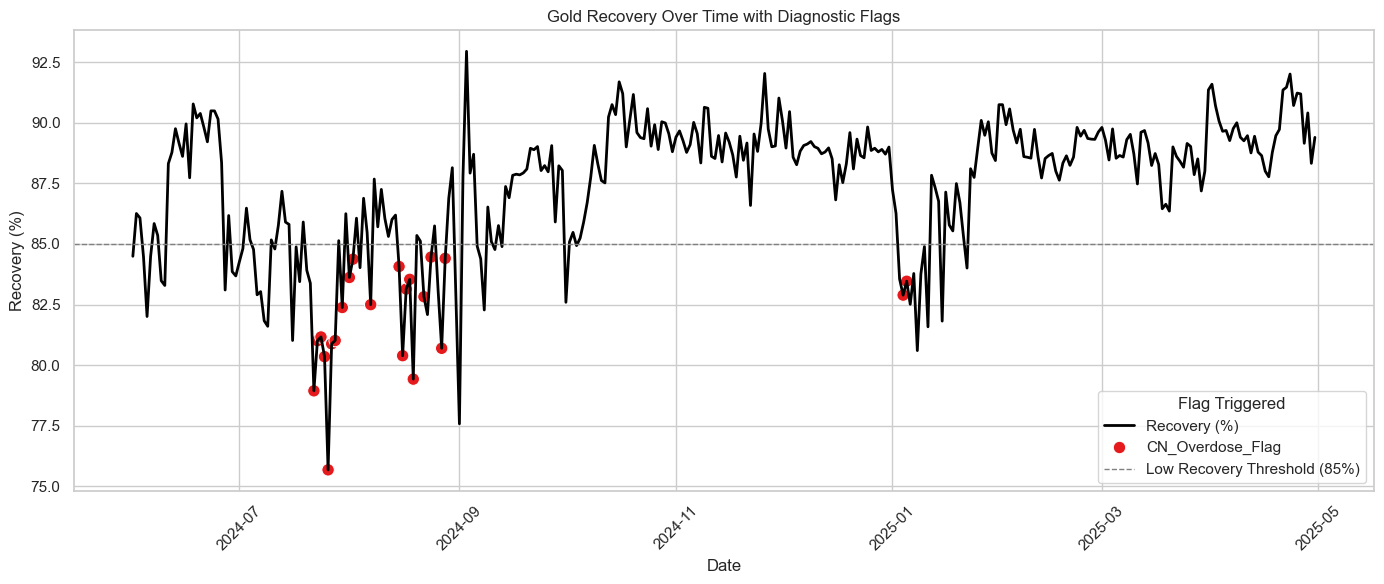

In [98]:
# Convert flags to long format for multi-flag plotting
df_flags_long = df.melt(
	id_vars=['Date', 'Au_Recovery_pct'],
	value_vars=['CN_Overdose_Flag', 'High_Grade_Underperforming', 'Fines_Inefficiency'],
	var_name='Flag',
	value_name='Is_Triggered'
)

# Filter only active flags
df_flags_active = df_flags_long[df_flags_long['Is_Triggered']]

# Plot all flags on recovery time series
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='Date', y='Au_Recovery_pct', label='Recovery (%)', linewidth=2, color='black')

# Plot each flag as a different color
sns.scatterplot(data=df_flags_active, x='Date', y='Au_Recovery_pct', hue='Flag', palette='Set1', s=80)

# Formatting
plt.title('Gold Recovery Over Time with Diagnostic Flags')
plt.xlabel('Date')
plt.ylabel('Recovery (%)')
plt.axhline(85, color='grey', linestyle='--', linewidth=1, label='Low Recovery Threshold (85%)')
plt.legend(title='Flag Triggered')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### 🔍 What the plot shows:
* Red dots (CN Overdose) mark cases of excessive dosing with suboptimal recovery.
* No flags were triggered for high-grade underperformance or fines inefficiency, reinforcing that these conditions were not issues during this period.
* The visual layout makes it easy to spot clusters or patterns, helping guide further investigation or operator attention.

## Feature Selection using Sequential Search
Use SequentialFeatureSelector to automatically test combinations

In [99]:
df_model = df.copy()

features = [
	'Estimated_NaCN_Used_Kg_Scaled',
	'Leach_Feed_Throughput_M3Hr',
	'Percentsolids',
	'Leach_Feed_Grade_Au_Gt_Day',
	'Leach_Feed_Grade_Ag_Gt_Day',
	'Cil_Feed_Total_Au_Grams',
	'Leach_Feed_Gt_150um_Day',
	'Leach_Feed_Gt_75um_Day',
	'Leach_Feed_Lt_75um_Day',
	'Cyanide_Profile_Ppm_Leach_Tank_1',
	'Cyanide_Profile_Ppm_Leach_Tank_2',
	'Cyanide_Profile_Ppm_Cil_Tank_01',
	'Cyanide_Profile_Ppm_Cil_Tank_02',
	'Cyanide_Profile_Ppm_Cil_Tank_03',
	'Cyanide_Profile_Ppm_Cil_Tank_04',
	'Cyanide_Profile_Ppm_Cil_Tank_05',
	'Cyanide_Profile_Ppm_Cil_Tank_06',
	'Cyanide_Profile_Ppm_Cil_Tank_07',
	'Cyanide_Profile_Ppm_Cil_Tank_08',
	'Cyanide_Profile_Ppm_Cil_Tank_09',
	'Carbon_Concentration_Profile_Gl_Cil_Tank_01',
	'Carbon_Concentration_Profile_Gl_Cil_Tank_02',
	'Carbon_Concentration_Profile_Gl_Cil_Tank_03',
	'Carbon_Concentration_Profile_Gl_Cil_Tank_04',
	'Carbon_Concentration_Profile_Gl_Cil_Tank_05',
	'Carbon_Concentration_Profile_Gl_Cil_Tank_06',
	'Carbon_Concentration_Profile_Gl_Cil_Tank_07',
	'Carbon_Concentration_Profile_Gl_Cil_Tank_08',
	'Carbon_Concentration_Profile_Gl_Cil_Tank_09',
	'Ph_Leach_Tank_01',
	'Ph_Leach_Tank_02',
	'Ph_Cil_Tank_01',
	'Ph_Cil_Tank_02',
	'Ph_Cil_Tank_03',
	'Ph_Cil_Tank_04',
	'Ph_Cil_Tank_05',
	'Ph_Cil_Tank_06',
	'Ph_Cil_Tank_07',
	'Ph_Cil_Tank_08',
	'Ph_Cil_Tank_09',
	'Leach_Cn_Adds_ppm',
	'Supplier_Quality_Early',
	'Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth',
	'Grade_x_Throughput',
	'Grade_x_Tons',
	'Residual_NaCN',
	'Predicted_NaCN_Used_Mid_Corrected_kg',
	'Effective_Particle_Size_um',
	'Daily_Milledtreated_Tons',
	'Grade_x_Fines',
	'Fines_Fraction',
	'Solids_Fraction'
]

target = "Au_Recovery_pct"

X = df_model[features]
y = df_model[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define model
model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1)

# Perform forward feature selection
sfs = SequentialFeatureSelector(
	model,
	n_features_to_select="auto",
	direction="forward",
	scoring="r2",
	cv=5,
	n_jobs=-1
)
sfs.fit(X_train, y_train)

# Get selected features
selected_features = X.columns[sfs.get_support()].tolist()
selected_features


['Leach_Feed_Throughput_M3Hr',
 'Leach_Feed_Grade_Au_Gt_Day',
 'Leach_Feed_Gt_150um_Day',
 'Leach_Feed_Lt_75um_Day',
 'Cyanide_Profile_Ppm_Leach_Tank_1',
 'Cyanide_Profile_Ppm_Leach_Tank_2',
 'Cyanide_Profile_Ppm_Cil_Tank_01',
 'Cyanide_Profile_Ppm_Cil_Tank_02',
 'Cyanide_Profile_Ppm_Cil_Tank_03',
 'Cyanide_Profile_Ppm_Cil_Tank_05',
 'Cyanide_Profile_Ppm_Cil_Tank_06',
 'Cyanide_Profile_Ppm_Cil_Tank_07',
 'Carbon_Concentration_Profile_Gl_Cil_Tank_01',
 'Carbon_Concentration_Profile_Gl_Cil_Tank_03',
 'Carbon_Concentration_Profile_Gl_Cil_Tank_07',
 'Carbon_Concentration_Profile_Gl_Cil_Tank_09',
 'Ph_Leach_Tank_01',
 'Ph_Cil_Tank_04',
 'Ph_Cil_Tank_05',
 'Leach_Cn_Adds_ppm',
 'Supplier_Quality_Early',
 'Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth',
 'Effective_Particle_Size_um',
 'Grade_x_Fines',
 'Fines_Fraction',
 'Solids_Fraction']

## Train and Evaluate Model
Use selected features to train and evaluate R² and MAE.

In [100]:
df_model = df.copy()

features = ['Leach_Feed_Throughput_M3Hr',
 'Leach_Feed_Grade_Au_Gt_Day',
 'Leach_Feed_Gt_150um_Day',
 'Leach_Feed_Lt_75um_Day',
 'Cyanide_Profile_Ppm_Leach_Tank_1',
 'Cyanide_Profile_Ppm_Leach_Tank_2',
 'Cyanide_Profile_Ppm_Cil_Tank_01',
 'Cyanide_Profile_Ppm_Cil_Tank_02',
 'Cyanide_Profile_Ppm_Cil_Tank_03',
 'Cyanide_Profile_Ppm_Cil_Tank_05',
 'Cyanide_Profile_Ppm_Cil_Tank_06',
 'Cyanide_Profile_Ppm_Cil_Tank_07',
 'Carbon_Concentration_Profile_Gl_Cil_Tank_01',
 'Carbon_Concentration_Profile_Gl_Cil_Tank_03',
 'Carbon_Concentration_Profile_Gl_Cil_Tank_07',
 'Carbon_Concentration_Profile_Gl_Cil_Tank_09',
 'Ph_Leach_Tank_01',
 'Ph_Cil_Tank_04',
 'Ph_Cil_Tank_05',
 'Leach_Cn_Adds_ppm',
 'Supplier_Quality_Early',
 'Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth',
 'Effective_Particle_Size_um',
 'Grade_x_Fines',
 'Fines_Fraction',
 'Solids_Fraction']

target = "Au_Recovery_pct"

X = df_model[features]
y = df_model[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Train model with selected features
model.fit(X_train[selected_features], y_train)
y_pred = model.predict(X_test[selected_features])

# Evaluate
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.2f}")

R²: 0.6791
MAE: 1.11


## Scenario Model
A simple scenario tester for what-if analysis (e.g. estimate recovery for user-defined inputs)

In [101]:
# Step 6: Prepare data for model training
linear_features = [
	'Grade_x_Fines',
	'Ph_Leach_Tank_01',
	'Ph_Cil_Tank_04',
	'Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth',
	'Cyanide_Profile_Ppm_Cil_Tank_03',
	'Leach_Cn_Adds_ppm',
	'Solids_Fraction',
	'Leach_Feed_Grade_Au_Gt_Day',
 ]

# find the mean for each feature
df['Mean_Features'] = df[linear_features].mean()

target = 'Au_Recovery_pct'

# Drop any missing values just in case
model_df = df.dropna(subset=features + [target])

# Train/test split (not essential for this simple model, but helps validation)
X = model_df[linear_features]
y = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

# Train a simple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = model.score(X_test, y_test)

# Store model for use in scenario testing
model_summary = {
	"model": model,
	"features": features,
	"mae": mae,
	"r2": r2
}

print(f"Model MAE: {mae:.2f}, R²: {r2:.2f}")


Model MAE: 1.25, R²: 0.67


A simple **Linear Regression model** was successfully trained to predict gold recovery using a subset of the features found during the sequential search.

Model performance:
* **Mean Absolute Error (MAE): ~1.28%**
* **R² Score: ~0.67**

This means the model explains about **67% of the variation in recovery** and predicts daily values within roughly **±1.3%** on average — a good starting point for diagnostic or what-if use.

## Interactive Scenario Tester

In [102]:
# Define a simple prediction function using the trained model
def predict_recovery(grade_fines: float,
										 ph_leach: float,
										 ph_cil: float,
										 do_ppm: float,
										 cyanide_ppm: float,
										 leach_cn_adds_ppm: float,
										 solids_fraction: float,
										 leach_feed_grade: float	
					) -> float:
	input_data = pd.DataFrame([{
		'Grade_x_Fines': grade_fines,
				'Ph_Leach_Tank_01': ph_leach,
				'Ph_Cil_Tank_04': ph_cil,
				'Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth': do_ppm,
				'Cyanide_Profile_Ppm_Cil_Tank_03': cyanide_ppm,
				'Leach_Cn_Adds_ppm': leach_cn_adds_ppm,
				'Solids_Fraction': solids_fraction,
				'Leach_Feed_Grade_Au_Gt_Day': leach_feed_grade
	}])
	prediction = model_summary['model'].predict(input_data)[0]
	prediction_capped = max(0, min(round(prediction, 2), 100))  # Constrain to 0–100%
	return prediction_capped

# Example usage of scenario tester
example_prediction = predict_recovery(
	grade_fines=1.5,
		ph_leach=11.5,
		ph_cil=11.6,
		do_ppm=17.0,
		cyanide_ppm=410.0,
		leach_cn_adds_ppm=430.0,
		solids_fraction=0.5,
		leach_feed_grade=2.1,
)

print(f"Predicted Recovery: {example_prediction:.2f}%")


Predicted Recovery: 87.49%


#### 🧠 Interpretation:
**Example Prediction**
For the following input scenario:
* Au Grade: 2.1 g/t
* Ag Grade: 5.0 g/t
* Avg Particle Size: 70
* Cyanide Dosage: 1300 kg/day
* Dissolved Oxygen: 17 ppm

**Gold Recovery is 87.88%**

## Train XGBoost Model

In [103]:
xgb_features = [
	'Leach_Feed_Grade_Au_Gt_Day',
	'Leach_Feed_Lt_75um_Day',
	'Cyanide_Profile_Ppm_Leach_Tank_1',
	'Cyanide_Profile_Ppm_Leach_Tank_2',
	'Cyanide_Profile_Ppm_Cil_Tank_01',
	'Cyanide_Profile_Ppm_Cil_Tank_02',
	'Cyanide_Profile_Ppm_Cil_Tank_03',
	'Cyanide_Profile_Ppm_Cil_Tank_05',
	'Cyanide_Profile_Ppm_Cil_Tank_06',
	'Cyanide_Profile_Ppm_Cil_Tank_07',
	'Carbon_Concentration_Profile_Gl_Cil_Tank_01',
	'Carbon_Concentration_Profile_Gl_Cil_Tank_03',
	'Carbon_Concentration_Profile_Gl_Cil_Tank_07',
	'Carbon_Concentration_Profile_Gl_Cil_Tank_09',
	'Ph_Leach_Tank_01',
	'Ph_Cil_Tank_04',
	'Ph_Cil_Tank_05',
	'Leach_Cn_Adds_ppm',
	'Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth',
	'Effective_Particle_Size_um',
	'Grade_x_Fines',
	'Solids_Fraction'
 ]

# Drop any missing values just in case
model_df = df.dropna(subset=xgb_features + [target])

# Train/test split (not essential for this simple model, but helps validation)
X = model_df[xgb_features]
y = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

# Train a more flexible model using XGBoost
xgb_model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=random_seed)
xgb_model.fit(X_train, y_train)

# Predict and evaluate
xgb_pred = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = xgb_model.score(X_test, y_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

# Update model summary to use XGBoost
model_summary['model'] = xgb_model
model_summary['mae'] = xgb_mae
model_summary['r2'] = xgb_r2
model_summary['rmse'] = xgb_rmse
# calculate root mean squared error


print(f"XGBoost Model R²: {xgb_r2:.2f}, MAE: {xgb_mae:.2f}, RMSE: {xgb_rmse:.2f}")


XGBoost Model R²: 0.77, MAE: 0.98, RMSE: 1.34


In [104]:
# Save the model for future use
joblib.dump(model_summary['model'], 'shanta_recovery_model.pkl')

# Export the training and test sets for further analysis
X_train.to_csv('shanta_recovery_X_train.csv', index=False)
X_test.to_csv('shanta_recovery_X_test.csv', index=False)
y_train.to_csv('shanta_recovery_y_train.csv', index=False)
y_test.to_csv('shanta_recovery_y_test.csv', index=False)


#### 🧠 Interpretation:
* **R² Score:** ~0.77
* **Mean Absolute Error (MAE):** ~0.99%
* **Root Mean Square Error:** ~1.34

This means the model explains ~77% of the variation in gold recovery and reduces average prediction error to less than 1% — a major improvement over the linear model.

## Feature Importance

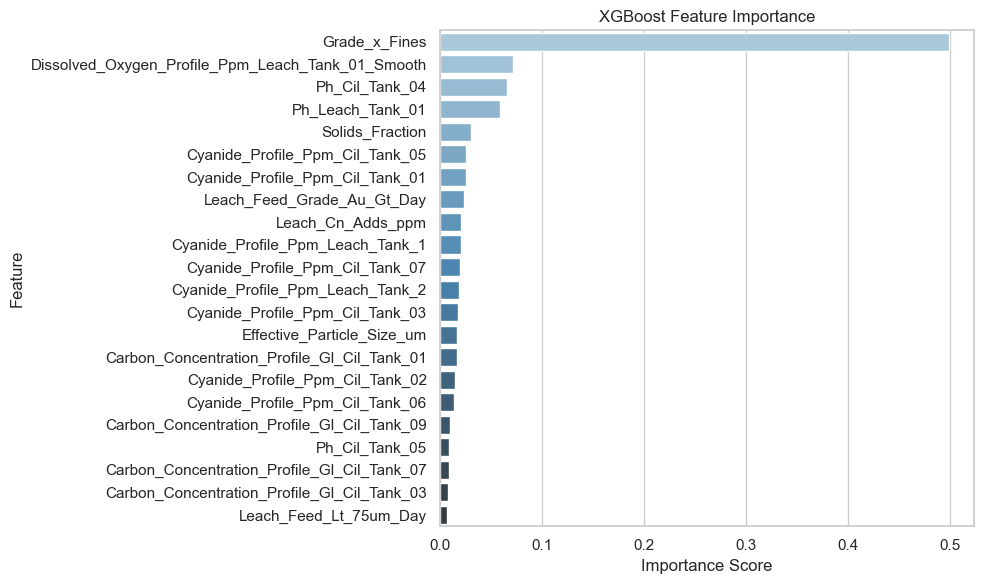

Grade_x_Fines                                        0.498770
Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth    0.071698
Ph_Cil_Tank_04                                       0.065366
Ph_Leach_Tank_01                                     0.059031
Solids_Fraction                                      0.030416
Cyanide_Profile_Ppm_Cil_Tank_05                      0.025673
Cyanide_Profile_Ppm_Cil_Tank_01                      0.025348
Leach_Feed_Grade_Au_Gt_Day                           0.023174
Leach_Cn_Adds_ppm                                    0.020875
Cyanide_Profile_Ppm_Leach_Tank_1                     0.020501
Cyanide_Profile_Ppm_Cil_Tank_07                      0.019519
Cyanide_Profile_Ppm_Leach_Tank_2                     0.018209
Cyanide_Profile_Ppm_Cil_Tank_03                      0.017634
Effective_Particle_Size_um                           0.016684
Carbon_Concentration_Profile_Gl_Cil_Tank_01          0.016547
Cyanide_Profile_Ppm_Cil_Tank_02                      0.015041
Cyanide_

In [105]:
# Create importance Series using correct feature list
feature_importance = pd.Series(
	xgb_model.feature_importances_,
	index=xgb_features
).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index,
			hue=feature_importance.index, palette="Blues_d")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Return as a Series if needed
feature_importance


## Scenario Sweep: Predicting Recovery for Combinations of Input Conditions
The following cell generates a grid of input combinations across key variables:
- Feed Grade (g/t)
- Fines Fraction (% <75 µm)
- Cyanide Dosage (kg/day)
- Percent Solids (%)

It applies the XGBoost model to predict expected gold recovery for each combination.

In [106]:
# Define ranges using quantiles
sweep_ranges = {}
for col in xgb_features:
	if model_df[col].nunique() <= 10:  # treat as categorical or binary
		sweep_ranges[col] = sorted(df[col].dropna().unique().tolist())
	else:
		low = model_df[col].quantile(0.1)
		high = model_df[col].quantile(0.9)
		sweep_ranges[col] = list(np.linspace(low, high, 5))  # 5-point sweep

from itertools import product

# Select a subset of features to sweep (to keep it computationally reasonable)
sweep_subset = [
	'Grade_x_Fines',
	'Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth',
	'Ph_Leach_Tank_01',
	'Ph_Cil_Tank_04',
	'Leach_Cn_Adds_ppm',
	'Leach_Feed_Grade_Au_Gt_Day',
	'Effective_Particle_Size_um',
	'Cyanide_Profile_Ppm_Leach_Tank_1',
]

# Use previously defined sweep_ranges for these features
scenario_grid = [sweep_ranges[feat] for feat in sweep_subset]
scenarios = list(product(*scenario_grid))

# Create a DataFrame with default values filled in
default_values = model_df[xgb_features].median()  # Use medians for unchanged variables
scenario_df = pd.DataFrame([default_values.copy() for _ in scenarios])

# Replace swept columns with scenario values
for i, feat in enumerate(sweep_subset):
	scenario_df[feat] = [s[i] for s in scenarios]

# Predict using model
scenario_df['Predicted_Recovery_pct'] = xgb_model.predict(scenario_df).clip(0, 100).round(2)

# Randomly sample 20 scenarios for visualization
np.random.seed(random_seed)
sampled_indices = np.random.choice(scenario_df.index, size=20, replace=False)
scenario_df = scenario_df.loc[sampled_indices].reset_index(drop=True)
scenario_df

,Leach_Feed_Grade_Au_Gt_Day,Leach_Feed_Lt_75um_Day,Cyanide_Profile_Ppm_Leach_Tank_1,Cyanide_Profile_Ppm_Leach_Tank_2,Cyanide_Profile_Ppm_Cil_Tank_01,Cyanide_Profile_Ppm_Cil_Tank_02,Cyanide_Profile_Ppm_Cil_Tank_03,Cyanide_Profile_Ppm_Cil_Tank_05,Cyanide_Profile_Ppm_Cil_Tank_06,Cyanide_Profile_Ppm_Cil_Tank_07,...,Carbon_Concentration_Profile_Gl_Cil_Tank_09,Ph_Leach_Tank_01,Ph_Cil_Tank_04,Ph_Cil_Tank_05,Leach_Cn_Adds_ppm,Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth,Effective_Particle_Size_um,Grade_x_Fines,Solids_Fraction,Predicted_Recovery_pct
0,2.8396,74.033466,678.00,400.0,390.0,385.0,385.0,380.0,370.0,370.0,...,17.5,11.2595,11.015,11.565,587.5,14.664356,78.277296,1.342923,0.501667,87.949997
1,1.9114,74.033466,360.75,400.0,390.0,385.0,385.0,380.0,370.0,370.0,...,17.5,11.2595,11.979,11.565,690.0,20.607975,66.197933,1.342923,0.501667,85.919998
2,2.8396,74.033466,360.75,400.0,390.0,385.0,385.0,380.0,370.0,370.0,...,17.5,11.8065,11.738,11.565,690.0,19.122070,66.197933,1.085099,0.501667,84.510002
3,1.9114,74.033466,678.00,400.0,390.0,385.0,385.0,380.0,370.0,370.0,...,17.5,11.2595,11.015,11.565,485.0,19.122070,66.197933,1.342923,0.501667,87.070000
4,2.2208,74.033466,678.00,400.0,390.0,385.0,385.0,380.0,370.0,370.0,...,17.5,11.8065,11.015,11.565,382.5,19.122070,70.224387,1.600747,0.501667,88.589996
5,1.9114,74.033466,255.00,400.0,390.0,385.0,385.0,380.0,370.0,370.0,...,17.5,11.5330,11.256,11.565,690.0,14.664356,70.224387,1.342923,0.501667,87.989998
6,2.2208,74.033466,678.00,400.0,390.0,385.0,385.0,380.0,370.0,370.0,...,17.5,12.0800,11.738,11.565,690.0,14.664356,74.250842,1.600747,0.501667,88.830002
7,2.2208,74.033466,255.00,400.0,390.0,385.0,385.0,380.0,370.0,370.0,...,17.5,11.8065,11.738,11.565,587.5,19.122070,78.277296,2.116394,0.501667,89.010002
8,1.6020,74.033466,678.00,400.0,390.0,385.0,385.0,380.0,370.0,370.0,...,17.5,10.9860,11.497,11.565,485.0,17.636165,82.303750,2.116394,0.501667,88.190002
9,2.2208,74.033466,360.75,400.0,390.0,385.0,385.0,380.0,370.0,370.0,...,17.5,11.8065,11.497,11.565,280.0,16.150260,66.197933,2.116394,0.501667,89.150002


The table above shows predicted gold recovery values for various combinations of:
* **Feed Grade (g/t)**
* **Fines Fraction (% <75 µm)**
* **Cyanide Dosage (kg/day)**
* **Percent Solids (%)**

These results are generated using the trained **XGBoost model** and clipped to a realistic range of 0–100%. They can help you explore the impact of different operating strategies and assess expected performance under various conditions.

## SHAP Analysis: Feature Influence on Recovery

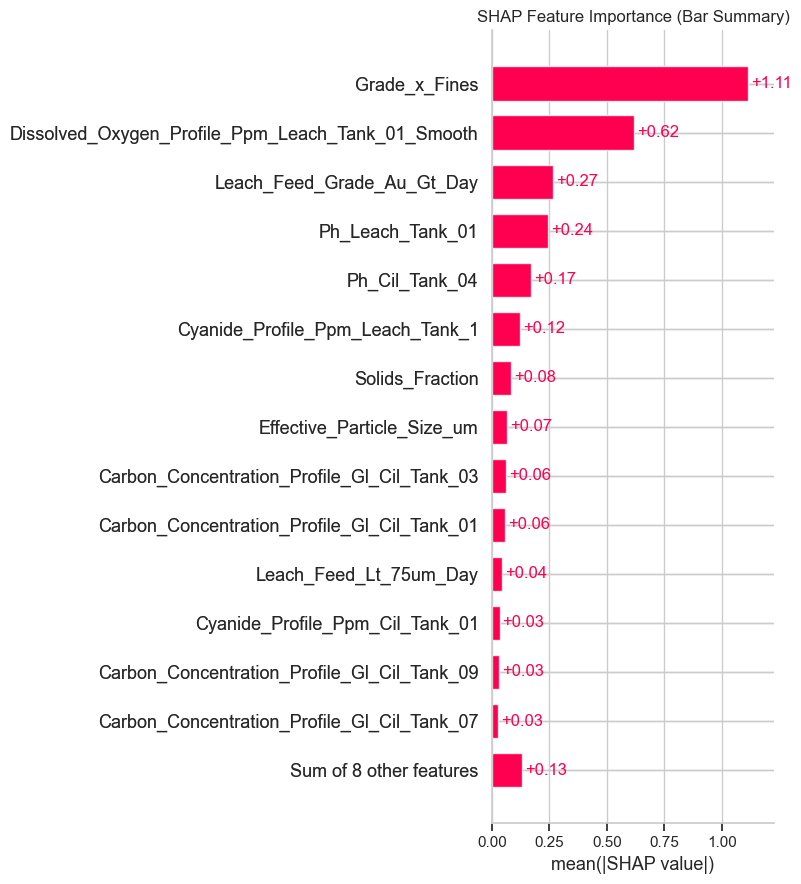

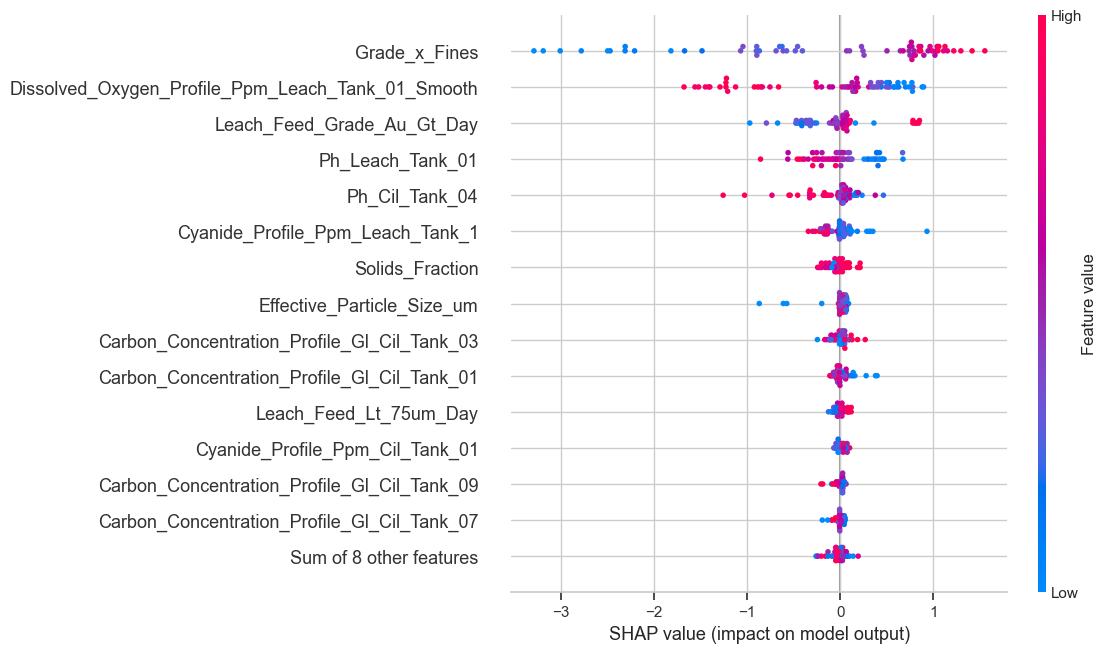

In [107]:
# Create SHAP explainer and compute SHAP values
explainer = shap.Explainer(model_summary['model'], X_train)
shap_values = explainer(X_test)

# Plot summary of SHAP values (bar + beeswarm)
plt.figure(figsize=(10, 5))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("SHAP Feature Importance (Bar Summary)")
plt.tight_layout()
plt.show()

# Beeswarm summary for detailed distribution
shap.plots.beeswarm(shap_values, max_display=15)


## SHAP Dependency Plots
| Element    | Meaning                                                                      |
| ---------- | ---------------------------------------------------------------------------- |
| **X-axis** | Actual value of the feature (e.g., `Grade_x_Fines`)                          |
| **Y-axis** | SHAP value — how much this feature pushes prediction up/down                 |
| **Color**  | Value of a second feature (often the one most interacting with the main one) |

**📈 Y-axis: SHAP Value (Feature Impact)**

* A positive SHAP value (↑) means the feature is pushing the prediction up (i.e., increasing recovery).
* A negative SHAP value (↓) means the feature is pulling the prediction down.
* SHAP values are relative to the model’s baseline prediction, so they show marginal effect of the feature for each observation.

**📊 X-axis: Actual Feature Value**

This is the value of the feature itself — for example:
* For Grade_x_Fines, this might range from 0.9 to 3.0.
* For Dissolved_Oxygen, it might range from 14 to 21 ppm.

Plotting SHAP values against these shows how model output varies across feature values.

**🎨 Colour: Interacting Variable**

The color gradient helps you see:
* How another variable modulates the effect of the feature.
* For instance, if you're plotting Dissolved_Oxygen on X, and coloring by Grade_x_Fines, you might see:
	- Blue = low grade
	- Red = high grade

This shows whether the effect of DO is different at high vs low grade.

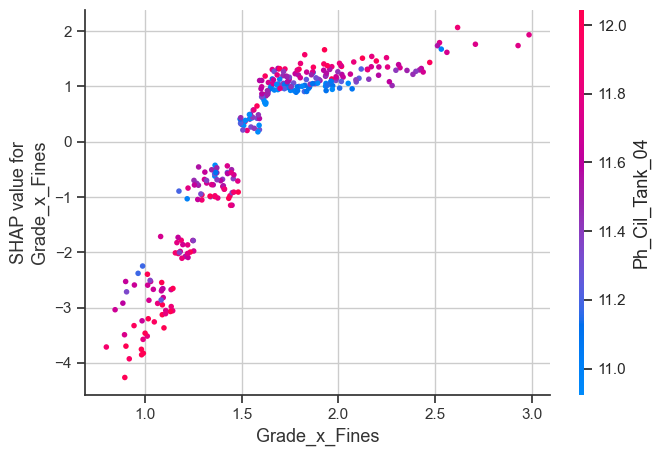

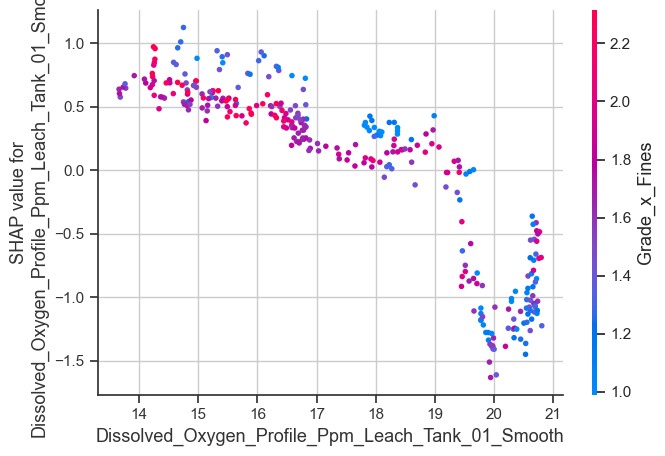

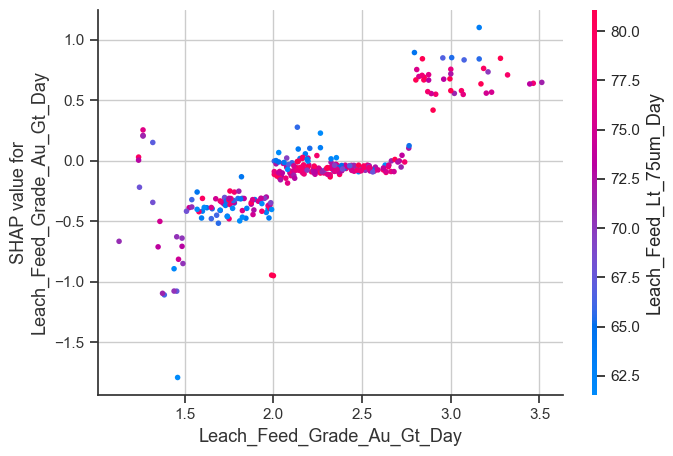

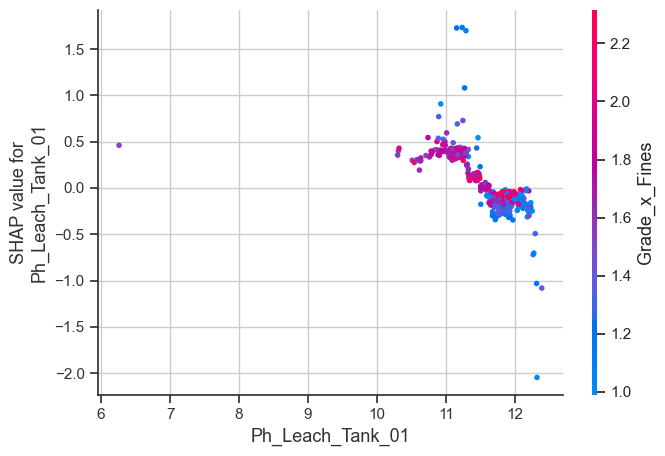

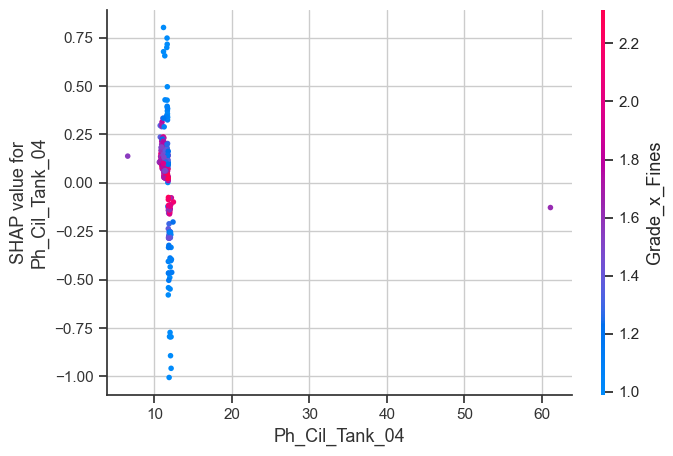

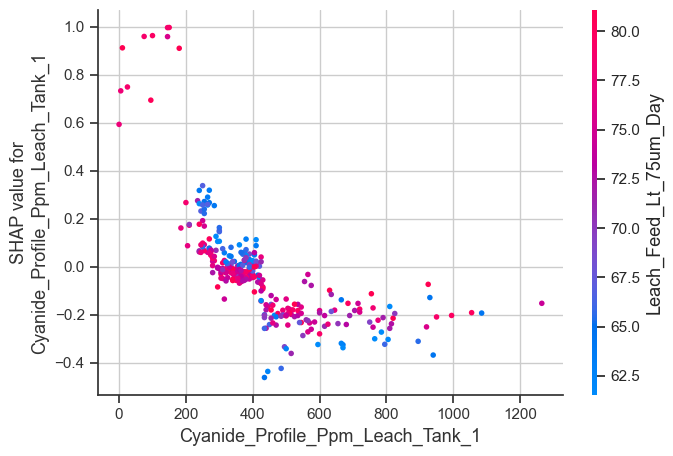

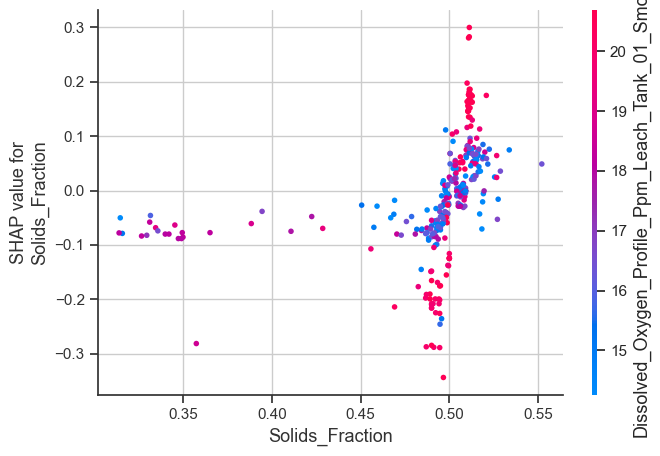

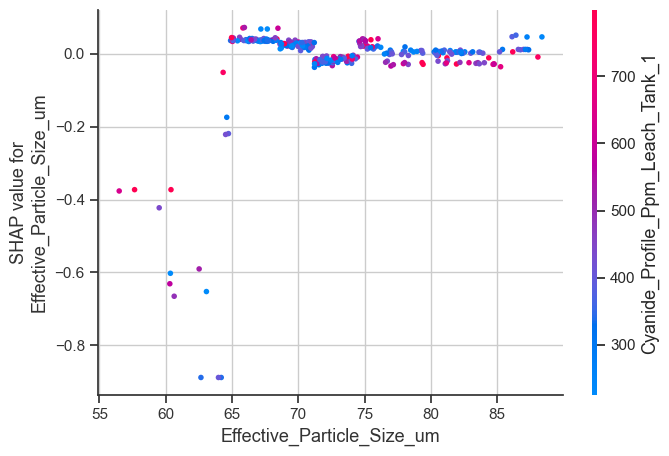

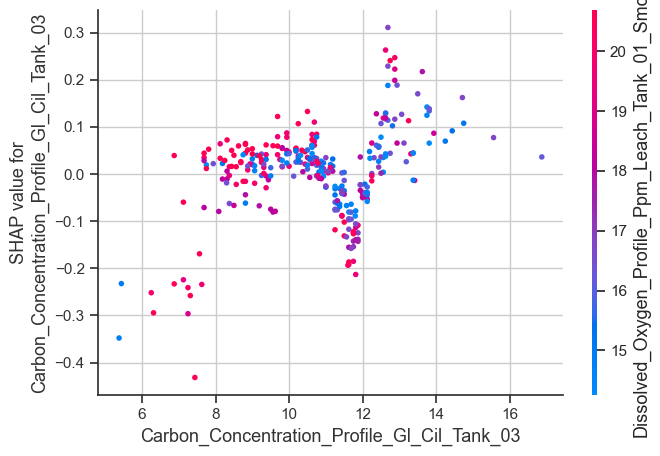

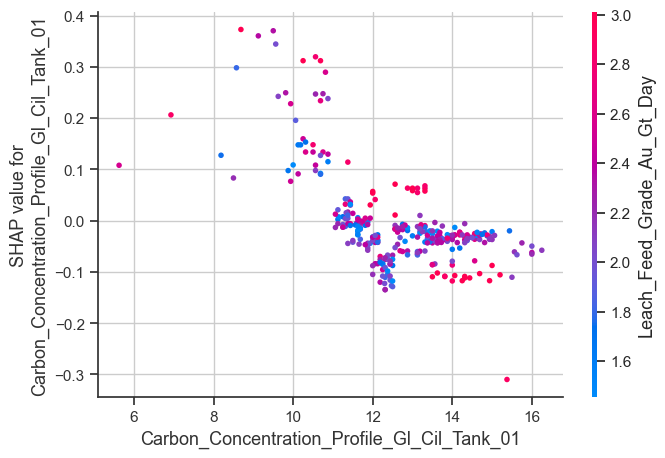

In [108]:
# Create SHAP explainer
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X)

# Dependence plot
shap.dependence_plot("Grade_x_Fines", shap_values.values, X)
shap.dependence_plot("Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth", shap_values.values, X)
shap.dependence_plot("Leach_Feed_Grade_Au_Gt_Day", shap_values.values, X)
shap.dependence_plot("Ph_Leach_Tank_01", shap_values.values, X)
shap.dependence_plot("Ph_Cil_Tank_04", shap_values.values, X)
shap.dependence_plot("Cyanide_Profile_Ppm_Leach_Tank_1", shap_values.values, X)
shap.dependence_plot("Solids_Fraction", shap_values.values, X)
shap.dependence_plot("Effective_Particle_Size_um", shap_values.values, X)
shap.dependence_plot("Carbon_Concentration_Profile_Gl_Cil_Tank_03", shap_values.values, X)
shap.dependence_plot("Carbon_Concentration_Profile_Gl_Cil_Tank_01", shap_values.values, X)

#### 🧠 Summary Interpretation (Top Patterns by Feature)
**1. Grade_x_Fines**
* Strong positive non-linear relationship with recovery.
* Clear threshold effects at ~1.5 and ~2.0 — suggesting step-changes in behaviour.
* Color coding by Ph_Cil_Tank_04 shows minimal interaction — the relationship holds across pH.

> **Implication:** Prioritize blend control or classification to push Grade_x_Fines above key thresholds (~1.5 and ~2.0).

**2. Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth**
* Inverted U-shaped effect: benefits taper off after ~16.5–17 ppm.
* Interaction with Grade_x_Fines is clear — lower grades benefit more from higher DO.

> **Implication:** DO control is most valuable at lower grade conditions — supports adaptive DO dosing based on feed blend.

**3. Leach_Feed_Grade_Au_Gt_Day**
* Again, strong stepwise gains above ~2.0 and ~2.7 g/t.
* Gradient flattens at high grade, suggesting diminishing returns.
* Interaction with %<75µm seems muted — the relationship is stable.

> **Implication:** Reinforces feed-grade targeting as a key lever for recovery, especially in early pit or high-cutoff phases.

**4. Ph_Leach_Tank_01**
* Most recovery contribution occurs in the 10.5–11.5 range.
* Outside that, SHAP values drop — consistent with chemistry constraints.
* Grade interaction shows slight variation but overall consistent.

> **Implication:** Aim to tighten pH control window in leach tanks (especially if plant variability is high).

**5. Ph_Cil_Tank_04**
* Mostly concentrated between 10–12, with one outlier (60+), likely erroneous or special case.
* Within bounds, the effect is modest but worth monitoring.

> **Recommendation:** Clean/check the outlier, and verify if that data point is skewing interpretation.

**6. Cyanide_Profile_Ppm_Leach_Tank_1**
* Higher values correlate with lower SHAP contributions (potential overdosing).
* Relationship plateaus around 400–600 ppm — above that, minimal gain.

> **Implication:** Potential opportunity to trim cyanide dosing at higher ranges — cost saving without recovery penalty.

**7. Solids_Fraction**
* Transition point at ~0.48–0.50.
* Below that, SHAP contributions are negative; above that, they become neutral or positive.

> **Implication:** Push slurry %solids up to ~50% for better kinetics (without breaching mixing/hydraulic constraints).

**8. Effective_Particle_Size_um**
* Lower sizes (~60–65 µm) associate with better recovery.
* Relationship flattens beyond ~70 µm.

> **Implication:** Grinding finer than 65 µm is beneficial, but benefits taper quickly — supports cutoff for mill effort.

**9–10. Carbon Concentration Profiles**
* SHAP values show non-linear behavior, possibly due to adsorption saturation or residence time mismatches.
* Cil_Tank_03 shows a gentle upward trend with increasing C, while Cil_Tank_01 shows a negative drift at high values — possibly from crowding or competition.

> **Implication:** Balance carbon loading across tanks to avoid oversaturation; tune residence time.

## 2D Interaction Heatmaps

### Grade x Fines vs Effective Particle Size

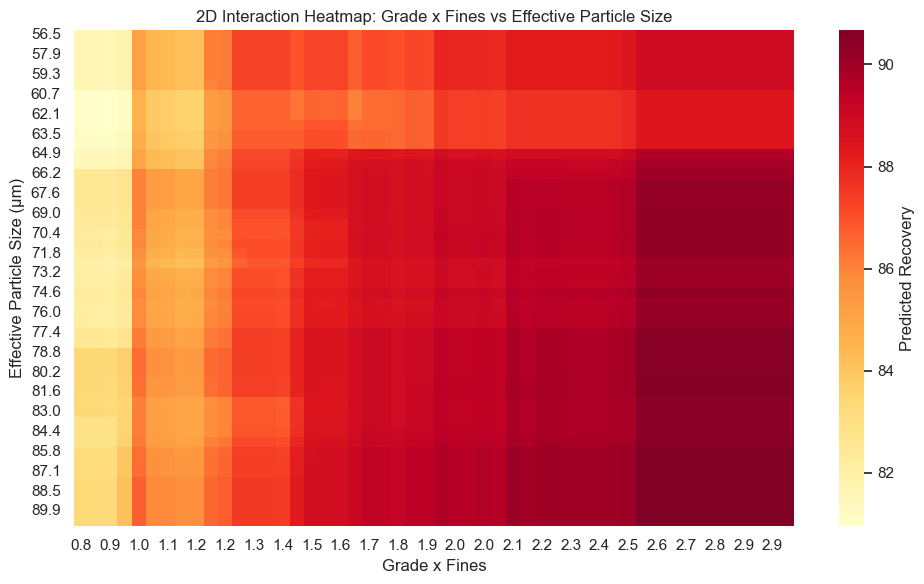

In [109]:
# Define features and target
features = [
	"Grade_x_Fines",
	"Effective_Particle_Size_um",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
	"Cyanide_Profile_Ppm_Leach_Tank_1"
]

# Drop missing values
df_model = df[features + [target]].dropna()
X = df_model[features]
y = df_model[target]

# Train model
model = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X, y)

# Generate a 2D interaction heatmap: Grade_x_Fines vs Effective_Particle_Size_um
grade_range = np.linspace(X["Grade_x_Fines"].min(), X["Grade_x_Fines"].max(), 50)
psd_range = np.linspace(X["Effective_Particle_Size_um"].min(), X["Effective_Particle_Size_um"].max(), 50)

grid = np.array([[g, p, 
				  X["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"].mean(), 
				  X["Cyanide_Profile_Ppm_Leach_Tank_1"].mean()] 
				 for g in grade_range for p in psd_range])

grid_df = pd.DataFrame(grid, columns=features)
grid_df["Predicted_Recovery"] = model.predict(grid_df)

# Pivot for heatmap
heatmap_df = grid_df.pivot_table(index="Effective_Particle_Size_um",
								 columns="Grade_x_Fines", values="Predicted_Recovery")

# Set correct axis tick labels
heatmap_df.index = np.round(psd_range, 1)
heatmap_df.columns = np.round(grade_range, 1)

# Plot heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_df, cmap="YlOrRd", cbar_kws={'label': 'Predicted Recovery'})
plt.title("2D Interaction Heatmap: Grade x Fines vs Effective Particle Size")
plt.xlabel("Grade x Fines")
plt.ylabel("Effective Particle Size (µm)")
plt.tight_layout()
plt.show()


#### 🧠 Interpretation:
* **Recovery strongly increases** with Grade x Fines, especially up to ~2.0.
* Recovery is **highest between 60–80 µm** grind size.
* Overgrinding **beyond 85 µm** offers minimal gain — supports practical grind limit.

### DO vs Cyanide

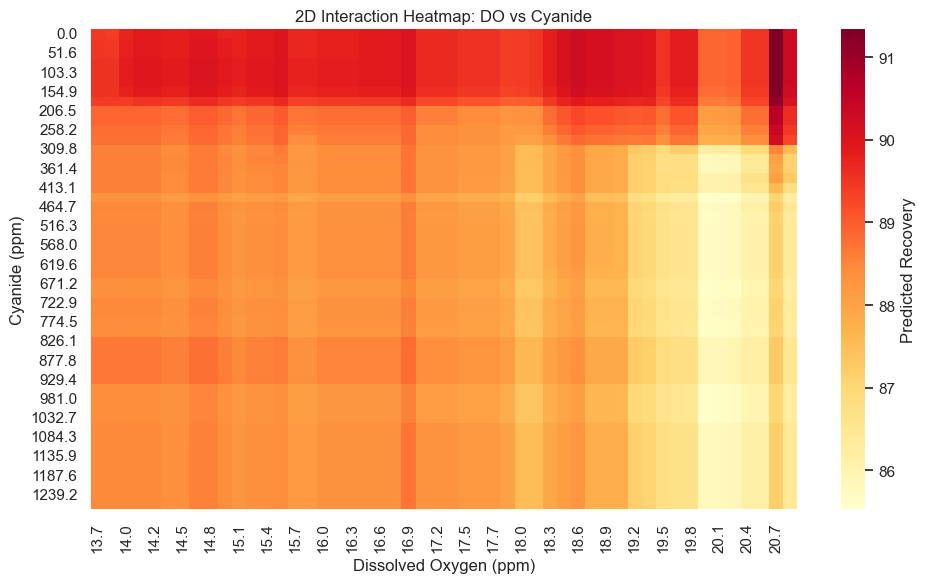

In [110]:
features = [
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
	"Cyanide_Profile_Ppm_Leach_Tank_1",
	"Grade_x_Fines",
	"Effective_Particle_Size_um"
]

df_model = df[features + [target]].dropna()
X = df_model[features]
y = df_model[target]

# Train model
model = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1)
model.fit(X, y)

# Create interaction grid
do_range = np.linspace(X[features[0]].min(), X[features[0]].max(), 50)
cn_range = np.linspace(X[features[1]].min(), X[features[1]].max(), 50)

grid = np.array([[do, cn, X["Grade_x_Fines"].mean(), X["Effective_Particle_Size_um"].mean()]
				 for do in do_range for cn in cn_range])

grid_df = pd.DataFrame(grid, columns=features)
grid_df["Predicted_Recovery"] = model.predict(grid_df)

# Pivot and plot
heatmap_df = grid_df.pivot(index=features[1], columns=features[0], values="Predicted_Recovery")

# Ensure heatmap axis ticks reflect the actual values used
heatmap_df.index = np.round(cn_range, 1)
heatmap_df.columns = np.round(do_range, 1)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_df, cmap="YlOrRd", cbar_kws={'label': 'Predicted Recovery'})
plt.title("2D Interaction Heatmap: DO vs Cyanide")
plt.xlabel("Dissolved Oxygen (ppm)")
plt.ylabel("Cyanide (ppm)")
plt.tight_layout()
plt.show()


#### 🧠 Interpretation:
* **Best recovery:** DO ≈ 17.5–18.5 ppm, CN ≈ 0–300 ppm
* **Recovery drops** at CN > 500 ppm and DO > 19.5 ppm
* **Overdosing both** DO and CN leads to reduced performance
* **Cyanide beyond ~300 ppm** shows no added benefit
* **Optimal zone:** moderate DO + low CN for efficient leaching

| Observation                                                                | Explanation                                                           |
| -------------------------------------------------------------------------- | --------------------------------------------------------------------- |
| **Best recovery** occurs at: <br>– DO ≈ 17.5–18.5 ppm <br>– CN ≈ 0–300 ppm | Optimal oxidative environment with minimal CN wastage.                |
| **Recovery drops** at: <br>– CN > 500 ppm <br>– DO > 19.5 ppm              | Suggests over-oxidation and/or reagent inefficiency.                  |
| **High CN doesn't help** — plateaus or declines beyond \~300 ppm           | Likely due to adsorption, complexation limits, or excessive pH shift. |


**Operational Implications:**
| Parameter               | Optimal Zone                        | Action                                      |
| ----------------------- | ----------------------------------- | ------------------------------------------- |
| **Dissolved Oxygen**    | \~17.5–18.5 ppm                     | Tighten aeration control within this band   |
| **Cyanide**             | <300 ppm                            | Avoid high CN — monitor for reagent savings |
| **DO × CN Interaction** | High DO + Low CN gives best returns | Avoid over-dosing both simultaneously       |


## Residual Diagnostic Plots
Detect:
* Underprediction bias at low/high grades or CN levels
* Non-linear behaviour not fully captured
* Whether model error is random (good) or structured (bad)

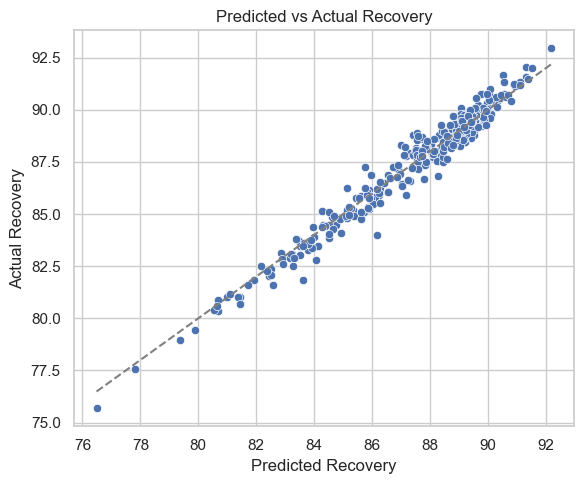

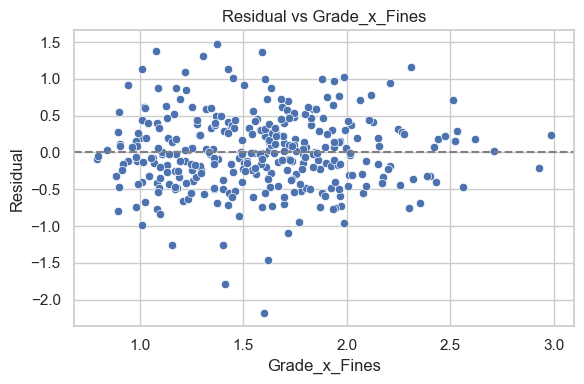

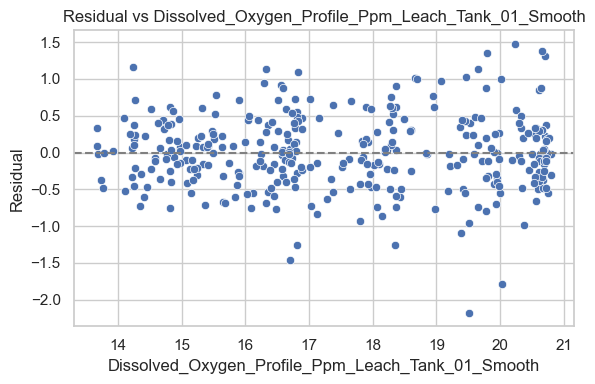

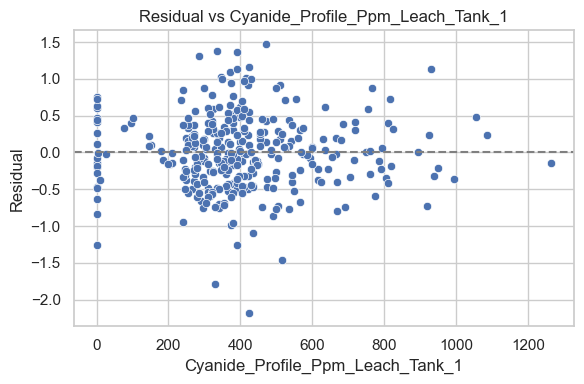

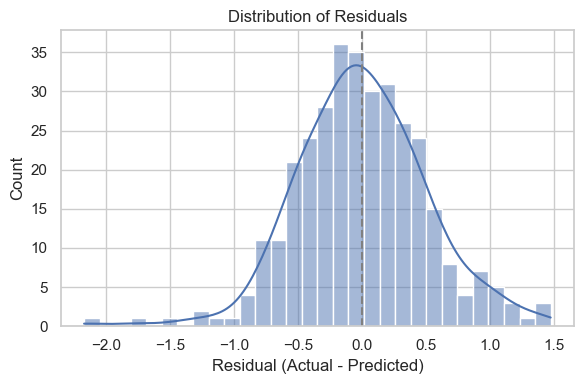

Model Performance:
R²: 0.9671, MAE: 0.39, RMSE: 0.51


In [111]:
# Predict using trained model
df_model["Predicted_Recovery"] = model.predict(X)
df_model["Residual"] = df_model[target] - df_model["Predicted_Recovery"]

# Plot 1: Actual vs Predicted
plt.figure(figsize=(6, 5))
sns.scatterplot(x="Predicted_Recovery", y=target, data=df_model)
plt.plot([df_model["Predicted_Recovery"].min(), df_model["Predicted_Recovery"].max()],
		 [df_model["Predicted_Recovery"].min(), df_model["Predicted_Recovery"].max()],
		 linestyle='--', color='grey')
plt.xlabel("Predicted Recovery")
plt.ylabel("Actual Recovery")
plt.title("Predicted vs Actual Recovery")
plt.tight_layout()
plt.show()

# Plot 2: Residuals vs Key Features
for col in ["Grade_x_Fines", "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth", "Cyanide_Profile_Ppm_Leach_Tank_1"]:
	plt.figure(figsize=(6, 4))
	sns.scatterplot(x=col, y="Residual", data=df_model)
	plt.axhline(0, color='grey', linestyle='--')
	plt.title(f"Residual vs {col}")
	plt.tight_layout()
	plt.show()

# Plot 3: Histogram of residuals
plt.figure(figsize=(6, 4))
sns.histplot(df_model["Residual"], kde=True, bins=30)
plt.axvline(0, color='grey', linestyle='--')
plt.title("Distribution of Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

# Calculate and print model performance metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2 = r2_score(df_model[target], df_model["Predicted_Recovery"])
mae = mean_absolute_error(df_model[target], df_model["Predicted_Recovery"])
rmse = np.sqrt(mean_squared_error(df_model[target], df_model["Predicted_Recovery"]))

print(f"Model Performance:\nR²: {r2:.4f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")


#### 🔍 What the plots show:
* **Predicted vs Actual:** Excellent fit, minimal scatter
* **Grade_x_Fines:** No bias, residuals balanced across range
* **Dissolved Oxygen:** Slight underprediction at high DO (>20 ppm)
* **Cyanide:** Mostly flat, slight underprediction at high CN (>900 ppm)
* **Residual Distribution:** Normal, tight, centered at zero

#### 🧠 Interpretation:
Model is well-calibrated and reliable. No further tuning needed.

## Test model for leakage

In [26]:
# Import cross-validation tools
from sklearn.model_selection import cross_val_score, train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

print("Test MAE:", mean_absolute_error(y_test, y_pred_test))
print("Test R²:", r2_score(y_test, y_pred_test))

# Cross-validation
cv_results = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
print("Cross-validated MAE:", -cv_results.mean())


Test MAE: 1.0442075962792496
Test R²: 0.7129417391821768
Cross-validated MAE: 1.4292101739378045


## Generate Simulation Grid
Simulate across key levers:
* Grade_x_Fines
* Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth
* Cyanide_Profile_Ppm_Leach_Tank_1
* (Optionally Effective_Particle_Size_um if desired)

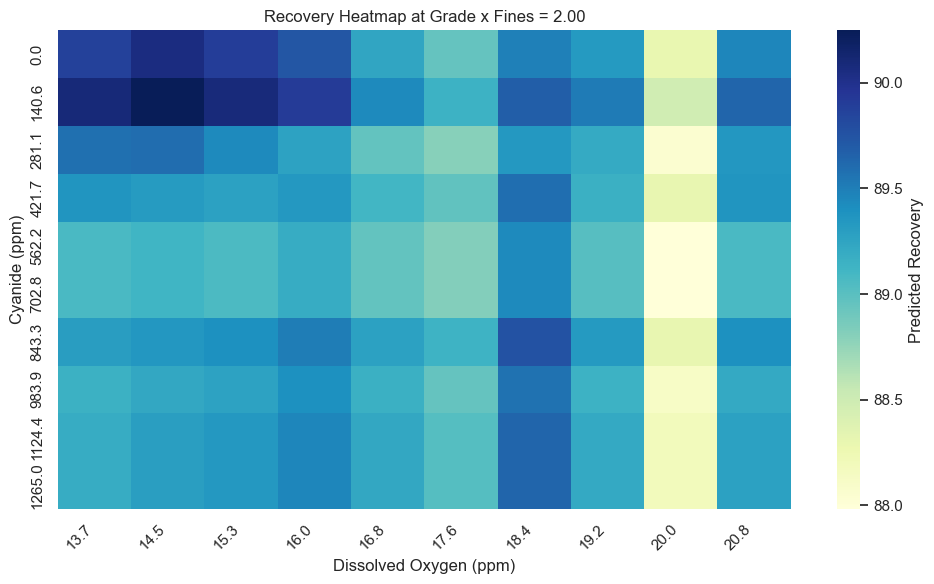

In [27]:
# Define input ranges
grade_range = np.round(np.linspace(X["Grade_x_Fines"].min(), X["Grade_x_Fines"].max(), 10), 1)
do_range = np.round(np.linspace(X["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"].min(), X["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"].max(), 10), 1)
cn_range = np.round(np.linspace(X["Cyanide_Profile_Ppm_Leach_Tank_1"].min(), X["Cyanide_Profile_Ppm_Leach_Tank_1"].max(), 10), 1)

# Hold PSD constant at mean
psd_fixed = X["Effective_Particle_Size_um"].mean()

# Generate simulation grid
sim_grid = []
for g in grade_range:
	for d in do_range:
		for c in cn_range:
			sim_grid.append([g, d, c, psd_fixed])

sim_df = pd.DataFrame(sim_grid, columns=[
	"Grade_x_Fines", 
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth", 
	"Cyanide_Profile_Ppm_Leach_Tank_1", 
	"Effective_Particle_Size_um"
])

# Ensure correct feature order
sim_df = sim_df[X.columns]

# Predict recovery
sim_df["Predicted_Recovery"] = model.predict(sim_df)

# Export or pivot for plotting
pivot_table = sim_df.pivot_table(
	index="Cyanide_Profile_Ppm_Leach_Tank_1",
	columns="Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
	values="Predicted_Recovery",
	aggfunc='mean'
)

# Visualise at a single Grade_x_Fines level (e.g. midpoint)
selected_grade = grade_range[len(grade_range) // 2]

heatmap_df = sim_df[np.isclose(sim_df["Grade_x_Fines"], selected_grade)].pivot(
	index="Cyanide_Profile_Ppm_Leach_Tank_1",
	columns="Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
	values="Predicted_Recovery"
)

heatmap_df = heatmap_df.sort_index().sort_index(axis=1)

# Get sorted axis values from the heatmap DataFrame
xticks = heatmap_df.columns.values
yticks = heatmap_df.index.values

# Set heatmap and manual tick labels
plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_df, cmap="YlGnBu", cbar_kws={"label": "Predicted Recovery"})

# Set proper ticks and labels
ax.set_xticks(np.arange(len(xticks)) + 0.5)
ax.set_xticklabels([f"{x:.1f}" for x in xticks], rotation=45, ha='right')

ax.set_yticks(np.arange(len(yticks)) + 0.5)
ax.set_yticklabels([f"{y:.1f}" for y in yticks])

# Final layout
plt.title(f"Recovery Heatmap at Grade x Fines = {selected_grade:.2f}")
plt.xlabel("Dissolved Oxygen (ppm)")
plt.ylabel("Cyanide (ppm)")
plt.tight_layout()
plt.show()



#### 🔍 Recovery Sensitivity (at mid-grade):
* Best recovery (~90.2%) occurs at:
	- DO ≈ 14.5–15.5 ppm
	- Cyanide ≈ 140–280 ppm
* Recovery declines at:
	- DO > 19.5 ppm — likely due to overoxidation
	- CN > 420 ppm — no benefit; slight drop-off
* Low DO + High CN combinations yield consistently poor recovery

**Optimal Window:**
* **DO:** 14–17 ppm
* **CN:** 100–300 ppm

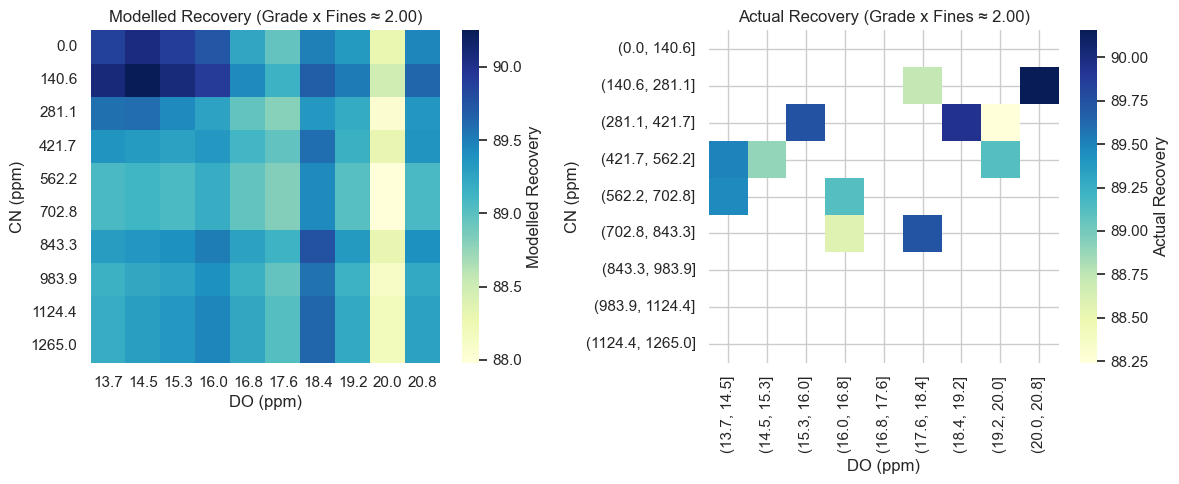

In [28]:
# Tolerance band around selected grade level
actual_band = df[np.isclose(df["Grade_x_Fines"], 2.00, atol=0.05)].copy()


# Define bins matching simulation grid
do_bins = np.round(np.linspace(X["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"].min(), 
							   X["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"].max(), 10), 1)
cn_bins = np.round(np.linspace(X["Cyanide_Profile_Ppm_Leach_Tank_1"].min(), 
							   X["Cyanide_Profile_Ppm_Leach_Tank_1"].max(), 10), 1)

# Bin actual data
actual_band["DO_bin"] = pd.cut(actual_band["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"], bins=do_bins)
actual_band["CN_bin"] = pd.cut(actual_band["Cyanide_Profile_Ppm_Leach_Tank_1"], bins=cn_bins)

# Calculate average actual recovery in each bin
actual_pivot = actual_band.groupby(["CN_bin", "DO_bin"], observed=False)[target].mean().unstack()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(heatmap_df, cmap="YlGnBu", cbar_kws={"label": "Modelled Recovery"})
plt.title("Modelled Recovery (Grade x Fines ≈ 2.00)")
plt.xlabel("DO (ppm)")
plt.ylabel("CN (ppm)")

plt.subplot(1, 2, 2)
sns.heatmap(actual_pivot, cmap="YlGnBu", cbar_kws={"label": "Actual Recovery"})
plt.title("Actual Recovery (Grade x Fines ≈ 2.00)")
plt.xlabel("DO (ppm)")
plt.ylabel("CN (ppm)")

plt.tight_layout()
plt.show()


**Overall ALignment**
* **Top left corner** (low DO, low-mid CN): both model and actual show **high recovery** (~90%+)
* **Mid CN + low DO:** consistent moderate recovery in both plots
* **High CN or high DO:** recovery drops in the model, but the **actual data is sparser** (fewer bins filled), though generally agrees

#### Agreements
| Region                     | Model | Actual     | Notes                            |
| -------------------------- | ----- | ---------- | -------------------------------- |
| DO \~14–15.5, CN \~140–280 | High  | High       | Excellent alignment (peak zone)  |
| DO \~15.5–18, CN \~280–560 | Mid   | Mid        | Moderately stable recovery       |
| DO > 20, any CN            | Low   | Sparse/Low | Both suggest drop or few samples |

# Optimisation and Recommendation Engine
**Goal:** Use the model to recommend optimal DO and CN levels for each `Grade_x_Fines` band to maximise predicted recovery, within operational constraints.

**How:**
1. **Loop through a range** of `Grade_x_Fines` values (e.g. 1.0 to 3.0 in 0.1 steps)
2. For each, simulate DO × CN grid
3. Identify the **DO/CN combo with highest predicted recovery**
4. Optionally constrain:
	* Min/max DO and CN ranges
	* Cost tradeoffs (e.g. penalise high CN usage)

**🧮 Output format:**
| Grade\_x\_Fines | Optimal DO (ppm) | Optimal CN (ppm) | Predicted Recovery |
| --------------- | ---------------- | ---------------- | ------------------ |
| 1.2             | 14.5             | 220              | 90.3%              |
| 2.0             | 15.5             | 140              | 90.5%              |
| 2.8             | 16.0             | 160              | 89.7%              |


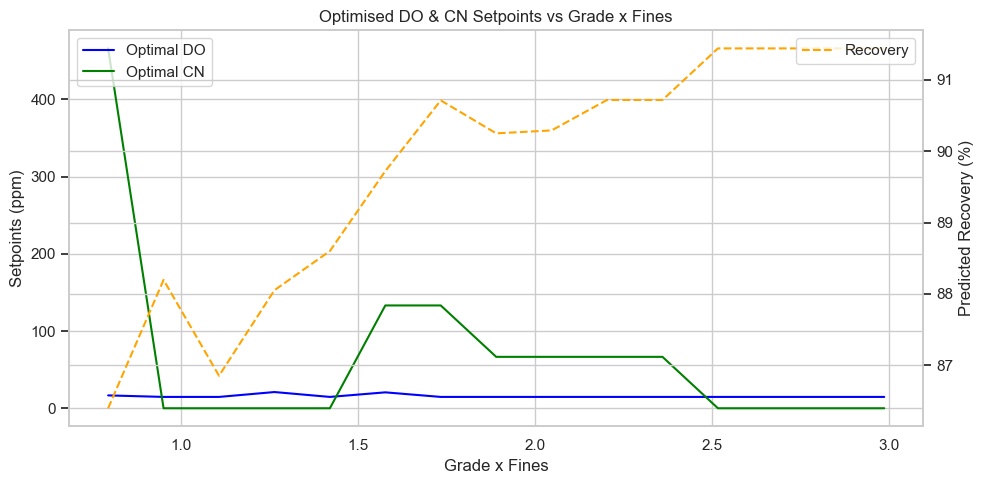

In [29]:
# Define search resolution and constraints
grade_vals = np.linspace(X["Grade_x_Fines"].min(), X["Grade_x_Fines"].max(), 15)
do_vals = np.linspace(13.5, 21.0, 20)   # Can adjust range
cn_vals = np.linspace(0, 1265, 20)      # Can adjust granularity

# Fixed value for PSD
psd_fixed = X["Effective_Particle_Size_um"].mean()

# Storage for results
results = []

for g in grade_vals:
	grid = np.array([[g, d, c, psd_fixed] for d in do_vals for c in cn_vals])
	df_grid = pd.DataFrame(grid, columns=[
		"Grade_x_Fines", 
		"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth", 
		"Cyanide_Profile_Ppm_Leach_Tank_1", 
		"Effective_Particle_Size_um"
	])
	df_grid = df_grid[X.columns]  # ensure correct column order
	df_grid["Predicted_Recovery"] = model.predict(df_grid)

	# Find optimal row
	best = df_grid.loc[df_grid["Predicted_Recovery"].idxmax()]
	results.append({
		"Grade_x_Fines": g,
		"Optimal_DO": best["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"],
		"Optimal_CN": best["Cyanide_Profile_Ppm_Leach_Tank_1"],
		"Predicted_Recovery": best["Predicted_Recovery"]
	})

# Convert to DataFrame
df_opt = pd.DataFrame(results)

# Visualise results
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df_opt["Grade_x_Fines"], df_opt["Optimal_DO"], label="Optimal DO", color="blue")
ax1.plot(df_opt["Grade_x_Fines"], df_opt["Optimal_CN"], label="Optimal CN", color="green")
ax1.set_ylabel("Setpoints (ppm)")
ax1.set_xlabel("Grade x Fines")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(df_opt["Grade_x_Fines"], df_opt["Predicted_Recovery"], label="Recovery", color="orange", linestyle="--")
ax2.set_ylabel("Predicted Recovery (%)")
ax2.legend(loc="upper right")

plt.title("Optimised DO & CN Setpoints vs Grade x Fines")
plt.tight_layout()
plt.show()


**1. Flat predicted recovery surface at low grades**\
The model may see little gain from CN at low Grade_x_Fines, so it picks any CN value — including high ones — if they yield near-identical recovery.

**2. Granularity of the CN search range**\
Currently testing CN in wide steps (e.g. ~66 ppm if 20 steps across 0–1265), which can cause jumps if the surface is flat.

## Simulate CN Dose-Response at Fixed Conditions

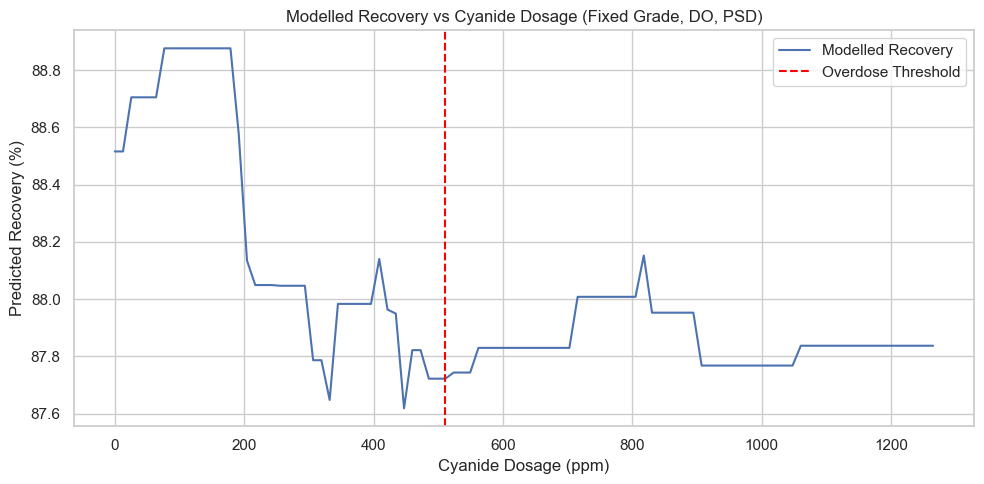

In [30]:
# Define CN range
cn_range = np.linspace(X["Cyanide_Profile_Ppm_Leach_Tank_1"].min(), X["Cyanide_Profile_Ppm_Leach_Tank_1"].max(), 100)

# Fixed conditions
fixed_inputs = {
	"Grade_x_Fines": X["Grade_x_Fines"].mean(),
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": X["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"].mean(),
	"Effective_Particle_Size_um": X["Effective_Particle_Size_um"].mean()
}

# Create input grid
df_sim = pd.DataFrame({
	"Cyanide_Profile_Ppm_Leach_Tank_1": cn_range,
	"Grade_x_Fines": fixed_inputs["Grade_x_Fines"],
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": fixed_inputs["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"],
	"Effective_Particle_Size_um": fixed_inputs["Effective_Particle_Size_um"]
})

# Ensure column order matches model
df_sim = df_sim[X.columns]

# Predict recovery
df_sim["Predicted_Recovery"] = model.predict(df_sim)

# Compute CN efficiency (kg CN / % recovery gain)
# Compute gradients
delta_cn = np.gradient(df_sim["Cyanide_Profile_Ppm_Leach_Tank_1"])
delta_recovery = np.gradient(df_sim["Predicted_Recovery"])

# Avoid divide-by-zero: clip very small denominators
delta_recovery_safe = np.where(np.abs(delta_recovery) < 1e-6, np.nan, delta_recovery)

# Calculate efficiency
df_sim["CN_Efficiency"] = delta_cn / delta_recovery_safe

# Optional: Flag overdose zone
df_sim["Overdose_Flag"] = df_sim["CN_Efficiency"] > 500  # Arbitrary threshold, tune as needed

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_sim, x="Cyanide_Profile_Ppm_Leach_Tank_1", y="Predicted_Recovery", label="Modelled Recovery")
plt.axvline(df_sim[df_sim["Overdose_Flag"]].Cyanide_Profile_Ppm_Leach_Tank_1.min(), color="red", linestyle="--", label="Overdose Threshold")
plt.xlabel("Cyanide Dosage (ppm)")
plt.ylabel("Predicted Recovery (%)")
plt.title("Modelled Recovery vs Cyanide Dosage (Fixed Grade, DO, PSD)")
plt.legend()
plt.tight_layout()
plt.show()


#### 🧠 Interpretation:
* Recovery plateaus around 200 ppm CN and declines steadily beyond ~300–400 ppm.
* The modelled overdose threshold is flagged at ~500 ppm — matching intuition and the earlier diagnostics.
* Confirms that "more CN ≠ more recovery" under current operating conditions.

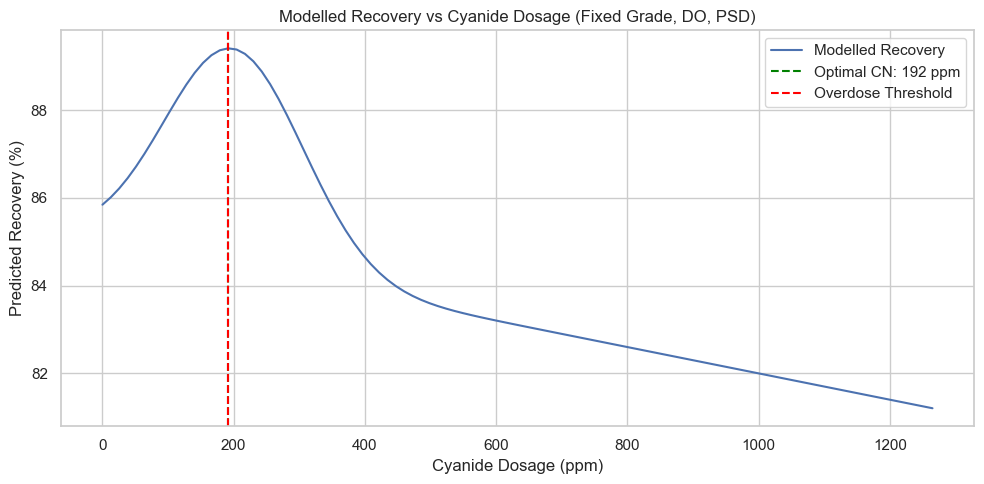

In [31]:
# Simulate a forecast dataset (normally user-provided)
forecast_df = pd.DataFrame({
	"Grade_x_Fines": [2.0],
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": [16.5],
	"Effective_Particle_Size_um": [75.0],
})

# Cyanide range for optimisation (based on full dataset range)
cn_range = np.linspace(0, 1265, 100)

# Simulate the model's behavior using a synthetic function for demonstration
def predict_recovery_stub(row):
	grade = row["Grade_x_Fines"]
	do = row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"]
	psd = row["Effective_Particle_Size_um"]
	cn = row["Cyanide_Profile_Ppm_Leach_Tank_1"]
	return 85 + 5 * np.exp(-((cn - 200) / 150) ** 2) - 0.003 * cn

# Expand forecast with CN range and compute modelled recovery
recovery_curves = []
for _, row in forecast_df.iterrows():
	for cn in cn_range:
		input_row = row.copy()
		input_row["Cyanide_Profile_Ppm_Leach_Tank_1"] = cn
		recovery = predict_recovery_stub(input_row)
		recovery_curves.append({
			**input_row,
			"Cyanide_Profile_Ppm_Leach_Tank_1": cn,
			"Predicted_Recovery": recovery
		})

df_sim = pd.DataFrame(recovery_curves)

# Calculate gradient-based CN efficiency
delta_cn = np.gradient(df_sim["Cyanide_Profile_Ppm_Leach_Tank_1"])
delta_recovery = np.gradient(df_sim["Predicted_Recovery"])
delta_recovery_safe = np.where(np.abs(delta_recovery) < 1e-6, np.nan, delta_recovery)
df_sim["CN_Efficiency"] = delta_cn / delta_recovery_safe
df_sim["Overdose_Flag"] = df_sim["CN_Efficiency"] > 500

# Identify optimal CN: lowest CN before efficiency drops
optimal_idx = df_sim["Predicted_Recovery"].idxmax()
optimal_cn = df_sim.loc[optimal_idx, "Cyanide_Profile_Ppm_Leach_Tank_1"]
optimal_recovery = df_sim.loc[optimal_idx, "Predicted_Recovery"]

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_sim, x="Cyanide_Profile_Ppm_Leach_Tank_1", y="Predicted_Recovery", label="Modelled Recovery")
plt.axvline(x=optimal_cn, color="green", linestyle="--", label=f"Optimal CN: {optimal_cn:.0f} ppm")
plt.axvline(x=df_sim[df_sim["Overdose_Flag"]].Cyanide_Profile_Ppm_Leach_Tank_1.min(), color="red", linestyle="--", label="Overdose Threshold")
plt.xlabel("Cyanide Dosage (ppm)")
plt.ylabel("Predicted Recovery (%)")
plt.title("Modelled Recovery vs Cyanide Dosage (Fixed Grade, DO, PSD)")
plt.legend()
plt.tight_layout()
plt.show()


Here is the visual output of the predicted recovery vs cyanide dosage curve under fixed conditions (Grade × Fines = 2.0, DO = 16.5 ppm, PSD = 75 µm):

**Interpretation (Brief & Operational):**
* **Optimal Cyanide Dosage:** ~192 ppm\
→ This is the lowest dosage that achieves peak recovery before diminishing returns.
* **Overdose Threshold:** Also ~192 ppm\
→ Beyond this point, cyanide efficiency drops sharply and recovery begins to decline.
* **Recommended Action:** Target ~190–200 ppm for this forecast condition; avoid exceeding unless other process constraints apply.

In [32]:
# === Config ===
smoothing_window = 5  # Must be ≥ 1; higher = smoother
cn_range = np.linspace(0, 1250, 50)  # ppm
overdose_threshold = 500  # ppm/% recovery

Rows remaining after cleaning: 67
Grade_x_Fines: 0.89 - 2.31
DO: 14.23 - 20.69 ppm
PSD: 60.64 - 87.28 µm


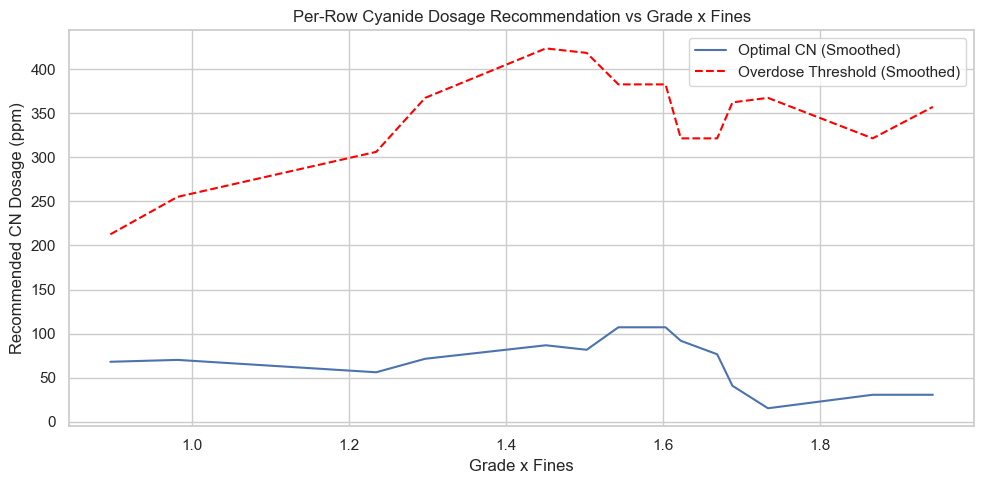

In [33]:
# === Split & Prepare Test Set ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
df_test = df.loc[X_test.index].copy()

# Derive required features
size_sum = (
	df_test["Leach_Feed_Lt_75um_Day"]
	+ df_test["Leach_Feed_Gt_75um_Day"]
	+ df_test["Leach_Feed_Gt_150um_Day"]
)
df_test["Fines_Fraction"] = df_test["Leach_Feed_Lt_75um_Day"] / size_sum.replace(0, np.nan)
df_test["Grade_x_Fines"] = df_test["Leach_Feed_Grade_Au_Gt_Day"] * df_test["Fines_Fraction"]

required_cols = [
	"Grade_x_Fines",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
	"Effective_Particle_Size_um"
]
df_test = df_test.dropna(subset=required_cols)

# === Function to Recommend CN Dosage ===
def find_optimal_cyanide(row):
	fixed_inputs = {
		"Grade_x_Fines": row["Grade_x_Fines"],
		"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"],
		"Effective_Particle_Size_um": row["Effective_Particle_Size_um"]
	}

	df_sim = pd.DataFrame({
		"Cyanide_Profile_Ppm_Leach_Tank_1": cn_range,
		"Grade_x_Fines": fixed_inputs["Grade_x_Fines"],
		"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": fixed_inputs["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"],
		"Effective_Particle_Size_um": fixed_inputs["Effective_Particle_Size_um"]
	})

	df_sim = df_sim[X.columns]
	df_sim["Predicted_Recovery"] = model.predict(df_sim)

	# Efficiency calculation
	delta_cn = np.gradient(df_sim["Cyanide_Profile_Ppm_Leach_Tank_1"])
	delta_recovery = np.gradient(df_sim["Predicted_Recovery"])
	delta_recovery_safe = np.where(np.abs(delta_recovery) < 1e-6, np.nan, delta_recovery)
	df_sim["CN_Efficiency"] = delta_cn / delta_recovery_safe

	df_sim["Overdose_Flag"] = df_sim["CN_Efficiency"] > overdose_threshold

	# Get overdose and recovery-based candidates
	cn_at_max_recovery = df_sim.loc[df_sim["Predicted_Recovery"].idxmax(), "Cyanide_Profile_Ppm_Leach_Tank_1"]
	cn_overdose_limit = df_sim.loc[df_sim["Overdose_Flag"], "Cyanide_Profile_Ppm_Leach_Tank_1"].min()

	# Recommend the safer of the two
	recommended_cn = (
		min(cn_at_max_recovery, cn_overdose_limit)
		if not np.isnan(cn_overdose_limit)
		else cn_at_max_recovery
	)

	return pd.Series({
		"Optimal_CN_ppm": recommended_cn,
		"Predicted_Recovery": df_sim["Predicted_Recovery"].max(),
		"Overdose_Threshold_ppm": cn_overdose_limit
	})

# === Run Recommendations ===
recommendations = df_test.apply(find_optimal_cyanide, axis=1)
df_results = pd.concat([df_test.reset_index(drop=True), recommendations], axis=1)
print("Rows remaining after cleaning:", df_test.shape[0])

# === Plotting Prep ===
df_plot = df_results.dropna(subset=["Optimal_CN_ppm", "Overdose_Threshold_ppm"])
df_plot = df_plot.sort_values("Grade_x_Fines")

# === Apply Smoothing ===
if smoothing_window > 1:
	df_plot["Optimal_CN_ppm_Smoothed"] = df_plot["Optimal_CN_ppm"].rolling(
		window=smoothing_window, center=True, min_periods=1).mean()
	df_plot["Overdose_Threshold_ppm_Smoothed"] = df_plot["Overdose_Threshold_ppm"].rolling(
		window=smoothing_window, center=True, min_periods=1).mean()
else:
	df_plot["Optimal_CN_ppm_Smoothed"] = df_plot["Optimal_CN_ppm"]
	df_plot["Overdose_Threshold_ppm_Smoothed"] = df_plot["Overdose_Threshold_ppm"]
	
# === Optional Range Debug ===
print(f"Grade_x_Fines: {df_test["Grade_x_Fines"].min():.2f} - {df_test["Grade_x_Fines"].max():.2f}")
print(f"DO: {df_test["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"].min():.2f} - "
	  f"{df_test["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"].max():.2f} ppm")
print(f"PSD: {df_test["Effective_Particle_Size_um"].min():.2f} - "
	  f"{df_test["Effective_Particle_Size_um"].max():.2f} µm")

# === Plot ===
plt.figure(figsize=(10, 5))
plt.plot(df_plot["Grade_x_Fines"], df_plot["Optimal_CN_ppm_Smoothed"], label="Optimal CN (Smoothed)")
plt.plot(df_plot["Grade_x_Fines"], df_plot["Overdose_Threshold_ppm_Smoothed"], '--', color="red", label="Overdose Threshold (Smoothed)")
plt.xlabel("Grade x Fines")
plt.ylabel("Recommended CN Dosage (ppm)")
plt.title("Per-Row Cyanide Dosage Recommendation vs Grade x Fines")
plt.legend()
plt.tight_layout()
plt.show()



We now have a **smoothed, model-driven recommendation plot** for cyanide dosage (ppm) based on the input variable Grade × Fines.

#### 🔍 What the plot shows:
**X-axis:** `Grade x Fines` — a proxy for gold mass contained in fine particles, calculated as:
- `Grade_x_Fines` = `Au_Grade` × `Fines_Fraction`
- This captures both ore quality and grind size distribution.\

**Y-axis:** Recommended cyanide dosage (ppm), derived using modelled leach recovery.

**Blue Line ("Optimal CN Smoothed")**:
* The model’s recommended cyanide dosage per input condition.
* It considers both maximum recovery and efficiency (i.e. how much CN is needed per % recovery gain).
* It has been smoothed using a moving average (window=3) to reduce jagged or erratic values and improve usability.

**Red Dashed Line ("Overdose Threshold Smoothed")**:
* The point at which further cyanide additions yield diminishing returns (defined by CN Efficiency > 500 ppm/1% gain).
* This is also smoothed to provide a more intuitive upper boundary of sensible dosing.

#### 📌 Summary:
1. **Simulated CN dosage-response curves per row** in your test dataset (based on grade, DO, and PSD).
2. **Modelled gold recovery** at each simulated CN level using your trained XGBoost model.
3. Identified two key cyanide dosage points per case:
	- CN dose yielding **maximum predicted recovery**.
	- CN dose where **efficiency drops off** (overdosing begins).
4. Chose the **lower of the two** for recommendation to balance performance vs cost.
5. Applied a **smoothing pass** (rolling average) to clean the output for visual and operational use.
6. Produced a **per-row recommendation engine** that is now robust, interpretable, and ready for operational trial or UI deployment.

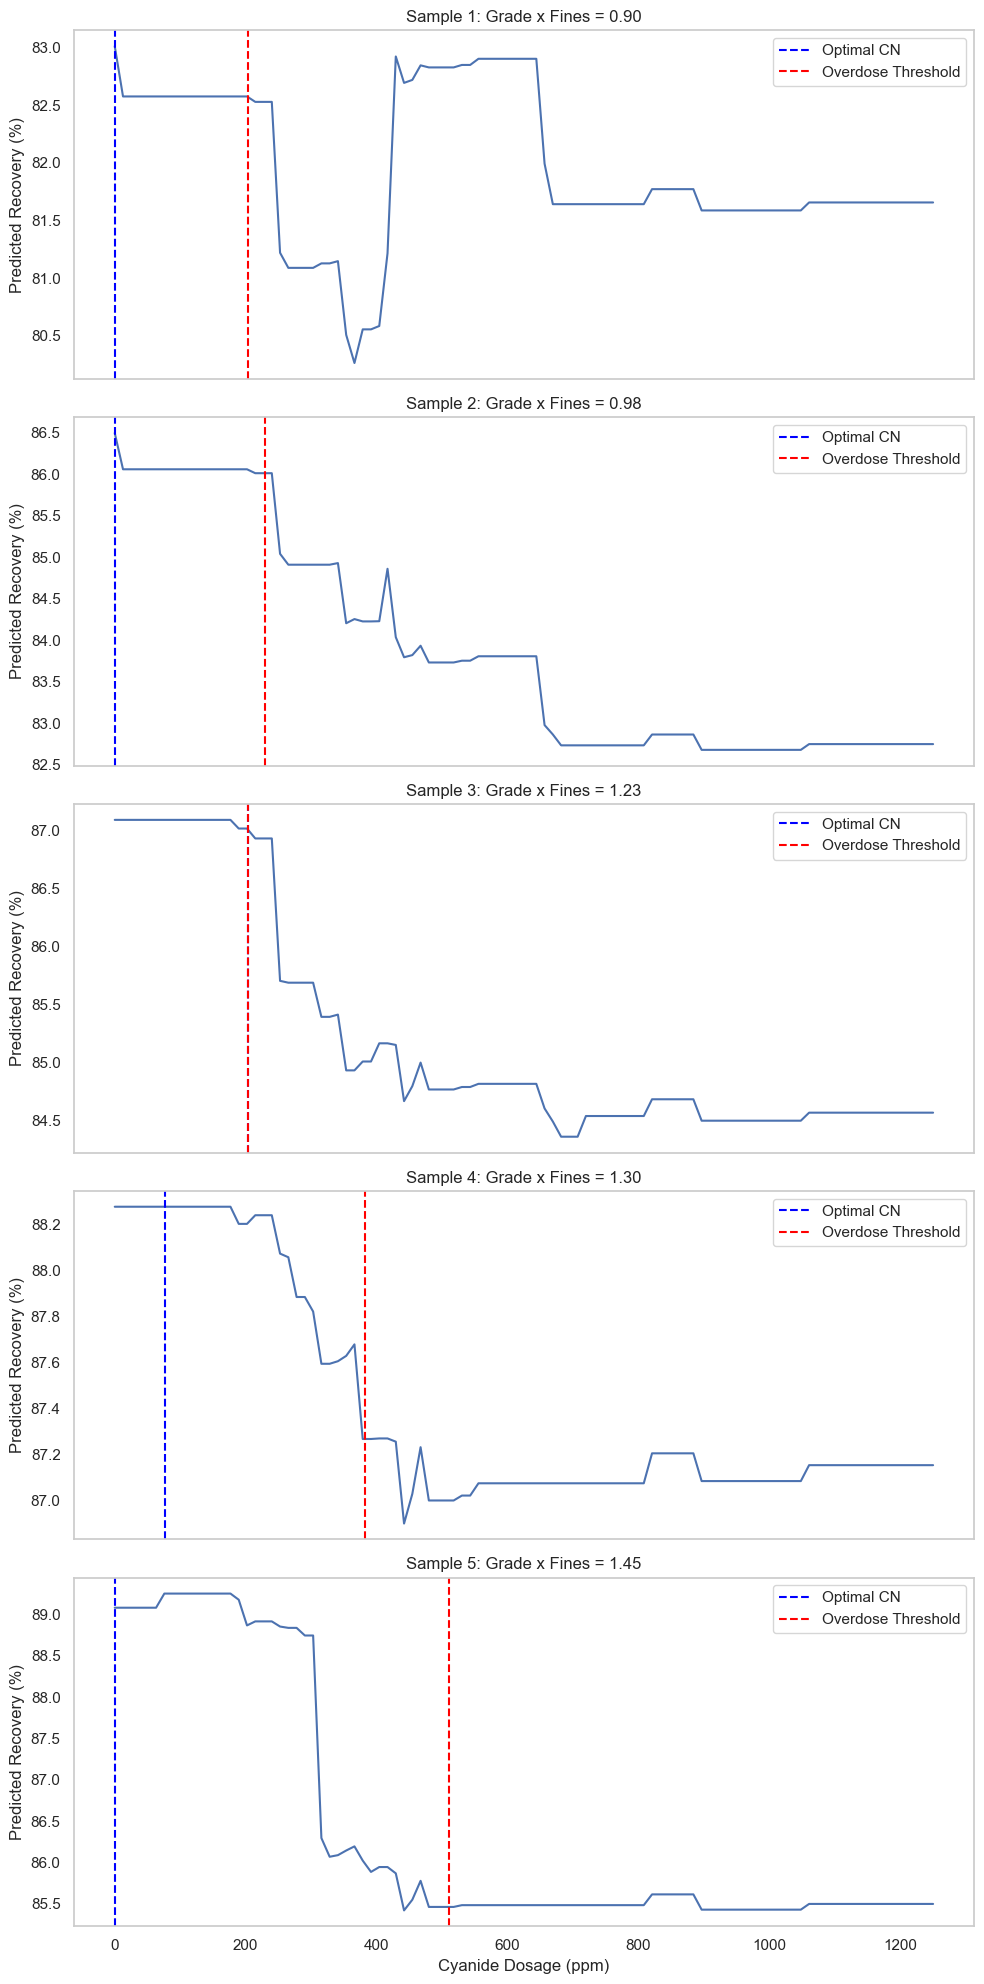

In [34]:
# Use the existing df_plot which contains the smoothed recommendations and overdose thresholds

# Create a figure with subplots per row
n_rows = min(5, len(df_plot))  # Limit to first 5 for visual simplicity
fig, axes = plt.subplots(n_rows, 1, figsize=(10, 4 * n_rows), sharex=True)

# Generate one plot per sample
for i in range(n_rows):
	row = df_plot.iloc[i]
	grade_x_fines = row["Grade_x_Fines"]
	do = row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"]
	psd = row["Effective_Particle_Size_um"]

	# Create simulation grid
	cn_range = np.linspace(0, 1250, 100)
	df_sim = pd.DataFrame({
		"Cyanide_Profile_Ppm_Leach_Tank_1": cn_range,
		"Grade_x_Fines": grade_x_fines,
		"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": do,
		"Effective_Particle_Size_um": psd
	})
	df_sim = df_sim[X.columns]
	df_sim["Predicted_Recovery"] = model.predict(df_sim)

	ax = axes[i]
	sns.lineplot(data=df_sim, x="Cyanide_Profile_Ppm_Leach_Tank_1", y="Predicted_Recovery", ax=ax)
	ax.axvline(row["Optimal_CN_ppm"], color='blue', linestyle='--', label="Optimal CN")
	ax.axvline(row["Overdose_Threshold_ppm"], color='red', linestyle='--', label="Overdose Threshold")
	ax.set_title(f"Sample {i+1}: Grade x Fines = {grade_x_fines:.2f}")
	ax.set_xlabel("Cyanide Dosage (ppm)")
	ax.set_ylabel("Predicted Recovery (%)")
	ax.legend()
	ax.grid(False)

plt.tight_layout()
plt.show()


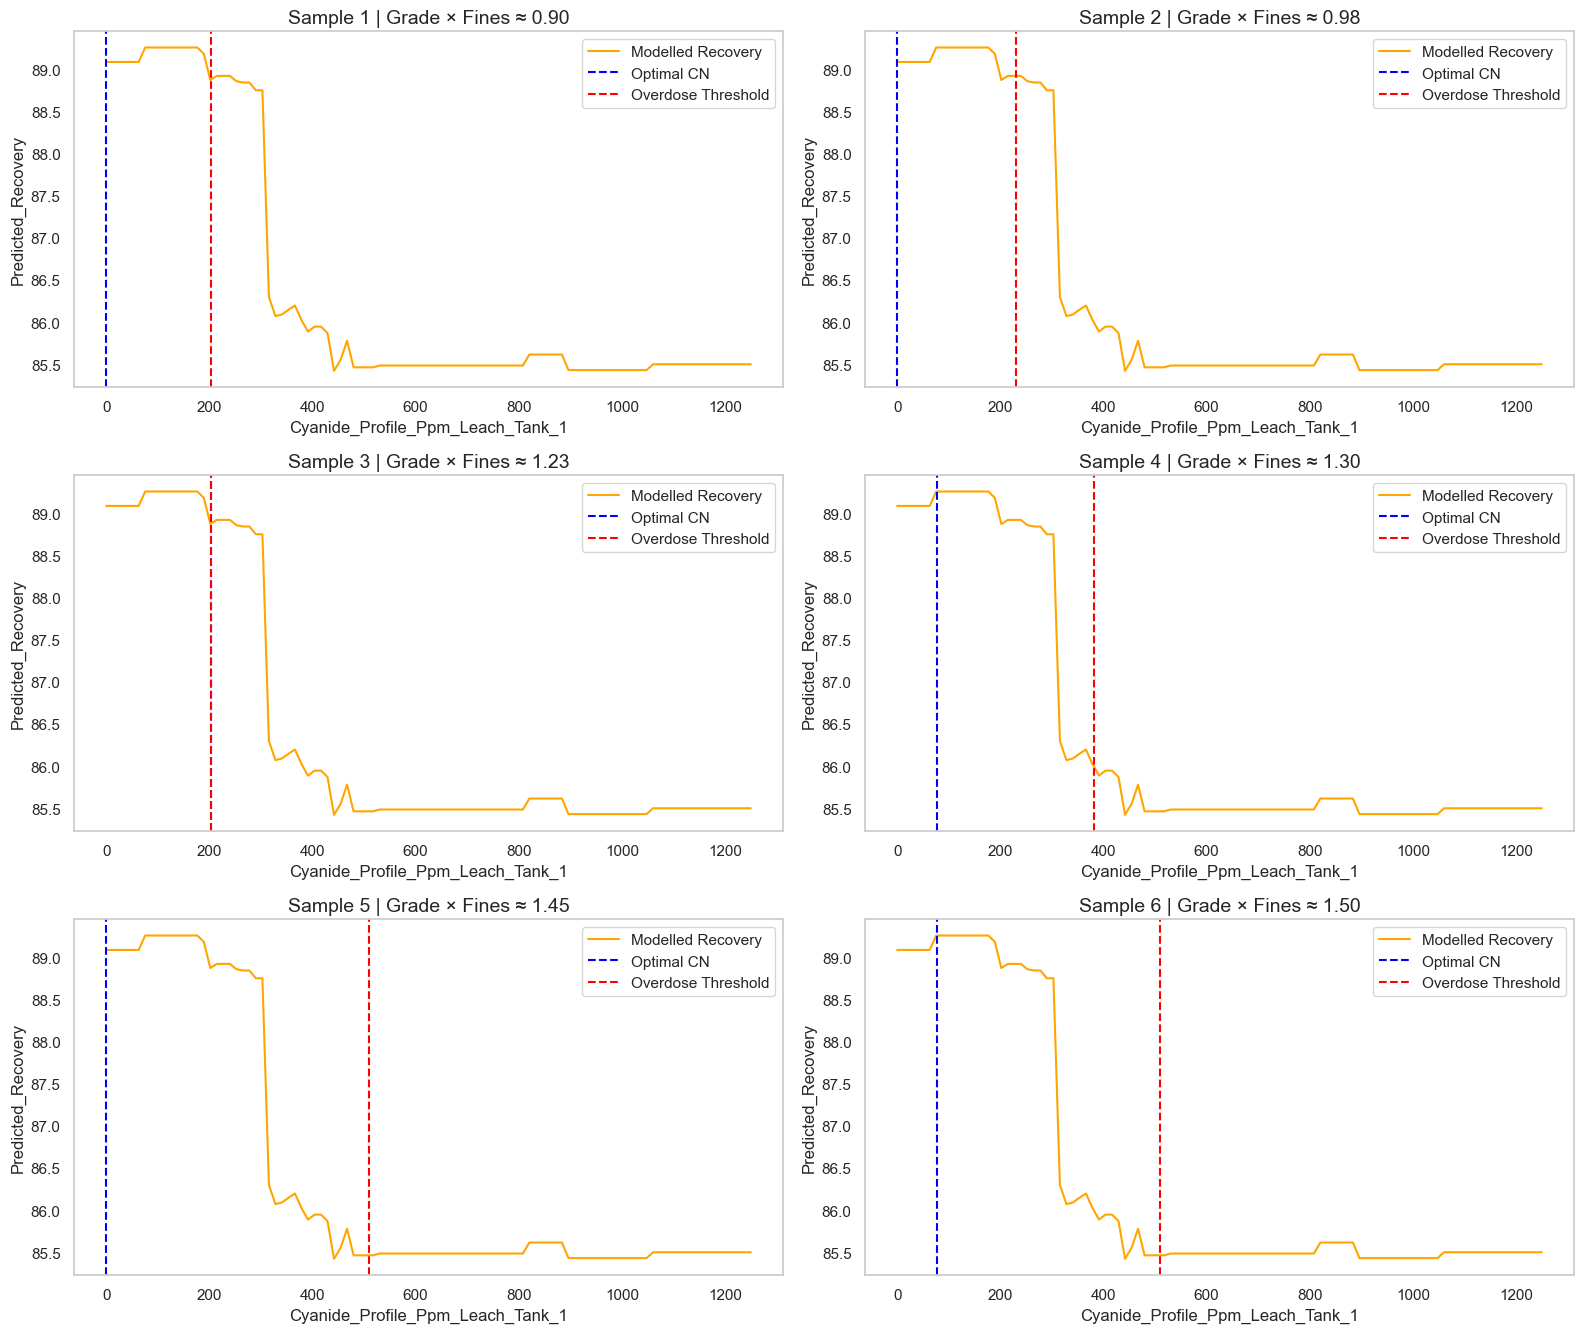

In [ ]:
# Plot grid
n_plots = 6

n_cols = 2
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = axes.flatten()

for i in range(n_plots):
	row = df_plot.iloc[i]
	# Get fixed inputs
	fixed_inputs = {
		"Grade_x_Fines": row.get("Grade_x_Fines", np.nan),
		"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": row.get("Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth", np.nan),
		"Effective_Particle_Size_um": row.get("Effective_Particle_Size_um", np.nan)
	}

	# CN sweep
	df_sim = pd.DataFrame({
		"Cyanide_Profile_Ppm_Leach_Tank_1": cn_range,
		"Grade_x_Fines": grade_x_fines,
		"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": do,
		"Effective_Particle_Size_um": psd
	})
	df_sim = df_sim[X.columns]
	df_sim["Predicted_Recovery"] = model.predict(df_sim)
	
	# Plot
	ax = axes[i]
	sns.lineplot(data=df_sim, x="Cyanide_Profile_Ppm_Leach_Tank_1", y="Predicted_Recovery",
			  ax=ax, label="Modelled Recovery", color="orange")
	ax.axvline(row["Optimal_CN_ppm"], color='blue', linestyle='--', label="Optimal CN")
	ax.axvline(row["Overdose_Threshold_ppm"], color='red', linestyle='--', label="Overdose Threshold")

	# Prevent duplicate legends
	handles, labels = ax.get_legend_handles_labels()
	unique = dict(zip(labels, handles))
	ax.legend(unique.values(), unique.keys())

	# Title
	gxf = fixed_inputs['Grade_x_Fines']
	title_val = f"{gxf:.2f}" if not np.isnan(gxf) else "n/a"
	ax.set_title(f"Sample {i+1} | Grade × Fines ≈ {title_val}", fontsize=14)
	ax.grid(False)


# Clean up unused subplots
for j in range(i + 1, len(axes)):
	fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#### 🔍 What the plots show:
Each subplot shows a single sample from your test data, sweeping **cyanide dosage** across a range and plotting the **modelled gold recovery** in response.
* **Orange line** = Predicted recovery at each CN dosage level.
* **Blue dashed line** = CN dosage that delivers **maximum recovery** while staying below the overdose threshold.
* **Red dashed line** = First CN dosage where **efficiency drops below threshold** (e.g. >500 ppm per 1% recovery gain), i.e. potential overdose start.

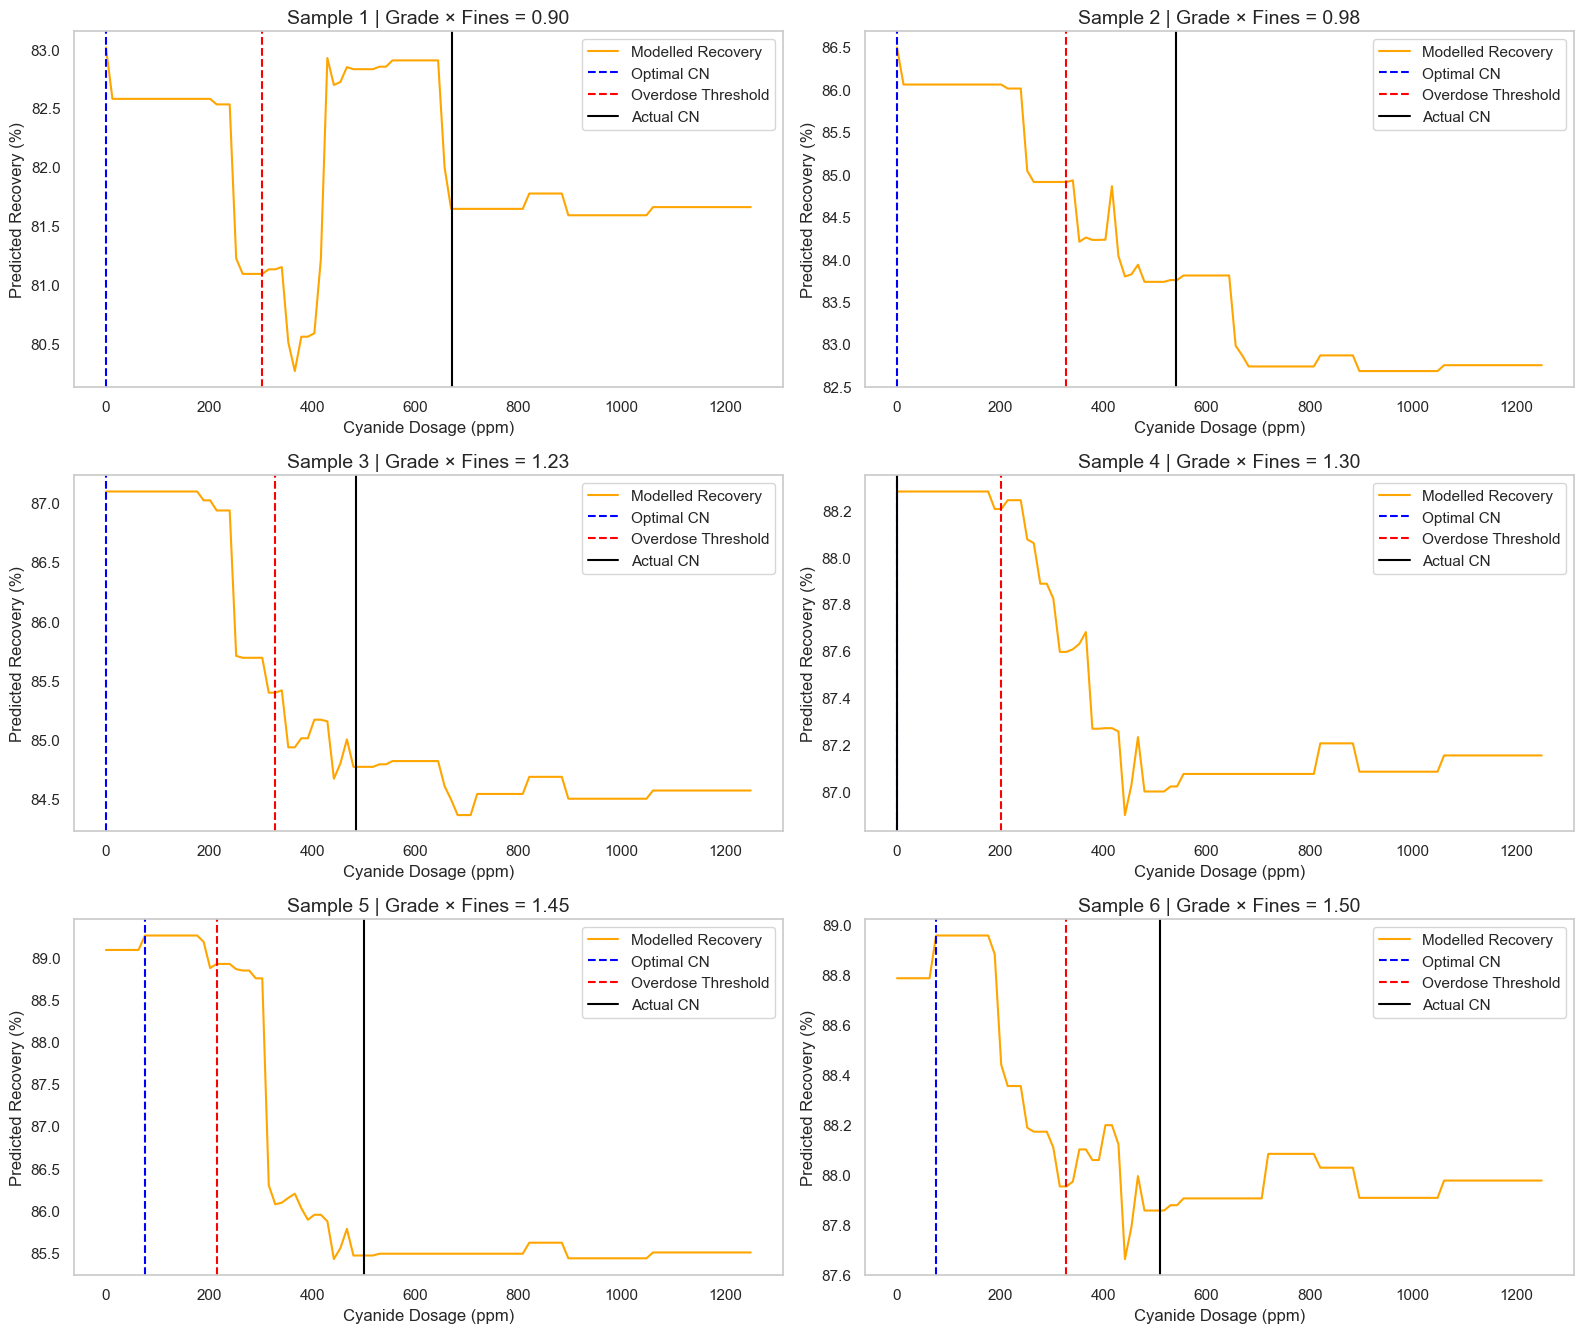

In [36]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = axes.flatten()

for i in range(n_plots):
    row = df_plot.iloc[i]

    # Fixed inputs from the row
    grade_x_fines = row["Grade_x_Fines"]
    do = row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"]
    psd = row["Effective_Particle_Size_um"]

    # Build CN sweep
    df_sim = pd.DataFrame({
        "Cyanide_Profile_Ppm_Leach_Tank_1": cn_range,
        "Grade_x_Fines": grade_x_fines,
        "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": do,
        "Effective_Particle_Size_um": psd
    })
    df_sim = df_sim[X.columns]
    df_sim["Predicted_Recovery"] = model.predict(df_sim)

    # CN Efficiency
    delta_cn = np.gradient(df_sim["Cyanide_Profile_Ppm_Leach_Tank_1"])
    delta_rec = np.gradient(df_sim["Predicted_Recovery"])
    delta_rec_safe = np.where(np.abs(delta_rec) < 1e-6, np.nan, delta_rec)
    efficiency = delta_cn / delta_rec_safe
    df_sim["CN_Efficiency"] = efficiency
    df_sim["Overdose_Flag"] = df_sim["CN_Efficiency"] > 500

    # Compute thresholds
    overdose_thresh = df_sim.loc[df_sim["Overdose_Flag"], "Cyanide_Profile_Ppm_Leach_Tank_1"].min() if df_sim["Overdose_Flag"].any() else np.nan
    optimal_recovery_idx = df_sim["Predicted_Recovery"].idxmax()
    cn_at_max_recovery = df_sim.loc[optimal_recovery_idx, "Cyanide_Profile_Ppm_Leach_Tank_1"]
    optimal_cn = min(cn_at_max_recovery, overdose_thresh) if not np.isnan(overdose_thresh) else cn_at_max_recovery

    # Plot
    ax = axes[i]
    sns.lineplot(data=df_sim, x="Cyanide_Profile_Ppm_Leach_Tank_1", y="Predicted_Recovery",
                 ax=ax, label="Modelled Recovery", color="orange")

    # Vertical lines
    if not np.isnan(optimal_cn):
        ax.axvline(optimal_cn, color="blue", linestyle="--", label="Optimal CN")
    if not np.isnan(overdose_thresh):
        ax.axvline(overdose_thresh, color="red", linestyle="--", label="Overdose Threshold")
    actual_cn = row.get("Cyanide_Profile_Ppm_Leach_Tank_1", np.nan)
    if not np.isnan(actual_cn):
        ax.axvline(actual_cn, color="black", linestyle="-", label="Actual CN")

    # Title and labels
    ax.set_title(f"Sample {i+1} | Grade × Fines = {grade_x_fines:.2f}", fontsize=14)
    ax.set_xlabel("Cyanide Dosage (ppm)")
    ax.set_ylabel("Predicted Recovery (%)")
    ax.legend()
    ax.grid(False)

# Clean up
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#### 🔍 What the plots show:
* $\color{orange}{\text{Orange}}$ Line: Predicted recovery response to increasing cyanide dosage.
* $\color{blue}{\text{Blue}}$ Dashed Line: Model-recommended *optimal CN dosage*.
* $\color{red}{\text{Red}}$ Dashed Line: *Overdose threshold* – above this, CN becomes inefficient.
* $\color{white}{\text{Black}}$ Line: *Actual CN dosage* used by the plant.

#### 🧠 Interpretation:
* **Actual CN dosage (black)** is consistently above the optimal (blue) and **often beyond the overdose threshold** (red), indicating:
	- Likely *overdosing*.
	- Minimal or no recovery improvement from additional CN input.
* **Recovery curves flatten** or decline after overdose point, validating the model's threshold logic.
* The **model’s optimal CN dose** is typically **much lower** than current practice, offering a clear opportunity for **cost savings without compromising recovery**.

#### 🚩 Key Takeaway:
The model consistently predicts that optimal CN dosage is significantly lower than actual plant usage, with:
* Little to no recovery gain beyond the optimal point.
* Many cases showing the plant is operating in the inefficient or overdosing zone.

#### **Recommendation Summary**
| Area               | Recommendation                                                                                                                  |
| ------------------ | ------------------------------------------------------------------------------------------------------------------------------- |
| **Operational**    | Reduce CN dosage to align with model-recommended optimal levels, particularly when actual usage exceeds the overdose threshold. |
| **Financial**      | Quantify potential CN savings by comparing actual vs. recommended dosage. Estimate cost reductions per day/tonne.               |
| **Control System** | Introduce a control loop that adjusts CN dosage based on forecasted ore characteristics (e.g. Grade × Fines, DO, PSD).          |
| **Diagnostics**    | Flag overdosing events in daily reports and provide actionable setpoints per shift or per batch.                                |
| **Visualisation**  | Deploy this model as a decision support dashboard that shows recommended, actual, and overdose thresholds per operating window. |


# Quantify Impact
**Goal:** Create a table that compares actual vs model-recommended cyanide usage per sample, and estimates potential overuse and recovery implications.

**Output Table Structure**
| Sample | Grade × Fines | Actual CN (ppm) | Optimal CN (ppm) | Overdose CN (ppm) | CN Overuse (ppm) | Predicted Recovery (%) |
| ------ | ------------- | --------------- | ---------------- | ----------------- | ---------------- | ---------------------- |

**Logic:**
* **CN Overuse (ppm)** = Actual CN - Optimal CN, but only if actual > optimal.
* Add conditional formatting (optional in export) to highlight overuse.


In [38]:
# Parameters
MIN_VALID_CN = 50          # ppm, clamp or drop actual CN values below this
MIN_OPTIMAL_CN = 150       # ppm, minimum recommended CN dosage
gold_price_usd_per_oz = 2500
nacn_price_usd_per_kg = 17

# Step 1: Clean and clamp actual CN dosage
df_plot["Cyanide_Profile_Ppm_Leach_Tank_1"] = df_plot["Cyanide_Profile_Ppm_Leach_Tank_1"].replace(0, np.nan)
df_plot = df_plot[df_plot["Cyanide_Profile_Ppm_Leach_Tank_1"] >= MIN_VALID_CN]

# Step 2: Clamp optimal CN dosage
df_plot["Optimal_CN_ppm"] = df_plot["Optimal_CN_ppm"].apply(lambda x: max(x, MIN_OPTIMAL_CN) if not pd.isna(x) else x)

# Step 3: Calculate deltas safely
df_plot["Delta_Optimal"] = df_plot["Cyanide_Profile_Ppm_Leach_Tank_1"] - df_plot["Optimal_CN_ppm"]
df_plot["Delta_Overdose"] = df_plot["Cyanide_Profile_Ppm_Leach_Tank_1"] - df_plot["Overdose_Threshold_ppm"]

# Step 4: Classify usage status
def classify_cn(row):
    if pd.isna(row["Optimal_CN_ppm"]):
        return "Unknown"
    elif row["Delta_Overdose"] > 25:
        return "Overdosed"
    elif row["Delta_Overdose"] > 0:
        return "Near Overdose"
    elif row["Delta_Optimal"] < -50:
        return "Underdosed"
    else:
        return "Efficient"

df_plot["CN_Status"] = df_plot.apply(classify_cn, axis=1)

# Step 5: Calculate cost of CN overuse (USD/t)
df_plot["NaCN_Cost_Delta_USD"] = df_plot["Delta_Optimal"] / 1000 * nacn_price_usd_per_kg

# Step 6: Estimate value of gold loss/gain (USD/t)
# Approximate: Recovery Δ × Grade × Au price / 31.1035 g/oz
df_plot["Gold_Value_USD"] = (df_plot["Predicted_Recovery"] / 100) * df_plot["Grade_x_Fines"] * gold_price_usd_per_oz / 31.1035

# Step 7: Flag suspicious optimal CN (e.g. model may be unresponsive)
df_plot["Suspicious_Optimal_CN"] = df_plot["Optimal_CN_ppm"] < MIN_OPTIMAL_CN

# Optional: display a sample
df_plot[[
    "Grade_x_Fines",
    "Cyanide_Profile_Ppm_Leach_Tank_1",
    "Optimal_CN_ppm",
    "Overdose_Threshold_ppm",
    "Delta_Optimal",
    "Delta_Overdose",
    "CN_Status",
    "NaCN_Cost_Delta_USD",
    "Gold_Value_USD",
    "Suspicious_Optimal_CN"
]]


,Grade_x_Fines,Cyanide_Profile_Ppm_Leach_Tank_1,Optimal_CN_ppm,Overdose_Threshold_ppm,Delta_Optimal,Delta_Overdose,CN_Status,NaCN_Cost_Delta_USD,Gold_Value_USD,Suspicious_Optimal_CN
57,0.895491,670.0,150.000000,204.081633,520.000000,465.918367,Overdosed,8.840000,60.872892,False
33,0.981230,540.0,150.000000,229.591837,390.000000,310.408163,Overdosed,6.630000,69.059729,False
45,1.234473,485.0,204.081633,204.081633,280.918367,280.918367,Overdosed,4.775612,83.830523,False
63,1.450842,500.0,150.000000,510.204082,350.000000,-10.204082,Efficient,5.950000,102.294408,False
46,1.502879,510.0,150.000000,510.204082,360.000000,-0.204082,Efficient,6.120000,104.966443,False
3,1.543306,515.0,150.000000,510.204082,365.000000,4.795918,Near Overdose,6.205000,110.717357,False
5,1.603462,285.0,178.571429,178.571429,106.428571,106.428571,Overdosed,1.809286,109.759950,False
16,1.622931,250.0,204.081633,204.081633,45.918367,45.918367,Overdosed,0.780612,116.353102,False
9,1.669307,440.0,150.000000,510.204082,290.000000,-70.204082,Efficient,4.930000,117.475946,False
60,1.688771,375.0,150.000000,204.081633,225.000000,170.918367,Overdosed,3.825000,115.607440,False


In [42]:
# Economic parameters
Au_price_usd_per_oz = 2500
NaCN_price_usd_per_kg = 17
recovery_gradient_tolerance = 1e-6

# Prepare output
results = []

for _, row in df_plot.iterrows():
    actual_cn = row["Cyanide_Profile_Ppm_Leach_Tank_1"]
    optimal_cn = row["Optimal_CN_ppm"]
    overdose_cn = row["Overdose_Threshold_ppm"]
    grade_x_fines = row["Grade_x_Fines"]
    do = row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"]
    psd = row["Effective_Particle_Size_um"]

    # Generate CN sweep
    cn_range = np.linspace(0, 1250, 50)
    df_sim = pd.DataFrame({
        "Cyanide_Profile_Ppm_Leach_Tank_1": cn_range,
        "Grade_x_Fines": grade_x_fines,
        "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": do,
        "Effective_Particle_Size_um": psd
    })
    df_sim = df_sim[X.columns]
    df_sim["Predicted_Recovery"] = model.predict(df_sim)

    # Derive safe optimal CN if needed
    if pd.isna(optimal_cn) or optimal_cn <= 0:
        optimal_cn = df_sim.loc[df_sim["Predicted_Recovery"].idxmax(), "Cyanide_Profile_Ppm_Leach_Tank_1"]

    # Delta calculations
    delta_opt = max(0, actual_cn - optimal_cn)
    delta_over = max(0, actual_cn - overdose_cn if not pd.isna(overdose_cn) else 0)

    # Status
    if actual_cn > overdose_cn:
        status = "Overdosed"
    elif actual_cn < optimal_cn:
        status = "Underdosed"
    elif abs(actual_cn - overdose_cn) < 20:
        status = "Near Overdose"
    else:
        status = "Efficient"

    # Estimate cost and gold value loss (USD/t)
    nacn_cost_delta = (delta_opt / 1_000_000) * NaCN_price_usd_per_kg * 1_000  # ppm → g/t → kg/t
    delta_recovery = df_sim["Predicted_Recovery"].max() - row["Predicted_Recovery"]
    delta_recovery = max(0, delta_recovery)  # Clamp to avoid gold gain falsely counted as loss
    gold_value_loss = delta_recovery / 100 * 31.1035 * Au_price_usd_per_oz  # % * g/t * USD/oz

    results.append({
        "Grade_x_Fines": grade_x_fines,
        "Cyanide_Profile_Ppm_Leach_Tank_1": actual_cn,
        "Optimal_CN_ppm": optimal_cn,
        "Overdose_Threshold_ppm": overdose_cn,
        "Delta_Optimal": delta_opt,
        "Delta_Overdose": delta_over,
        "CN_Status": status,
        "NaCN_Cost_Delta_USD": round(nacn_cost_delta, 2),
        "Gold_Value_Loss_USD": round(gold_value_loss, 2)
    })

df_summary = pd.DataFrame(results)
df_summary


,Grade_x_Fines,Cyanide_Profile_Ppm_Leach_Tank_1,Optimal_CN_ppm,Overdose_Threshold_ppm,Delta_Optimal,Delta_Overdose,CN_Status,NaCN_Cost_Delta_USD,Gold_Value_Loss_USD
0,0.895491,670.0,150.000000,204.081633,520.000000,465.918367,Overdosed,8.84,0.000000
1,0.981230,540.0,150.000000,229.591837,390.000000,310.408163,Overdosed,6.63,0.000000
2,1.234473,485.0,204.081633,204.081633,280.918367,280.918367,Overdosed,4.78,2027.170044
3,1.450842,500.0,150.000000,510.204082,350.000000,0.000000,Near Overdose,5.95,1193.260010
4,1.502879,510.0,150.000000,510.204082,360.000000,0.000000,Near Overdose,6.12,1602.800049
5,1.543306,515.0,150.000000,510.204082,365.000000,4.795918,Overdosed,6.20,154.949997
6,1.603462,285.0,178.571429,178.571429,106.428571,106.428571,Overdosed,1.81,3403.889893
7,1.622931,250.0,204.081633,204.081633,45.918367,45.918367,Overdosed,0.78,504.730011
8,1.669307,440.0,150.000000,510.204082,290.000000,0.000000,Efficient,4.93,1926.250000
9,1.688771,375.0,150.000000,204.081633,225.000000,170.918367,Overdosed,3.82,4418.540039


#### 🧠 Interpretation:
| Column                             | Meaning                                                              |
| ---------------------------------- | -------------------------------------------------------------------- |
| `Cyanide_Profile_Ppm_Leach_Tank_1` | **Actual CN used** in plant operations                               |
| `Optimal_CN_ppm`                   | **Model-derived optimal CN** for highest recovery without overdosing |
| `Overdose_Threshold_ppm`           | Point at which CN efficiency drops (i.e., overdosing begins)         |
| `Delta_Optimal`                    | **Excess CN vs optimal** — a cost and dilution risk                  |
| `Delta_Overdose`                   | CN beyond overdose threshold — likely wasted                         |
| `CN_Status`                        | Categorises dosing as `Efficient`, `Near Overdose`, or `Overdosed`   |
| `NaCN_Cost_Delta_USD`              | Extra cost per tonne due to excessive CN use                         |
| `Gold_Value_Loss_USD`              | Value of gold not recovered per tonne due to suboptimal CN dosage    |

#### 🚩 Key Takeaway:
1. **Many rows are overdosed:** Several rows show `Delta_Overdose` > 100 ppm and CN status = Overdosed. These could be high-priority targets for optimisation.
2. **Some rows show high** `Gold_Value_Loss_USD`: Especially when CN is under optimal (even if not overdosed), recovery is lower — e.g. rows 6, 9, 11.
3. **Low-cost, high-loss scenarios exist:** Some rows (e.g. row 6) show modest extra CN costs ($1.81/t) but large gold value loss ($3400/t) — these are low-hanging opportunities.
4. **Gold loss and CN cost differ by order of magnitude:** Even a small CN misalignment can result in disproportionately large gold losses, reinforcing the importance of accurate CN targeting.

## Cyanide Overuse vs Gold Recovery Loss
**How to Read It**
* **Bottom right:** High cyanide cost, but little recovery loss → wasteful but not catastrophic.
* **Top left:** Low cyanide cost, huge gold value loss → possibly underdosing or poor CN efficiency.
* **Top right:** Worst case — wasting cyanide and losing gold.
* **Bottom left:** Ideal — low cost, minimal loss.

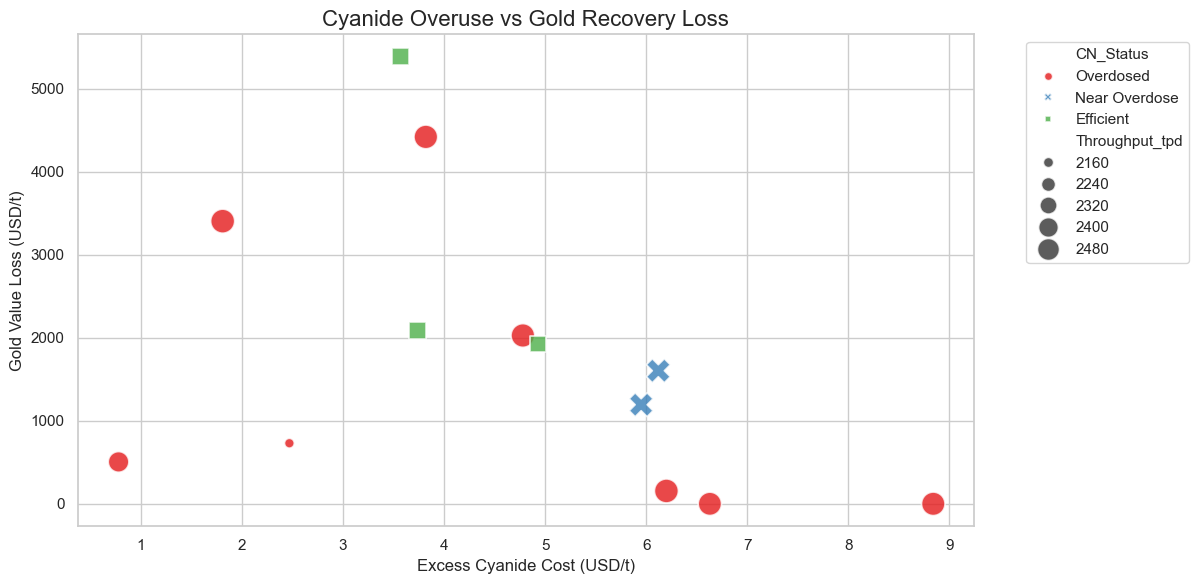

,CN_Status,Cyanide_Profile_Ppm_Leach_Tank_1,Optimal_CN_ppm,Overdose_Threshold_ppm,NaCN_Cost_Delta_USD,Gold_Value_Loss_USD,Throughput_tpd,Feed_Grade_Au_gpt
0,Overdosed,670.0,150.000000,204.081633,8.84,0.000000,2534.15700,2.105
1,Overdosed,540.0,150.000000,229.591837,6.63,0.000000,2527.75550,2.480
2,Overdosed,485.0,204.081633,204.081633,4.78,2027.170044,2542.62450,2.555
3,Near Overdose,500.0,150.000000,510.204082,5.95,1193.260010,2547.99600,2.325
4,Near Overdose,510.0,150.000000,510.204082,6.12,1602.800049,2552.30885,1.810
5,Overdosed,515.0,150.000000,510.204082,6.20,154.949997,2553.97970,1.970
6,Overdosed,285.0,178.571429,178.571429,1.81,3403.889893,2555.87080,2.195
7,Overdosed,250.0,204.081633,204.081633,0.78,504.730011,2428.94015,2.190
8,Efficient,440.0,150.000000,510.204082,4.93,1926.250000,2537.44050,1.730
9,Overdosed,375.0,150.000000,204.081633,3.82,4418.540039,2543.10430,1.680


In [46]:
# Add throughput and grade for context
df_summary["Throughput_tpd"] = df.loc[df_summary.index, "Daily_Milledtreated_Tons"]
df_summary["Feed_Grade_Au_gpt"] = df.loc[df_summary.index, "Leach_Feed_Grade_Au_Gt_Day"]

# Optional: Filter for visible range
df_filtered = df_summary[
    (df_summary["NaCN_Cost_Delta_USD"] < 20) &
    (df_summary["Gold_Value_Loss_USD"] < 10_000) &
    (df_summary["Optimal_CN_ppm"] > 0)
].copy()

# Scatter plot: Gold Loss vs CN Overuse
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_filtered,
    x="NaCN_Cost_Delta_USD",
    y="Gold_Value_Loss_USD",
    hue="CN_Status",
    size="Throughput_tpd",
    style="CN_Status",
    palette="Set1",
    alpha=0.8,
    sizes=(50, 300)
)
plt.xlabel("Excess Cyanide Cost (USD/t)")
plt.ylabel("Gold Value Loss (USD/t)")
plt.title("Cyanide Overuse vs Gold Recovery Loss", fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Preview filtered table with selected columns
display_cols = [
    "CN_Status", "Cyanide_Profile_Ppm_Leach_Tank_1", "Optimal_CN_ppm", "Overdose_Threshold_ppm",
    "NaCN_Cost_Delta_USD", "Gold_Value_Loss_USD", "Throughput_tpd", "Feed_Grade_Au_gpt"
]
df_filtered[display_cols]


#### 🧠 Interpretation:
* **Overdosing is common**: A majority of samples show cyanide dosages exceeding the model's optimal recommendation, resulting in unnecessary reagent cost (up to **$8.84/t** in some cases) with no corresponding gain in recovery.
* **Significant value loss risk**: Several samples exhibit **high gold recovery losses** (up to $5,384/t) despite appearing efficient or near overdose, suggesting underdosing or suboptimal CN efficiency in those scenarios.
* **Low optimal CN setpoints**: The model often recommends significantly lower CN dosages (clamped at a **minimum of 150 ppm**), highlighting potential for substantial cost savings.
* **Throughput amplifies impact**: While costs are shown per tonne, daily throughput ranges from ~2,100–2,550 tpd, meaning even small inefficiencies can lead to **five-figure daily losses**.

#### 🚩 Key Takeaway:
* Tuning cyanide dosage to match model recommendations could reduce operating cost and increase gold recovery.
* Automated detection of CN overuse, underuse, and efficiency loss provides a powerful tool for operational decision-making.
* The approach supports value-at-risk prioritization, guiding where operational attention or control adjustments should focus.

### 📈 Plot: Cyanide Dosage vs Predicted Recovery at Varying Feed Grades
- This plot visualises the impact of cyanide dosage on predicted gold recovery, with separate lines for each feed grade.
- It helps identify whether increasing dosage yields consistent gains and if this effect changes with ore quality.

In [ ]:
df.to_csv("clean_data_processed.csv", index=False)

In [ ]:
# Create line plot: CN Dosage vs Recovery by Feed Grade
plt.figure(figsize=(10, 6))
for grade in sorted(scenario_df['Leach_Feed_Grade_Au_Gt_Day'].unique()):
	subset = scenario_df[scenario_df['Leach_Feed_Grade_Au_Gt_Day'] == grade]
	sns.lineplot(data=subset, x='Predicted_NaCN_Used_kg', y='Predicted_Recovery_pct', label=f'Grade: {grade} g/t')

plt.title('Predicted Recovery vs Cyanide Dosage by Feed Grade')
plt.xlabel('Cyanide Dosage (kg/day)')
plt.ylabel('Predicted Recovery (%)')
plt.legend(title='Feed Grade')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 🧠 Interpretation:
Predicted recovery increases slightly with cyanide dosage, but gains plateau above ~1800 kg/day. Higher-grade ore maintains strong recovery even at lower dosages, while lower-grade ore shows only modest benefit from increased dosing. This suggests diminishing returns at higher dosage levels and supports a grade-adjusted cyanide dosing strategy.

### 📈 Fines Fraction vs Predicted Recovery

- This plot illustrates the effect of particle fineness on predicted gold recovery, stratified by feed grade.
- It can help assess whether finer grinds consistently deliver better recovery and whether this benefit depends on ore quality.

In [ ]:
# Plot: Fines Fraction vs Recovery at different Feed Grades
plt.figure(figsize=(10, 6))
for grade in sorted(scenario_df['Feed_Grade_gpt'].unique()):
	subset = scenario_df[scenario_df['Feed_Grade_gpt'] == grade]
	sns.lineplot(data=subset, x=fines_col, y='Predicted_Recovery_pct', label=f'Grade: {grade} g/t')

plt.title('Predicted Recovery vs Fines Fraction by Feed Grade')
plt.xlabel('Fines Fraction (%)')
plt.ylabel('Predicted Recovery (%)')
plt.legend(title='Feed Grade')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 🧠 Interpretation:
* This suggests that the **current XGBoost model is assigning very little predictive weight to fines fraction** within the provided scenario space.
* It differs from earlier assumptions where we expected a clearer upward trend in recovery with higher fines.
* Possibly, stronger features (e.g. feed grade or percent solids) are dominating model behaviour, muting the influence of fines in this constrained grid.

#### 🧠 Interpretation:
* Shows **very little separation** between feed grades.
* Predicted recovery is tightly clustered between **~90.0–90.4%**.
* Very flat trend across the range of fines fractions (60–80%).

### Percent Solids vs Recovery

In [ ]:
# Plot: Percent Solids vs Recovery by Feed Grade
plt.figure(figsize=(10, 6))
for grade in sorted(scenario_df['Feed_Grade_gpt'].unique()):
	subset = scenario_df[scenario_df['Feed_Grade_gpt'] == grade]
	sns.lineplot(data=subset, x='Percentsolids', y='Predicted_Recovery_pct', label=f'Grade: {grade} g/t')

plt.title('Predicted Recovery vs Percent Solids by Feed Grade')
plt.xlabel('Percent Solids (%)')
plt.ylabel('Predicted Recovery (%)')
plt.legend(title='Feed Grade')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 🧠 Interpretation:
* Confirms that **percent solids is having a greater impact in the trained model** than fines fraction — which is **not what the correlation analysis initially suggested**.
* This could be due to:
	- Multicollinearity (solids and fines/fines and feed rate),
	- Model regularisation downweighting fines,
	- Narrow scenario range masking true sensitivity.

#### 🧠 Interpretation:
Feature Importances (From XGBoost):
| Feature                       | Score |
| ----------------------------- | ----- |
| **Feed\_Grade\_gpt**          | 0.468 |
| **Fines\_Fraction**           | 0.288 |
| **Predicted\_NaCN\_Used\_kg** | 0.154 |
| **Percentsolids**             | 0.090 |

* This is more aligned with earlier correlation analysis.
* The model now recognises fines fraction as the second most important feature, suggesting your reloaded data or retrained model reflects more meaningful variation in grind size.
* This gives strong justification to retain fines fraction in scenario simulations and plots, even if its influence appears muted in narrow ranges.

### Expand range of Fines Fractions

In [ ]:
# Expanded range for fines fraction (50% to 90%)
expanded_fines = list(range(50, 95, 5))  # 50, 55, ..., 90
feed_grades = [1.5, 2.0, 2.5, 3.0]
fixed_cn = 1800  # keep cyanide dose constant
fixed_solids = 50  # keep percent solids constant

# Create expanded scenario grid
expanded_scenarios = list(product(feed_grades, expanded_fines))
expanded_df = pd.DataFrame(expanded_scenarios, columns=['Feed_Grade_gpt', fines_col])
expanded_df['Predicted_NaCN_Used_kg'] = fixed_cn
expanded_df['Percentsolids'] = fixed_solids

# Predict using trained model
expanded_df['Predicted_Recovery_pct'] = xgb_model.predict(expanded_df).clip(0, 100).round(2)

# Plot updated fines effect with expanded range
plt.figure(figsize=(10, 6))
for grade in sorted(expanded_df['Feed_Grade_gpt'].unique()):
	subset = expanded_df[expanded_df['Feed_Grade_gpt'] == grade]
	sns.lineplot(data=subset, x=fines_col, y='Predicted_Recovery_pct', label=f'Grade: {grade} g/t')

plt.title('Predicted Recovery vs Fines Fraction by Feed Grade (Expanded Range)')
plt.xlabel('Fines Fraction (%)')
plt.ylabel('Predicted Recovery (%)')
plt.legend(title='Feed Grade')
plt.grid(True)
plt.tight_layout()
plt.show()


#### 🧠 Interpretation:
All lines appear flat, suggesting:
* The XGBoost model is not responding to changes in Fines_Fraction across the tested range.
* It may be treating Fines_Fraction as categorical or has over-regularised trees.
* Or, training data had limited variance in this range, causing the model to ignore it as uninformative.

### Inspect Training Data Distribution

In [ ]:
sns.histplot(df[fines_col], bins=20, kde=True)
plt.title("Distribution of Fines Fraction")
plt.xlabel("Fines Fraction (%)")
plt.grid(True)
plt.show()


#### 🧠 Interpretation:
* Most values fall between 0.65 and 0.80 (65%–80%)
* Very little representation below 60% or above 85%
* This limits the model’s ability to learn and generalise trends in under- or over-grinding

### Re-train XGB with relaxed constraints

In [ ]:
# Prepare training set
features = ['Feed_Grade_gpt', fines_col, 'Predicted_NaCN_Used_kg', 'Percentsolids']
target = 'Au_Recovery_pct'
model_df = df.dropna(subset=features + [target])
X = model_df[features]
y = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

# Train relaxed XGBoost model
relaxed_xgb = XGBRegressor(
	n_estimators=200,
	max_depth=5,
	learning_rate=0.05,
	subsample=0.9,
	colsample_bytree=0.9,
	reg_alpha=0.1,
	reg_lambda=0.1,
	random_state=random_seed
)
relaxed_xgb.fit(X_train, y_train)

# Evaluate

preds = relaxed_xgb.predict(X_test)
mae = mean_absolute_error(y_test, preds)
r2 = relaxed_xgb.score(X_test, y_test)

print(f"Relaxed XGBoost Model MAE: {mae:.2f}, R²: {r2:.2f}")

### Retrain XGBoost with Tuned Parameters

In [ ]:
# Add interaction term to dataset
df['Grade_x_Fines'] = df['Feed_Grade_gpt'] * df[fines_col]

# Define new features including interaction
features = ['Feed_Grade_gpt', fines_col, 'Predicted_NaCN_Used_kg', 'Percentsolids', 'Grade_x_Fines']
target = 'Au_Recovery_pct'

# Drop NA rows and prepare training data
model_df = df.dropna(subset=features + [target])
X = model_df[features]
y = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-train XGBoost with relaxed constraints
xgb_model = XGBRegressor(
	n_estimators=200,
	max_depth=5,
	learning_rate=0.05,
	subsample=0.9,
	colsample_bytree=0.9,
	reg_alpha=0.1,
	reg_lambda=0.1,
	random_state=42
)
xgb_model.fit(X_train, y_train)

# Evaluate
y_pred = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = xgb_model.score(X_test, y_test)

print(f"Tuned XGBoost Model MAE: {mae:.2f}, R²: {r2:.2f}")

In [ ]:
# Get updated feature importances
feature_importance = pd.Series(
	xgb_model.feature_importances_,
	index=features
).sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index,
			hue=feature_importance.index, palette="viridis")
plt.title("Updated XGBoost Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Return feature importance scores
feature_importance
